# Customer Churn Prediction Based on Historical Customer Behavior

## Business Problem Understanding

### Context

Olist merupakan marketplace e-commerce di Brazil yang menghubungkan customer dengan berbagai seller dan produk. Dataset Olist menyediakan informasi mengenai customer, histori transaksi, produk yang dibeli, kategori produk, serta informasi terkait order.

Dalam bisnis e-commerce, terdapat customer yang hanya melakukan pembelian satu kali dan tidak kembali melakukan transaksi, sementara customer lainnya melakukan repeat purchase.

Retention activity seperti voucher, discount, atau promotional campaign memiliki biaya. Oleh karena itu, perusahaan perlu mengetahui customer mana yang berisiko tidak kembali melakukan transaksi agar retention treatment dapat diberikan secara lebih tepat sasaran.

Pada project ini, historical customer behavior digunakan untuk memahami pola pembelian customer dan membangun model yang dapat membantu mengidentifikasi kemungkinan customer tidak kembali melakukan pembelian dalam 180 hari ke depan.

Dataset Olist tidak memiliki explicit churn label karena customer tidak melakukan subscription cancellation yang dapat secara langsung menandakan churn. Oleh karena itu, churn pada project ini didefinisikan menggunakan customer purchasing behavior pada future prediction window sebagai proxy untuk customer non-return.


### Target

Target yang digunakan dalam project ini adalah:

- **0 = Not Churn / Returned**  
  Customer melakukan minimal satu recorded order baru dalam 180 hari setelah prediction date.

- **1 = Churn / No New Order**  
  Customer tidak memiliki recorded order baru dalam 180 hari setelah prediction date.

Untuk setiap prediction date, historical customer behavior dibentuk menggunakan transaksi selama **180 hari sebelumnya (historical observation window)**. Actual customer outcome kemudian diamati selama **180 hari setelah prediction date (future prediction window)**.

Dengan demikian, istilah **Churn** pada project ini berarti customer yang tidak kembali melakukan recorded order dalam 180 hari, bukan permanent customer churn.


### Problem Statement

Customer yang belum melakukan pembelian kembali tidak dapat langsung dianggap churn hanya berdasarkan transaksi terakhirnya, karena customer mungkin masih melakukan repeat purchase di kemudian hari.

Di sisi lain, memberikan retention treatment kepada seluruh customer juga tidak efisien karena tidak semua customer membutuhkan intervensi.

Oleh karena itu, perusahaan membutuhkan pendekatan yang dapat membantu:

1. Mengidentifikasi dan memprioritaskan customer berdasarkan kemungkinan melakukan pembelian kembali dalam 180 hari ke depan.
2. Memahami historical customer behavior yang berkaitan dengan kemungkinan customer kembali melakukan transaksi.
3. Mengurangi retention cost yang tidak perlu akibat memberikan treatment kepada customer yang sebenarnya masih akan kembali.
4. Mengurangi risiko missed retention opportunity pada customer yang berpotensi tidak kembali tetapi tidak teridentifikasi.

### Stakeholder
Primary stakeholder pada project ini adalah CRM / Retention Marketing Team, yang bertanggung jawab dalam menentukan customer target untuk retention campaign seperti voucher, discount, atau promotional communication.  
Model membantu stakeholder memprioritaskan customer berdasarkan predicted return probability, sehingga retention activity dapat dilakukan secara lebih terarah dibandingkan memberikan treatment kepada seluruh customer.


### Goals

Project ini bertujuan untuk:

1. Memahami pola purchasing dan repeat purchase customer berdasarkan historical transaction data.
2. Membangun model klasifikasi untuk mengestimasi kemungkinan customer melakukan pembelian kembali dalam 180 hari ke depan dan mendukung customer prioritization.
3. Mengidentifikasi historical customer behavior yang berkaitan dengan kemungkinan customer kembali atau tidak kembali melakukan transaksi.
4. Mengevaluasi apakah informasi customer behavior tambahan memberikan predictive value dibandingkan basic purchasing behavior.
5. Memberikan dasar untuk memprioritaskan customer dalam retention activity.


### Analytic Approach

Analisis dilakukan melalui beberapa tahap:

1. **Data Understanding**  
   Memahami struktur dataset, kualitas data, pola transaksi, dan customer behavior sebelum membentuk modeling dataset.

2. **Data Preparation**  
   Menggabungkan dan menyiapkan dataset yang dibutuhkan pada order level agar historical customer behavior dapat dihitung secara konsisten tanpa menggandakan jumlah order.

3. **Repeat Purchase Analysis**  
   Menganalisis pola repeat order secara deskriptif untuk memahami seberapa umum customer kembali melakukan transaksi. Analisis ini digunakan sebagai konteks customer retention behavior dan bukan sebagai churn rate.

4. **Churn Labelling & Modeling Time Setup**  
   Menggunakan **180-day historical observation window** untuk membentuk customer features dan **180-day future prediction window** untuk menentukan actual customer outcome.

5. **Exploratory Data Analysis (EDA)**  
   Membandingkan historical behavior antara customer Churn dan Not Churn untuk memahami pola yang berkaitan dengan future customer return.

6. **Model Development & Validation**  
   Membangun dan membandingkan model menggunakan time-based training dan validation snapshots. Model dibandingkan dengan simple baseline untuk memastikan apakah model memberikan predictive value.

7. **Final Evaluation**  
   Final selected model dievaluasi pada test snapshot yang tidak digunakan selama model development untuk mengukur kemampuan model pada periode waktu berikutnya.


## Metric Evaluation

Model memiliki target:

- **0 = Not Churn / Returned**
- **1 = Churn / No New Order**

Target distribution sangat tidak seimbang. Sebagian besar customer tidak melakukan order baru selama future prediction window, sementara hanya sebagian kecil customer yang kembali melakukan transaksi.

Dalam kondisi ini, **Accuracy dapat memberikan gambaran performa yang misleading**, karena model dapat memperoleh Accuracy yang tinggi hanya dengan memprediksi majority class.

Selain mengevaluasi classification performance, business use case project ini juga mempertimbangkan kemampuan model untuk **memprioritaskan customer berdasarkan predicted return probability**.


### Primary Evaluation Metric

**Average Precision (AP) untuk Not Churn / Returned customers (class 0)** digunakan sebagai primary evaluation metric.

Average Precision dipilih karena:

1. **Not Churn / Returned merupakan minority class** yang jumlahnya sangat kecil dibandingkan Churn / No New Order.
2. Accuracy dapat terlihat tinggi meskipun model gagal mengidentifikasi minority class.
3. Average Precision mengevaluasi kualitas ranking model pada berbagai Precision–Recall trade-off.
4. Business use case membutuhkan customer prioritization, sehingga kemampuan model memberikan score yang lebih tinggi kepada actual returning customers menjadi relevan.

Model kemudian dibandingkan dengan **simple baseline** untuk melihat apakah historical customer behavior benar-benar memberikan predictive value.


### Supporting Metrics

Selain Average Precision, beberapa supporting metrics digunakan untuk membantu interpretasi model:

- **Precision**  
  Mengukur proporsi customer yang benar-benar Returned di antara customer yang diprediksi atau diprioritaskan sebagai Returned.

- **Recall**  
  Mengukur seberapa banyak actual Returned customers yang berhasil diidentifikasi oleh model.

- **F1-Score**  
  Digunakan sebagai supplementary metric untuk melihat keseimbangan Precision dan Recall pada classification threshold tertentu.

- **Confusion Matrix**  
  Digunakan untuk memahami jenis prediction error yang dihasilkan model.

F1-Score tidak digunakan sebagai primary metric karena F1 bergantung pada classification threshold tertentu, sedangkan primary use case juga mempertimbangkan kemampuan model dalam melakukan customer ranking.


### Confusion Matrix

| Actual / Predicted | Not Churn (0) | Churn (1) |
|---|---|---|
| **Not Churn (0)** | **True Negative (TN)** | **False Positive (FP)** |
| **Churn (1)** | **False Negative (FN)** | **True Positive (TP)** |

Penjelasan:

- **True Positive (TP):** Customer sebenarnya Churn dan diprediksi Churn.
- **True Negative (TN):** Customer sebenarnya Not Churn dan diprediksi Not Churn.
- **False Positive (FP):** Customer sebenarnya Not Churn tetapi diprediksi Churn.
- **False Negative (FN):** Customer sebenarnya Churn tetapi diprediksi Not Churn.


### Business Impact of Prediction Error

#### False Positive (FP)

Customer sebenarnya **Not Churn**, tetapi diprediksi sebagai **Churn**.

Jika retention treatment diberikan kepada predicted Churn customers, perusahaan dapat memberikan voucher, discount, atau promotional treatment kepada customer yang sebenarnya masih akan kembali melakukan transaksi tanpa intervention.

Hal ini dapat menyebabkan **unnecessary retention cost**.


#### False Negative (FN)

Customer sebenarnya **Churn**, tetapi diprediksi sebagai **Not Churn**.

Customer yang sebenarnya tidak kembali melakukan transaksi tidak teridentifikasi sebagai customer yang membutuhkan retention treatment.

Hal ini dapat menyebabkan **missed retention opportunity** dan potential lost customer value.

Meskipun target binary dikodekan sebagai Churn = 1 dan Returned = 0, evaluasi utama model berfokus pada Returned class karena business use case adalah customer prioritization berdasarkan predicted return probability. Oleh karena itu, analisis FP/FN digunakan sebagai supporting interpretation, sedangkan Average Precision dan ranking metrics digunakan sebagai evaluasi utama.


### Customer Ranking Evaluation

Selain hard classification, model juga dievaluasi berdasarkan kemampuannya dalam melakukan **customer prioritization**.

Customer dapat diurutkan berdasarkan predicted return probability atau **return score**. Performance kemudian dapat dievaluasi pada beberapa ukuran customer shortlist menggunakan:

- **Precision:** proporsi customer dalam shortlist yang benar-benar Returned.
- **Recall:** proporsi seluruh actual Returned customers yang berhasil tercakup dalam shortlist.
- **Lift:** konsentrasi Returned customers dalam shortlist dibandingkan dengan overall population.

Pendekatan ini membantu mengevaluasi apakah model dapat menghasilkan customer prioritization yang lebih informatif dibandingkan simple baseline.


### Cost Simulation

**Belum dilakukan.**

Dataset tidak menyediakan actual retention campaign cost maupun customer response terhadap retention treatment. Oleh karena itu, financial impact tidak dapat dihitung secara langsung dari dataset.

Jika business assumptions mengenai retention cost dan potential customer value tersedia, cost simulation dapat dilakukan sebagai scenario analysis untuk mengestimasi potential impact dari prediction error.

### Data Source & Project Assumptions
Project menggunakan Olist Brazilian E-Commerce Public Dataset yang berisi histori transaksi, customer, order items, payment, review, product, seller, dan geolocation data.  
Analisis hanya menggunakan aktivitas transaksi yang tercatat di dalam dataset. Karena dataset tidak menyediakan explicit churn label, status churn didefinisikan sebagai proxy non-return within 180 days berdasarkan recorded Delivered orders. Customer yang tidak kembali dalam window tersebut belum tentu permanently churn di luar periode observasi dataset.

# Data Understanding

Pada tahap ini dilakukan eksplorasi awal terhadap dataset sebelum membentuk customer-level modeling dataset.

Tujuannya adalah untuk memahami:

- struktur dan hubungan antar dataset,
- jumlah dan keunikan customer serta order,
- kualitas data seperti missing values dan duplicates,
- pola transaksi dan repeat purchase,
- serta periode waktu yang tersedia untuk membentuk modeling window.

Hasil tahap ini akan menjadi dasar untuk proses data preparation, churn labelling, dan feature construction.

## Import Libraries

Libraries yang digunakan untuk data manipulation, visualization, statistical analysis, dan model development.

In [1]:
#Library declare

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display, Markdown
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import PercentFormatter
from scipy import sparse


from sklearn.base import clone
from copy import deepcopy
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

## Helper Functions

Helper functions digunakan untuk menampilkan text dan table secara konsisten selama proses analysis.

In [2]:
def show_text(text):
    display(Markdown(text))


def show_table(records):
    display(pd.DataFrame(records))

## Customer Dataset Understanding

Customer dataset digunakan untuk memahami struktur data customer dan menentukan identifier yang tepat untuk merepresentasikan customer secara konsisten.

Pada tahap ini dilakukan pemeriksaan terhadap struktur dataset, data types, missing values, duplicates, serta perbedaan antara `customer_id` dan `customer_unique_id`.

Pemahaman terhadap customer identifier penting karena customer-level analysis membutuhkan identifier yang dapat menghubungkan customer yang sama pada order yang berbeda.

In [3]:
data_folder = Path(".")

customers = pd.read_csv(
    data_folder / "olist_customers_dataset.csv",
    dtype={"customer_zip_code_prefix": "string"}
)

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Customer Dataset Summary

Setelah melakukan initial preview, dilakukan pemeriksaan terhadap ukuran dataset, data types, missing values, dan jumlah unique values pada setiap kolom.

Pemeriksaan ini bertujuan untuk memastikan kualitas customer data serta menentukan customer identifier yang akan digunakan pada customer-level analysis.

In [4]:
print(f"Rows: {customers.shape[0]:,}")
print(f"Columns: {customers.shape[1]}")

customers.info()

customer_summary = pd.DataFrame({
    "data_type": customers.dtypes.astype(str),
    "missing_values": customers.isna().sum(),
    "unique_values": customers.nunique()
})

customer_summary

Rows: 99,441
Columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  string
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(4), string(1)
memory usage: 3.8+ MB


,data_type,missing_values,unique_values
customer_id,object,0,99441
customer_unique_id,object,0,96096
customer_zip_code_prefix,string,0,14994
customer_city,object,0,4119
customer_state,object,0,27


### Customer Identifier & Duplicate Check

Pemeriksaan dilakukan untuk memastikan tidak terdapat duplicate records serta untuk membandingkan `customer_id` dan `customer_unique_id` sebagai customer identifier.

Perbedaan jumlah unique values antara kedua identifier akan digunakan untuk menentukan identifier yang paling tepat untuk customer-level analysis.

In [5]:
print(
    f"Fully duplicated rows: "
    f"{customers.duplicated().sum():,}"
)

print(
    f"Repeated customer_id values: "
    f"{customers['customer_id'].duplicated().sum():,}"
)

print(
    f"Distinct customers: "
    f"{customers['customer_unique_id'].nunique():,}"
)

Fully duplicated rows: 0
Repeated customer_id values: 0
Distinct customers: 96,096


### Overall Repeat Customer Check

Setelah menentukan `customer_unique_id` sebagai customer identifier, dilakukan
pemeriksaan awal untuk melihat seberapa banyak customer yang memiliki lebih dari satu
customer record dalam keseluruhan Customer dataset.

Analisis ini digunakan sebagai descriptive overview untuk menunjukkan bahwa satu
`customer_unique_id` dapat muncul pada beberapa `customer_id`.

Pemeriksaan ini **bukan final repeat purchase analysis maupun churn rate**, karena belum
menggunakan informasi `order_status`, historical observation window, dan future prediction
window.

Final repeat purchase analysis dan modeling population selanjutnya hanya akan menggunakan
order dengan status **Delivered**.

In [6]:
#Count how many records each customer
records_per_customer = (
    customers["customer_unique_id"]
    .value_counts()
)

#Customer with more than one record
example_customer = (
    records_per_customer[records_per_customer > 1]
    .index[0]
)

customers.loc[
    customers["customer_unique_id"] == example_customer
].sort_values("customer_id")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
90268,0bf8bf19944a7f8b40ba86fef778ca7c,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
74510,0e4fdc084a6b9329ed55d62dcd653ccf,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
14186,1bd3585471932167ab72a84955ebefea,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
52574,1c62b48fb34ee043310dcb233caabd2e,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
96652,31dd055624c66f291578297a551a6cdf,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
72745,3414a9c813e3ca02504b8be8b2deb27f,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
38073,42dbc1ad9d560637c9c4c1533746f86d,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
67996,6289b75219d757a56c0cce8d9e427900,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
48614,65f9db9dd07a4e79b625effa4c868fcb,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP
16654,897b7f72042714efaa64ac306ba0cafc,8d50f5eadf50201ccdcedfb9e2ac8455,04045,sao paulo,SP


### Interpretation

Hasil pemeriksaan menunjukkan bahwa satu `customer_unique_id` dapat muncul pada beberapa records dengan `customer_id` yang berbeda.

Hal ini menunjukkan bahwa `customer_id` merepresentasikan identifier pada level order/customer record, sedangkan `customer_unique_id` digunakan untuk mengidentifikasi customer yang sama across different orders.

Oleh karena itu, `customer_unique_id` digunakan sebagai customer identifier pada customer-level analysis dan feature construction.

### Orders Dataset Understanding

Orders dataset digunakan untuk memahami informasi transaksi pada level order, termasuk
order status dan timestamp yang nantinya digunakan untuk membentuk historical observation
window dan future prediction window.

Pada tahap ini dilakukan pemeriksaan terhadap struktur dataset, data types, missing values,
duplicates, serta distribusi order status sebelum data digunakan pada tahap data preparation.

`order_status` akan digunakan untuk menentukan eligibility transaksi pada modelling dataset.
Hanya order dengan status **Delivered** yang akan digunakan untuk membentuk historical
customer behavior dan future return label.

In [7]:
orders = pd.read_csv(
    data_folder / "olist_orders_dataset.csv"
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Orders Dataset Summary

Setelah melakukan initial preview, dilakukan pemeriksaan terhadap ukuran dataset, data types, missing values, dan jumlah unique values pada setiap kolom.

Missing values pada order-related timestamps akan diperiksa lebih lanjut karena beberapa timestamp hanya tersedia ketika order telah mencapai tahap tertentu dalam order lifecycle.

In [8]:
print(f"Rows: {orders.shape[0]:,}")
print(f"Columns: {orders.shape[1]}")

orders.info()

order_summary = pd.DataFrame({
    "data_type": orders.dtypes.astype(str),
    "missing_values": orders.isna().sum(),
    "missing_percent": (
        orders.isna().mean() * 100
    ).round(2),
    "unique_values": orders.nunique()
})

order_summary

Rows: 99,441
Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,data_type,missing_values,missing_percent,unique_values
order_id,object,0,0.00,99441
customer_id,object,0,0.00,99441
order_status,object,0,0.00,8
order_purchase_timestamp,object,0,0.00,98875
order_approved_at,object,160,0.16,90733
order_delivered_carrier_date,object,1783,1.79,81018
order_delivered_customer_date,object,2965,2.98,95664
order_estimated_delivery_date,object,0,0.00,459


### Missing Value Findings

Missing values pada Orders dataset hanya ditemukan pada beberapa timestamp yang berkaitan dengan proses approval dan delivery:

- `order_approved_at`: 160 missing values (0.16%)
- `order_delivered_carrier_date`: 1,783 missing values (1.79%)
- `order_delivered_customer_date`: 2,965 missing values (2.98%)

Sementara itu, `order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`, dan `order_estimated_delivery_date` tidak memiliki missing values.

Missing values pada delivery-related timestamps tidak langsung dianggap sebagai data quality issue, karena ketersediaan timestamp dapat berkaitan dengan status dan tahapan order dalam fulfillment process.

Untuk churn modelling, `order_purchase_timestamp` merupakan timestamp utama yang digunakan untuk menentukan historical observation window dan future prediction window. Kolom ini tidak memiliki missing values, sehingga seluruh recorded orders memiliki purchase timestamp yang dapat digunakan dalam time-based analysis.

### Order Identifier & Duplicate Check

Pemeriksaan dilakukan untuk memastikan bahwa setiap record pada Orders dataset merepresentasikan satu order yang unik dan tidak terdapat duplicate records.

Selain itu, `order_id` dan `customer_id` diperiksa untuk memastikan struktur data sebelum Orders dataset dihubungkan dengan Customer dan Order Items datasets pada tahap data preparation.

In [9]:
print(
    f"Fully duplicated rows: "
    f"{orders.duplicated().sum():,}"
)

print(
    f"Repeated order_id values: "
    f"{orders['order_id'].duplicated().sum():,}"
)

print(
    f"Repeated customer_id values: "
    f"{orders['customer_id'].duplicated().sum():,}"
)

Fully duplicated rows: 0
Repeated order_id values: 0
Repeated customer_id values: 0


### Interpretation

Tidak ditemukan fully duplicated rows maupun repeated `order_id`, sehingga setiap row pada Orders dataset merepresentasikan satu order yang unik.

`customer_id` juga tidak memiliki duplicate values pada Orders dataset. Namun, customer-level analysis tetap menggunakan `customer_unique_id` dari Customer dataset untuk mengidentifikasi customer yang sama across different orders.

Struktur ini mendukung proses data preparation dengan mempertahankan **one row per order** sebelum customer-level features dibentuk.

### Order Status Summary

Pemeriksaan distribusi `order_status` dilakukan untuk memahami komposisi status order
dalam dataset.

Analisis ini penting karena tidak seluruh recorded orders telah mencapai tahap fulfillment
yang sama.

Pada tahap Data Understanding, seluruh order status tetap dianalisis untuk memberikan
gambaran kondisi raw dataset. Namun, pada tahap pembentukan modeling dataset, hanya
order dengan status **Delivered** yang akan digunakan sebagai eligible transaction untuk
membentuk historical customer behavior dan future return label.

In [10]:
status_summary = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

status_summary["percentage"] = (
    status_summary["order_count"] / len(orders) * 100
).round(2)

status_summary

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


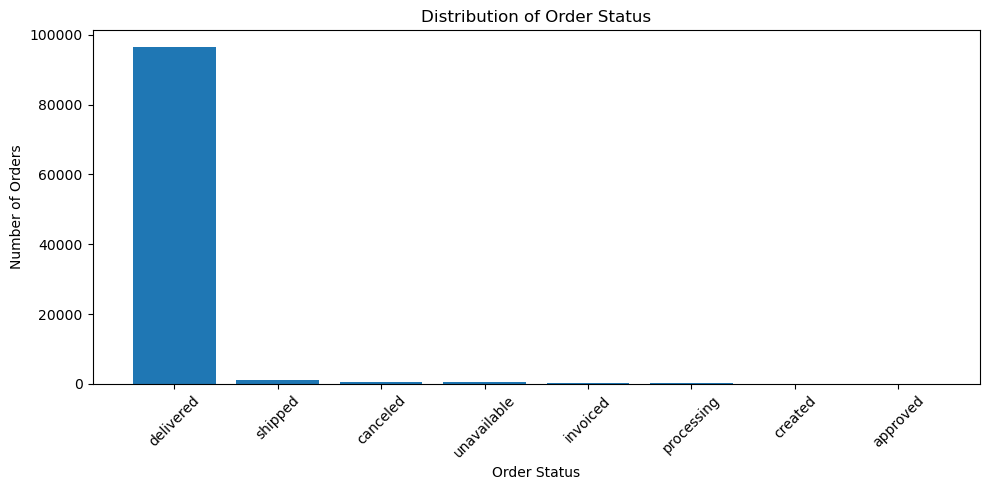

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    status_summary["order_status"],
    status_summary["order_count"]
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Mayoritas order memiliki status Delivered, yaitu 96,478 orders atau sekitar 97.02% dari seluruh
recorded orders.

Hal ini menunjukkan bahwa sebagian besar transaksi dalam dataset telah mencapai tahap
delivery, sementara hanya sebagian kecil order berada pada status lain seperti shipped,
canceled, unavailable, invoiced, atau processing.

Pada tahap Data Understanding, seluruh order status tetap dianalisis untuk memahami
komposisi raw dataset.

Namun, untuk modeling, hanya order dengan status **Delivered** yang akan dianggap sebagai
eligible transaction. Historical customer behavior dan future return outcome akan dibentuk
hanya berdasarkan completed purchases tersebut.

### Missing Delivery Date by Order Status

Untuk memahami missing values pada `order_delivered_customer_date`, dilakukan cross-check antara order status dan ketersediaan delivery date.

Pemeriksaan ini membantu melihat apakah missing delivery date terutama berasal dari order yang belum atau tidak mencapai tahap delivery, sehingga missing values tidak langsung diperlakukan sebagai data error.

In [12]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isna()
).rename(columns={
    False: "delivery_date_present",
    True: "delivery_date_missing"
})

order_delivered_customer_date,delivery_date_present,delivery_date_missing
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


### Interpretation

Missing `order_delivered_customer_date` sebagian besar berkaitan dengan order yang
belum atau tidak mencapai status Delivered.

Sebagai contoh, order dengan status shipped, canceled, unavailable, invoiced, dan processing
sebagian besar atau seluruhnya tidak memiliki customer delivery date. Sebaliknya, hampir
seluruh Delivered orders memiliki delivery date, dengan hanya 8 Delivered orders yang tidak
memiliki timestamp tersebut.

Hal ini menunjukkan bahwa sebagian besar missing delivery date konsisten dengan order
lifecycle dan tidak langsung menunjukkan data quality issue.

Untuk modelling, eligibility transaksi ditentukan berdasarkan `order_status == "delivered"`.
`order_purchase_timestamp` tetap digunakan sebagai timestamp utama untuk membentuk
historical dan future windows.

Delapan Delivered orders yang tidak memiliki `order_delivered_customer_date` tetap
dipertahankan karena order tersebut secara status telah tercatat sebagai Delivered dan memiliki
`order_purchase_timestamp` yang valid.

### Transaction Timeline

Transaction timeline dianalisis untuk memahami periode transaksi yang tersedia dalam raw
Orders dataset dan memastikan `order_purchase_timestamp` dapat digunakan untuk
time-based analysis.

Pemeriksaan ini penting karena churn modelling menggunakan historical observation window
dan future prediction window. Oleh karena itu, periode data yang tersedia harus cukup untuk
membentuk feature window dan mengobservasi actual customer behavior setelah prediction
date.

Timeline pada tahap Data Understanding masih menggambarkan seluruh recorded orders.
Filter **Delivered only** akan diterapkan pada tahap pembentukan modeling dataset.

In [13]:
purchase_dates = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

print("Earliest purchase:", purchase_dates.min())
print("Latest purchase:", purchase_dates.max())

invalid_dates = (
    orders["order_purchase_timestamp"].notna()
    & purchase_dates.isna()
).sum()

print("Unparseable purchase dates:", invalid_dates)

Earliest purchase: 2016-09-04 21:15:19
Latest purchase: 2018-10-17 17:30:18
Unparseable purchase dates: 0


In [14]:
monthly_orders = (
    purchase_dates
    .dt.to_period("M")
    .value_counts()
    .sort_index()
    .rename_axis("month")
    .reset_index(name="order_count")
)

monthly_orders

,month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [15]:
#Create the full sequence of calendar months
all_months = pd.period_range(
    start=purchase_dates.min().to_period("M"),
    end=purchase_dates.max().to_period("M"),
    freq="M"
)

#Count recorded orders and include months with no records.
monthly_counts = (
    purchase_dates
    .dt.to_period("M")
    .value_counts()
    .reindex(all_months, fill_value=0)
    .sort_index()
)

monthly_counts

2016-09       4
2016-10     324
2016-11       0
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

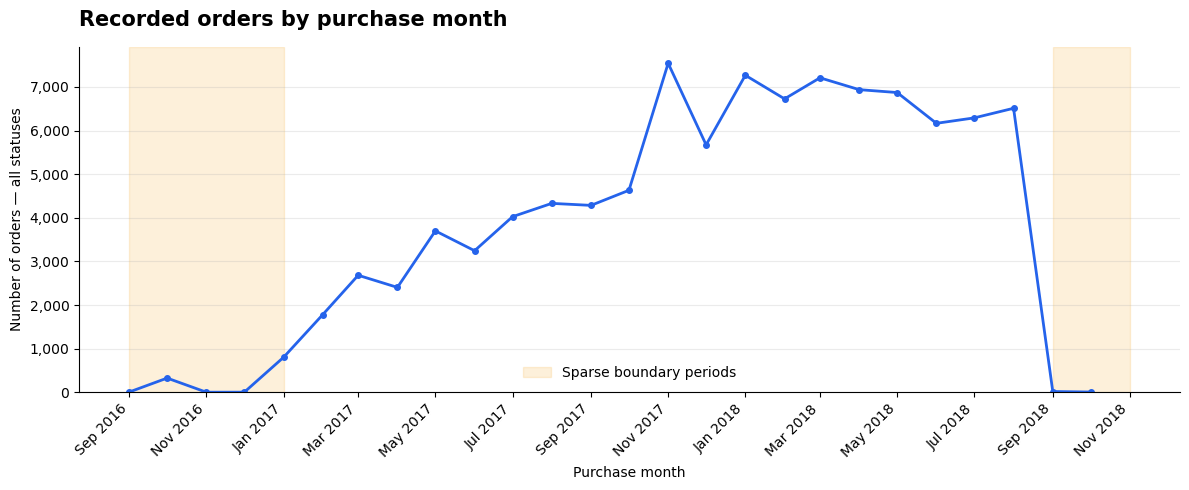

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

# Convert monthly periods into dates for plotting.
month_dates = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    month_dates,
    monthly_counts.values,
    color="#2563EB",
    linewidth=2,
    marker="o",
    markersize=4
)

# Highlight sparse periods for investigation.
ax.axvspan(
    pd.Timestamp("2016-09-01"),
    pd.Timestamp("2017-01-01"),
    color="#F59E0B",
    alpha=0.15,
    label="Sparse boundary periods"
)

ax.axvspan(
    pd.Timestamp("2018-09-01"),
    pd.Timestamp("2018-11-01"),
    color="#F59E0B",
    alpha=0.15
)

ax.set_title(
    "Recorded orders by purchase month",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Purchase month")
ax.set_ylabel("Number of orders — all statuses")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Transaction records tersedia dari **September 2016 hingga Oktober 2018**, dan seluruh `order_purchase_timestamp` dapat dikonversi menjadi datetime tanpa unparseable values.

Monthly order volume menunjukkan bahwa aktivitas transaksi tidak tersebar secara merata sepanjang periode dataset. Periode awal memiliki volume transaksi yang sangat terbatas, termasuk **November 2016 yang tidak memiliki recorded order**, kemudian aktivitas meningkat dan menjadi relatif lebih stabil sepanjang 2017 hingga Agustus 2018.

Pada akhir periode dataset, volume transaksi kembali sangat terbatas, dengan hanya **16 orders pada September 2018** dan **4 orders pada Oktober 2018**.

Kondisi ini penting untuk churn modelling karena historical observation window dan future prediction window membutuhkan periode dengan transaction coverage yang memadai. Oleh karena itu, prediction dates nantinya ditentukan secara time-based agar historical dan future windows berada pada periode data yang memiliki coverage yang cukup, sehingga label churn tidak terbentuk hanya karena keterbatasan data pada akhir observation period.

## Order Items Dataset Understanding

Order Items dataset digunakan untuk memahami informasi produk dan nilai transaksi pada setiap order.

Berbeda dengan Orders dataset yang memiliki satu row untuk setiap order, Order Items dataset dapat memiliki beberapa rows untuk `order_id` yang sama karena satu order dapat terdiri dari lebih dari satu product item.

Pada tahap ini dilakukan pemeriksaan terhadap struktur dataset, data types, missing values, duplicates, serta hubungan antara `order_id` dan `order_item_id` sebelum informasi item diagregasi pada tahap data preparation.

In [17]:
order_items = pd.read_csv(
    data_folder / "olist_order_items_dataset.csv"
)

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [18]:
print(f"Rows: {order_items.shape[0]:,}")
print(f"Columns: {order_items.shape[1]}")

order_items.info()

item_summary = pd.DataFrame({
    "data_type": order_items.dtypes.astype(str),
    "missing_values": order_items.isna().sum(),
    "unique_values": order_items.nunique()
})

item_summary

Rows: 112,650
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,data_type,missing_values,unique_values
order_id,object,0,98666
order_item_id,int64,0,21
product_id,object,0,32951
seller_id,object,0,3095
shipping_limit_date,object,0,93318
price,float64,0,5968
freight_value,float64,0,6999


### Order Items Dataset Summary

Order Items dataset memiliki **112,650 rows dan 7 columns**, tanpa missing values pada seluruh variabel.

Terdapat **98,666 unique `order_id`** dibandingkan dengan 112,650 item records. Hal ini menunjukkan bahwa satu order dapat memiliki lebih dari satu product item, sehingga Order Items dataset berada pada **item level**, bukan order level.

Selain itu, terdapat **32,951 unique products** dan **3,095 unique sellers** pada dataset.

Perbedaan granularity ini penting untuk tahap data preparation. Order Items tidak dapat langsung digabungkan ke Orders tanpa mempertimbangkan multiple items dalam satu order, karena hal tersebut dapat menyebabkan satu order muncul pada beberapa rows dan berpotensi menghasilkan double counting pada customer-level features.

Oleh karena itu, informasi Order Items nantinya akan diagregasi terlebih dahulu pada **order level** sebelum digabungkan dengan Orders dataset.

In [19]:
print(
    f"Fully duplicated rows: "
    f"{order_items.duplicated().sum():,}"
)

print(
    f"Distinct orders represented: "
    f"{order_items['order_id'].nunique():,}"
)

print(
    "Repeated order-and-item combinations:",
    order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Fully duplicated rows: 0
Distinct orders represented: 98,666
Repeated order-and-item combinations: 0


### Interpretation

Tidak ditemukan fully duplicated rows maupun repeated combination antara `order_id` dan `order_item_id`.

Dengan demikian, multiple rows untuk `order_id` yang sama merepresentasikan item yang berbeda dalam satu order, bukan duplicate records.

Hal ini mengonfirmasi bahwa `order_id` + `order_item_id` dapat digunakan untuk membedakan setiap item secara unik, sementara agregasi ke **order level** tetap diperlukan sebelum data digabungkan dengan Orders dataset.

In [20]:
items_per_order = (
    order_items
    .groupby("order_id")
    .size()
)

example_order_id = (
    items_per_order[items_per_order == 3]
    .index[0]
)

example_items = (
    order_items.loc[
        order_items["order_id"] == example_order_id,
        [
            "order_id",
            "order_item_id",
            "product_id",
            "price",
            "freight_value"
        ]
    ]
    .sort_values("order_item_id")
)

example_items

,order_id,order_item_id,product_id,price,freight_value
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,21.33,15.1
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,21.33,15.1
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,21.33,15.1


### Multi-Item Order Example

Contoh di atas menunjukkan bahwa satu `order_id` dapat memiliki beberapa `order_item_id`, yang merepresentasikan beberapa item dalam satu transaksi.

Pada contoh tersebut, satu order memiliki **3 item records**. Hal ini memperkuat bahwa Order Items dataset memiliki granularity pada **item level**, sehingga agregasi ke **order level** diperlukan sebelum digabungkan dengan Orders dataset untuk menghindari double counting.

### Price & Freight Value Understanding

Setelah memahami struktur item-level pada Order Items dataset, dilakukan pemeriksaan terhadap `price` dan `freight_value` untuk memahami nilai transaksi yang nantinya digunakan dalam pembentukan monetary features.

Pemeriksaan mencakup contoh agregasi nilai pada multi-item order, descriptive statistics, serta pengecekan zero dan negative values.

In [21]:
print(f"Number of items: {len(example_items)}")

print(
    f"Merchandise value: "
    f"BRL {example_items['price'].sum():,.2f}"
)

print(
    f"Freight charges: "
    f"BRL {example_items['freight_value'].sum():,.2f}"
)

Number of items: 3
Merchandise value: BRL 63.99
Freight charges: BRL 45.30


In [22]:
order_items[["price", "freight_value"]].describe().round(2)

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


In [23]:
value_checks = pd.DataFrame({
    "zero_values": (
        order_items[["price", "freight_value"]] == 0
    ).sum(),
    "negative_values": (
        order_items[["price", "freight_value"]] < 0
    ).sum()
})

value_checks

,zero_values,negative_values
price,0,0
freight_value,383,0


### Interpretation

Nilai `price` dan `freight_value` tersedia untuk seluruh **112,650 item records** tanpa missing values maupun negative values.

Distribusi `price` memiliki variasi yang cukup besar, dengan median **BRL 74.99**, mean **BRL 120.65**, dan maksimum **BRL 6,735.00**. Perbedaan antara mean dan median serta nilai maksimum yang jauh lebih tinggi menunjukkan adanya transaksi dengan harga yang relatif tinggi dibandingkan mayoritas item.

`freight_value` memiliki median **BRL 16.26** dan mean **BRL 19.99**. Terdapat **383 item records dengan freight value sebesar 0**, tetapi tidak ditemukan negative freight values.

Pada multi-item order, nilai merchandise dan freight dapat muncul pada beberapa item dalam order yang sama. Oleh karena itu, nilai-nilai tersebut nantinya perlu diagregasi pada **order level** sebelum digunakan dalam pembentukan customer-level features.

### Cross-Dataset Matching Check

Sebelum proses merge, dilakukan pemeriksaan hubungan antar dataset untuk memastikan apakah setiap order memiliki matching item records dan customer record.

Pemeriksaan ini penting untuk mengidentifikasi order yang tidak memiliki informasi item serta memastikan bahwa proses penggabungan dataset nantinya tidak secara tidak sengaja menghilangkan recorded orders.

In [24]:
#Orders with no matching item records
orders_without_items = orders.loc[
    ~orders["order_id"].isin(order_items["order_id"])
]

#Item rows with no matching order record
items_without_orders = order_items.loc[
    ~order_items["order_id"].isin(orders["order_id"])
]

print(f"Orders without items: {len(orders_without_items):,}")
print(f"Item rows without orders: {len(items_without_orders):,}")

Orders without items: 775
Item rows without orders: 0


In [25]:
orders_without_items["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [26]:
orders_without_customers = orders.loc[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print(
    f"Orders without matching customer records: "
    f"{len(orders_without_customers):,}"
)

Orders without matching customer records: 0


### Interpretation

Terdapat 775 orders yang tidak memiliki matching item records, sedangkan seluruh Order
Items records memiliki matching `order_id` pada Orders dataset.

Dari 775 orders tanpa item records, mayoritas memiliki status Unavailable (603) dan Canceled
(164), sementara sisanya terdiri dari Created (5), Invoiced (2), dan Shipped (1). Tidak terdapat
Delivered orders pada kelompok ini.

Selain itu, seluruh orders memiliki matching customer records, sehingga tidak ditemukan order
yang kehilangan informasi customer pada proses pencocokan Orders dan Customers.

Karena modeling population nantinya hanya menggunakan order dengan status **Delivered**,
seluruh 775 orders tanpa matching item records tersebut tidak termasuk dalam eligible
transactions untuk historical behavior maupun future churn labelling.

Dengan demikian, tidak adanya item records pada kelompok tersebut tidak menyebabkan
kehilangan eligible Delivered transactions ketika modeling dataset dibentuk.

### Data Understanding Summary

Berdasarkan proses data understanding, beberapa temuan utama adalah:

1. `customer_unique_id` digunakan sebagai customer identifier utama karena
customer yang sama dapat muncul dengan `customer_id` yang berbeda pada order
yang berbeda.

2. Orders dataset memiliki 99,441 unique orders dan mayoritas berstatus Delivered.
Seluruh order status tetap dianalisis pada tahap Data Understanding, namun hanya order
dengan status **Delivered** yang akan digunakan sebagai eligible customer activity pada
modeling dataset.

3. `order_purchase_timestamp` tersedia tanpa missing values dan digunakan
sebagai timestamp utama untuk time-based churn modelling.

4. Transaction timeline menunjukkan adanya sparse periods pada awal dan akhir
dataset, sehingga prediction window nantinya perlu ditentukan secara time-based
agar memiliki historical dan future coverage yang memadai.

5. Order Items dataset berada pada item level, dengan 112,650 item records yang
merepresentasikan 98,666 unique orders.

6. Karena satu order dapat memiliki beberapa items, Order Items perlu diagregasi
terlebih dahulu menjadi one row per order sebelum digabungkan dengan Orders
dataset untuk menghindari double counting.

7. Tidak ditemukan duplicate records utama pada Customers, Orders, maupun Order
Items, dan seluruh orders memiliki matching customer records. Selain itu, seluruh
orders tanpa matching item records merupakan non-Delivered orders sehingga tidak
termasuk dalam eligible modeling transactions.

Temuan tersebut menjadi dasar untuk tahap Data Preparation, termasuk standardisasi data
type, agregasi Order Items, penggabungan dataset, serta pembentukan eligible modeling
dataset menggunakan Delivered orders.

# Data Preparation

Setelah memahami struktur dan kualitas masing-masing dataset, tahap berikutnya adalah menyiapkan data sebelum proses penggabungan dan feature construction.

Data preparation dilakukan dengan tetap mempertahankan struktur dan informasi pada dataset original. Tahap ini mencakup pembuatan working copy, standardisasi data type, agregasi Order Items dari item level ke order level, serta penggabungan dataset yang dibutuhkan untuk membentuk modeling dataset.

In [27]:
#Keep original dataset fresh

customers_clean = customers.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy()

### Create Working Copies

Working copies dibuat agar proses data preparation tidak mengubah raw dataset secara langsung.

Dataset original tetap dipertahankan, sedangkan proses standardisasi, agregasi, dan merge selanjutnya dilakukan menggunakan `customers_clean`, `orders_clean`, dan `order_items_clean`.

In [28]:
#Date time standardization

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors="raise"
    )

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"],
    errors="raise"
)

orders_clean[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

### Datetime Standardization

Kolom timestamp pada Orders dan Order Items dikonversi menjadi format datetime agar dapat digunakan secara konsisten dalam time-based analysis.

`order_purchase_timestamp` menjadi timestamp utama dalam pembentukan historical observation window dan future prediction window pada tahap churn labelling.

Hasil pemeriksaan menunjukkan bahwa kolom tanggal pada Orders telah berhasil dikonversi menjadi format `datetime64[ns]`.

In [29]:
#Sumamry one row per order

order_totals = (
    order_items_clean
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "size"),
        merchandise_value=("price", "sum"),
        freight_total=("freight_value", "sum")
    )
)

order_totals.head()

,order_id,item_count,merchandise_value,freight_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


### Order-Level Aggregation

`Order Items` memiliki granularity pada item level, sehingga satu `order_id` dapat muncul pada beberapa rows ketika satu order memiliki lebih dari satu item.

Sebelum digabungkan dengan Orders dataset, informasi item diagregasi terlebih dahulu menjadi **one row per order** dengan membentuk:

- `item_count`: jumlah item dalam setiap order,
- `merchandise_value`: total nilai produk dalam setiap order,
- `freight_total`: total freight value dalam setiap order.

Hasil agregasi menghasilkan **98,666 unique orders**, sehingga setiap `order_id` pada `order_totals` hanya memiliki satu row.

Tahap ini penting untuk mencegah **double counting** ketika data nantinya digunakan untuk membentuk customer-level historical features.

In [30]:
print(f"Rows: {len(order_totals):,}")
print(f"Unique orders: {order_totals['order_id'].nunique():,}")

Rows: 98,666
Unique orders: 98,666


## Merge & Prepared Dataset

Setelah Order Items diagregasi menjadi one row per order, customer information, order information, dan aggregated item information digabungkan untuk membentuk prepared order-level dataset.

Merge dilakukan dengan tetap mempertahankan **one row per order** agar historical customer behavior dapat dihitung secara konsisten tanpa menggandakan jumlah transaksi.

In [31]:
#Merge orders and customer into prepared dataset

orders_prepared = orders_clean.merge(
    customers_clean[
        [
            "customer_id",
            "customer_unique_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

In [32]:
#Merge orders total into prepared dataset

orders_prepared = orders_prepared.merge(
    order_totals,
    on="order_id",
    how="left",
    validate="one_to_one"
)

orders_prepared["has_item_records"] = (
    orders_prepared["item_count"].notna()
)

In [33]:
orders_prepared[
    [
        "order_id",
        "customer_unique_id",
        "order_status",
        "order_purchase_timestamp",
        "item_count",
        "merchandise_value",
        "freight_total",
        "has_item_records"
    ]
].head(1).T

,0
order_id,e481f51cbdc54678b7cc49136f2d6af7
customer_unique_id,7c396fd4830fd04220f754e42b4e5bff
order_status,delivered
order_purchase_timestamp,2017-10-02 10:56:33
item_count,1.0
merchandise_value,29.99
freight_total,8.72
has_item_records,True


### Prepared Dataset Structure

Hasil merge membentuk `orders_prepared` sebagai dataset pada **order level**, dengan setiap row merepresentasikan satu recorded order.

Dataset ini menggabungkan:

- customer identifier melalui `customer_unique_id`,
- order information dan `order_purchase_timestamp`,
- jumlah item melalui `item_count`,
- nilai transaksi melalui `merchandise_value`,
- freight melalui `freight_total`, dan
- `has_item_records` untuk menandai apakah order memiliki matching records pada Order Items dataset.

Struktur **one row per order** dipertahankan agar jumlah transaksi tidak terduplikasi sebelum historical customer features dibentuk pada tahap selanjutnya.

In [34]:
#Crosscheck merging results

assert len(orders_prepared) == len(orders_clean)
assert orders_prepared["order_id"].is_unique
assert orders_prepared["customer_unique_id"].notna().all()

assert np.isclose(
    orders_prepared["merchandise_value"].sum(),
    order_items_clean["price"].sum()
)

assert np.isclose(
    orders_prepared["freight_total"].sum(),
    order_items_clean["freight_value"].sum()
)

print("Checks passed: orders preserved and amounts reconciled.")

Checks passed: orders preserved and amounts reconciled.


### Merge Validation

Cross-check dilakukan untuk memastikan proses merge tidak mengubah struktur maupun nilai transaksi pada dataset.

Hasil validation menunjukkan bahwa:

- jumlah order tetap dipertahankan setelah merge,
- setiap `order_id` tetap unique,
- seluruh order memiliki `customer_unique_id`,
- total `merchandise_value` tetap sesuai dengan nilai pada Order Items, dan
- total `freight_total` juga tetap konsisten.

Dengan demikian, proses merge berhasil mempertahankan **one row per order** tanpa menyebabkan duplicate orders maupun perubahan pada aggregated transaction values.

In [35]:
#Prepared dataset summary

print(f"Prepared rows: {len(orders_prepared):,}")

print(
    "Orders missing a customer:",
    orders_prepared["customer_unique_id"].isna().sum()
)

print(
    "Orders without item records:",
    (~orders_prepared["has_item_records"]).sum()
)

Prepared rows: 99,441
Orders missing a customer: 0
Orders without item records: 775


### Prepared Dataset Summary

Prepared dataset memiliki 99,441 rows, sesuai dengan jumlah recorded orders pada Orders
dataset. Tidak terdapat order yang kehilangan customer identifier setelah proses merge.

Terdapat 775 orders tanpa matching item records pada Order Items dataset. Berdasarkan
cross-dataset check sebelumnya, seluruh order tersebut merupakan non-Delivered orders.

`orders_prepared` tetap mempertahankan seluruh recorded orders sebagai master prepared
dataset untuk kebutuhan data quality auditing.

Namun, pada tahap pembentukan modeling population, hanya order dengan status
**Delivered** yang akan dianggap sebagai eligible transaction.

Dengan demikian, orders tanpa matching item records tidak akan termasuk dalam historical
customer behavior maupun future return labelling karena seluruhnya berstatus non-Delivered.

In [36]:
#Set item_count as integer

orders_prepared["item_count"] = (
    orders_prepared["item_count"].astype("Int64")
)

In [37]:
#Flagging anomaly orders

date_checks = pd.DataFrame(
    {
        "approval_before_purchase": (
            orders_prepared["order_approved_at"]
            < orders_prepared["order_purchase_timestamp"]
        ),
        "carrier_before_purchase": (
            orders_prepared["order_delivered_carrier_date"]
            < orders_prepared["order_purchase_timestamp"]
        ),
        "delivery_before_purchase": (
            orders_prepared["order_delivered_customer_date"]
            < orders_prepared["order_purchase_timestamp"]
        ),
        "delivery_before_carrier": (
            orders_prepared["order_delivered_customer_date"]
            < orders_prepared["order_delivered_carrier_date"]
        )
    },
    index=orders_prepared.index
)

date_checks.sum().sort_values(ascending=False)

carrier_before_purchase     166
delivery_before_carrier      23
approval_before_purchase      0
delivery_before_purchase      0
dtype: int64

In [38]:
#List order that get flagged

date_issue_rows = orders_prepared.loc[
    date_checks.any(axis=1),
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
]

print(f"Orders with a date-sequence flag: {len(date_issue_rows):,}")

date_issue_rows.head(10)

Orders with a date-sequence flag: 189


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,2018-08-16 13:50:48,2018-08-16 14:05:13,2018-08-16 13:27:00,2018-08-24 14:58:37
1111,ad133696906f6a78826daa0911b7daec,delivered,2018-06-15 15:41:22,2018-06-15 16:19:23,2018-06-15 14:52:00,2018-06-22 18:09:37
1329,74e033208dc13a7b8127eb8e73d09b76,delivered,2018-05-02 10:48:44,2018-05-02 11:13:45,2018-05-02 09:49:00,2018-05-07 23:06:36
1372,a6b58794fd2ba533359a76c08df576e3,delivered,2018-05-14 15:18:23,2018-05-14 15:33:35,2018-05-14 13:46:00,2018-05-19 19:33:32
1864,5792e0b1c8c8a2bf53af468c9a422c88,delivered,2018-07-26 13:25:14,2018-07-26 13:35:14,2018-07-26 12:42:00,2018-07-30 14:45:02
2760,c3eb293fd154223498b6551a728203e8,delivered,2018-07-19 14:06:04,2018-07-19 14:22:51,2018-07-19 13:49:00,2018-07-24 19:35:36
3473,b0c2a7d04b165525254254a728c50a4e,delivered,2018-06-07 13:28:30,2018-06-07 13:57:22,2018-06-07 13:22:00,2018-06-21 17:36:43
3661,2033a4586b5bec3229ebc1675a8ae092,delivered,2018-06-12 10:10:25,2018-06-12 10:39:59,2018-06-12 10:09:00,2018-06-19 14:08:27
4114,08adcddad19d3acf37d1fa01cb9ded1e,delivered,2018-06-27 11:16:44,2018-06-27 11:30:56,2018-06-27 10:57:00,2018-06-29 17:39:53
4159,dee6298ce7d1fb2645141ef9972157aa,shipped,2018-04-30 14:06:12,2018-04-30 14:15:24,2018-04-30 12:59:00,NaT


### Date Sequence Validation

Pemeriksaan terhadap urutan timestamp menemukan 189 orders dengan setidaknya satu
date-sequence anomaly.

Anomaly terutama berasal dari:

- 166 orders dengan `order_delivered_carrier_date` yang tercatat sebelum
  `order_purchase_timestamp`.
- 23 orders dengan `order_delivered_customer_date` yang tercatat sebelum
  `order_delivered_carrier_date`.
- Tidak ditemukan order dengan approval atau customer delivery date sebelum purchase
  timestamp.

Anomaly tersebut dicatat sebagai data quality findings, namun tidak langsung digunakan
untuk menghapus order dari `orders_prepared`.

Hal ini karena time-based modelling menggunakan `order_purchase_timestamp` sebagai
timestamp utama untuk menentukan historical observation window dan future prediction
window. `order_purchase_timestamp` juga telah terkonfirmasi tidak memiliki missing maupun
unparseable values.

Flagged delivery-related timestamps tetap dipertahankan sebagai informasi data quality.
Eligibility transaksi untuk modelling ditentukan secara terpisah berdasarkan
`order_status == "delivered"`.

In [39]:
#Flagging anomaly delivery status

status_checks = pd.DataFrame(
    {
        "delivered_without_delivery_date": (
            orders_prepared["order_status"].eq("delivered")
            & orders_prepared["order_delivered_customer_date"].isna()
        ),
        "canceled_with_delivery_date": (
            orders_prepared["order_status"].eq("canceled")
            & orders_prepared["order_delivered_customer_date"].notna()
        )
    },
    index=orders_prepared.index
)

status_checks.sum()

delivered_without_delivery_date    8
canceled_with_delivery_date        6
dtype: int64

In [40]:
#Attach flagging results into prepared dataset

for column in date_checks.columns:
    orders_prepared[column] = date_checks[column]

for column in status_checks.columns:
    orders_prepared[column] = status_checks[column]

# Add a summary flag for date-sequence issues.
orders_prepared["has_date_sequence_issue"] = (
    date_checks.any(axis=1)
)

In [41]:
#Prepared dataset summary

preparation_summary = pd.Series({
    "total_orders": len(orders_prepared),
    "unique_orders": orders_prepared["order_id"].nunique(),
    "missing_customer_identifier": (
        orders_prepared["customer_unique_id"].isna().sum()
    ),
    "orders_without_items": (
        (~orders_prepared["has_item_records"]).sum()
    ),
    "orders_with_date_sequence_issue": (
        orders_prepared["has_date_sequence_issue"].sum()
    ),
    "delivered_without_delivery_date": (
        orders_prepared["delivered_without_delivery_date"].sum()
    ),
    "canceled_with_delivery_date": (
        orders_prepared["canceled_with_delivery_date"].sum()
    )
}, name="count")

preparation_summary

total_orders                       99441
unique_orders                      99441
missing_customer_identifier            0
orders_without_items                 775
orders_with_date_sequence_issue      189
delivered_without_delivery_date        8
canceled_with_delivery_date            6
Name: count, dtype: int64

### Data Quality Flags & Preparation Summary

Sebagai tahap akhir data preparation, beberapa data quality flags ditambahkan untuk
mendokumentasikan inkonsistensi pada timestamp dan delivery status tanpa menghapus
record dari master prepared dataset.

Diagnostic flags ini digunakan untuk auditing dan quality assessment, bukan secara otomatis
sebagai predictor pada model.

Setelah itu, dilakukan summary terhadap `orders_prepared` untuk memastikan jumlah order
tetap terjaga dan seluruh data-quality findings telah terdokumentasi.

`orders_prepared` tetap mempertahankan seluruh recorded orders sebagai prepared master
dataset. Eligibility transaksi untuk modelling akan ditentukan pada tahap berikutnya dengan
menggunakan hanya order berstatus **Delivered**.

In [42]:
show_text(
    """
    The three source tables were combined into an order-level
    prepared dataset containing 99,441 unique recorded orders.

    Timestamp columns were converted to datetime, and item values were
    aggregated before joining to prevent duplicated purchase counts.

    All orders matched customer records, while 775 orders had no item
    records. Cross-dataset validation showed that all 775 orders were
    non-Delivered orders.

    Date-sequence checks flagged 189 orders, and additional status–
    delivery inconsistencies were recorded.

    All recorded orders are retained in `orders_prepared` for auditing
    and data-quality assessment.

    For modelling, transaction eligibility is defined separately:
    only orders with status Delivered are treated as completed purchases.
    """
)


    The three source tables were combined into an order-level
    prepared dataset containing 99,441 unique recorded orders.

    Timestamp columns were converted to datetime, and item values were
    aggregated before joining to prevent duplicated purchase counts.

    All orders matched customer records, while 775 orders had no item
    records. Cross-dataset validation showed that all 775 orders were
    non-Delivered orders.

    Date-sequence checks flagged 189 orders, and additional status–
    delivery inconsistencies were recorded.

    All recorded orders are retained in `orders_prepared` for auditing
    and data-quality assessment.

    For modelling, transaction eligibility is defined separately:
    only orders with status Delivered are treated as completed purchases.
    

## Modeling Order Eligibility

Untuk modelling, hanya transaksi dengan `order_status == "delivered"` yang dianggap
sebagai completed purchase dan eligible customer activity.

Non-Delivered orders seperti Canceled, Unavailable, Shipped, Invoiced, Processing,
Created, dan Approved tidak digunakan untuk:

- membentuk historical customer behavior,
- menghitung repeat purchase behavior,
- menentukan future customer return,
- maupun membentuk churn label.

Pendekatan ini memastikan bahwa customer activity merepresentasikan transaksi yang telah
selesai, bukan sekadar order yang pernah dibuat tetapi belum atau tidak berhasil diselesaikan.

`orders_prepared` tetap dipertahankan sebagai master prepared dataset, sedangkan
`modeling_orders` digunakan sebagai source utama untuk seluruh analisis customer behavior
dan modelling setelah tahap ini.

In [43]:
# ============================================================
# MODELING ELIGIBILITY — DELIVERED ORDERS ONLY
# ============================================================

modeling_orders = (
    orders_prepared.loc[
        orders_prepared["order_status"].eq("delivered")
    ]
    .copy()
)

print("MODELING ORDER ELIGIBILITY")
print("-" * 40)

print(f"All prepared orders       : {len(orders_prepared):,}")
print(f"Eligible Delivered orders : {len(modeling_orders):,}")
print(
    "Eligible customers       :",
    f"{modeling_orders['customer_unique_id'].nunique():,}"
)

print(
    "Orders without items     :",
    (~modeling_orders["has_item_records"]).sum()
)

print(
    "Missing customer ID      :",
    modeling_orders["customer_unique_id"].isna().sum()
)

assert modeling_orders["order_status"].eq("delivered").all()
assert modeling_orders["order_id"].is_unique
assert modeling_orders["customer_unique_id"].notna().all()
assert modeling_orders["has_item_records"].all()

print("\nEligibility checks passed.")

MODELING ORDER ELIGIBILITY
----------------------------------------
All prepared orders       : 99,441
Eligible Delivered orders : 96,478
Eligible customers       : 93,358
Orders without items     : 0
Missing customer ID      : 0

Eligibility checks passed.


In [44]:
from IPython.display import display, Markdown

# ============================================================
# SUMMARY FIGURES
# ============================================================

# ------------------------------------------------------------
# Raw / prepared dataset figures
# ------------------------------------------------------------

total_orders = len(orders_prepared)

total_customers = customers["customer_unique_id"].nunique()

delivered_percentage = (
    orders_prepared["order_status"]
    .eq("delivered")
    .mean()
    * 100
)

orders_without_items_count = (
    ~orders_prepared["has_item_records"]
).sum()

delivered_without_items_count = (
    (
        orders_prepared["order_status"].eq("delivered")
        & ~orders_prepared["has_item_records"]
    )
    .sum()
)

missing_customer_count = (
    orders_prepared["customer_unique_id"]
    .isna()
    .sum()
)

unmatched_item_rows = (
    ~order_items["order_id"].isin(orders["order_id"])
).sum()

date_issue_count = (
    date_checks.any(axis=1).sum()
)

date_issue_percentage = (
    date_issue_count / total_orders * 100
)

median_price = order_items["price"].median()
mean_price = order_items["price"].mean()

zero_freight_count = (
    order_items["freight_value"]
    .eq(0)
    .sum()
)

monthly_purchase_counts = (
    orders_prepared["order_purchase_timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

peak_month = (
    monthly_purchase_counts
    .idxmax()
    .strftime("%B %Y")
)

peak_month_orders = (
    monthly_purchase_counts.max()
)

duplicate_rows = {
    "Customers": customers.duplicated().sum(),
    "Orders": orders.duplicated().sum(),
    "Order items": order_items.duplicated().sum()
}

duplicate_item_keys = (
    order_items
    .duplicated(
        subset=["order_id", "order_item_id"]
    )
    .sum()
)

merchandise_reconciled = np.isclose(
    orders_prepared["merchandise_value"].sum(),
    order_items["price"].sum()
)

freight_reconciled = np.isclose(
    orders_prepared["freight_total"].sum(),
    order_items["freight_value"].sum()
)

# ------------------------------------------------------------
# Modeling-eligible figures: DELIVERED ONLY
# ------------------------------------------------------------

eligible_orders = len(modeling_orders)

eligible_customers = (
    modeling_orders["customer_unique_id"]
    .nunique()
)

orders_per_customer = (
    modeling_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customers = (
    orders_per_customer.gt(1).sum()
)

repeat_percentage = (
    repeat_customers
    / eligible_customers
    * 100
)

print("Summary figures created.")

Summary figures created.


In [45]:
display(Markdown("# Ringkasan Data Understanding"))

display(Markdown(f"""
## Ringkasan Dataset & Preparation

Berdasarkan proses data understanding dan preparation awal:

| Area | Temuan Utama | Implikasi |
|---|---|---|
| Customers | {len(customers):,} records mewakili {total_customers:,} unique customers | `customer_unique_id` digunakan sebagai identifier customer antar-order. |
| Orders | {orders["order_id"].nunique():,} unique recorded orders | Raw order data dipertahankan untuk data understanding dan preparation. |
| Eligible Orders | {eligible_orders:,} Delivered orders | Hanya completed purchases yang digunakan untuk repeat purchase analysis, churn labelling, dan modelling. |
| Eligible Customers | {eligible_customers:,} customers | Modeling population dibentuk dari customer yang memiliki minimal satu Delivered order. |
| Order Items | {len(order_items):,} item records dari {order_items["order_id"].nunique():,} orders | Order Items diagregasi sebelum digabungkan untuk menghindari double counting. |
| Customer Matching | {missing_customer_count:,} order tanpa customer identifier | Seluruh order dapat dihubungkan dengan customer. |
| Missing Item Records | {orders_without_items_count:,} recorded orders tidak memiliki item records | Seluruh order tersebut merupakan non-Delivered dan tidak termasuk eligible modelling transactions. |
| Prepared Dataset | {total_orders:,} rows dan {orders_prepared["order_id"].nunique():,} unique orders | Struktur one row per order berhasil dipertahankan. |

**Merchandise total reconciled:** {bool(merchandise_reconciled)}  
**Freight total reconciled:** {bool(freight_reconciled)}

Hasil tersebut menunjukkan bahwa proses agregasi dan merge mempertahankan jumlah order
serta total nilai transaksi dari source data.
"""))

# Ringkasan Data Understanding


## Ringkasan Dataset & Preparation

Berdasarkan proses data understanding dan preparation awal:

| Area | Temuan Utama | Implikasi |
|---|---|---|
| Customers | 99,441 records mewakili 96,096 unique customers | `customer_unique_id` digunakan sebagai identifier customer antar-order. |
| Orders | 99,441 unique recorded orders | Raw order data dipertahankan untuk data understanding dan preparation. |
| Eligible Orders | 96,478 Delivered orders | Hanya completed purchases yang digunakan untuk repeat purchase analysis, churn labelling, dan modelling. |
| Eligible Customers | 93,358 customers | Modeling population dibentuk dari customer yang memiliki minimal satu Delivered order. |
| Order Items | 112,650 item records dari 98,666 orders | Order Items diagregasi sebelum digabungkan untuk menghindari double counting. |
| Customer Matching | 0 order tanpa customer identifier | Seluruh order dapat dihubungkan dengan customer. |
| Missing Item Records | 775 recorded orders tidak memiliki item records | Seluruh order tersebut merupakan non-Delivered dan tidak termasuk eligible modelling transactions. |
| Prepared Dataset | 99,441 rows dan 99,441 unique orders | Struktur one row per order berhasil dipertahankan. |

**Merchandise total reconciled:** True  
**Freight total reconciled:** True

Hasil tersebut menunjukkan bahwa proses agregasi dan merge mempertahankan jumlah order
serta total nilai transaksi dari source data.


In [46]:
display(Markdown(f"""
## Temuan Utama

### Repeat Purchase

Dari **{eligible_customers:,} customers dengan minimal satu Delivered order**, terdapat
**{repeat_customers:,} customers ({repeat_percentage:.2f}%)** yang memiliki lebih dari
satu Delivered order.

Angka ini merupakan **descriptive repeat-order proportion, bukan churn rate**, karena setiap
customer memiliki periode observasi dan kesempatan untuk melakukan pembelian kembali
yang berbeda.

### Transaction Timeline

Aktivitas transaksi meningkat sepanjang 2017 dan relatif stabil pada sebagian besar periode
2018. Volume tertinggi pada raw recorded-order timeline tercatat sebanyak
**{peak_month_orders:,} orders pada {peak_month}**.

Periode awal dan akhir dataset memiliki jumlah transaksi yang sangat terbatas. Oleh karena itu,
periode tersebut perlu diperhatikan dalam menentukan historical dan future observation window
agar pembentukan label churn tidak dipengaruhi oleh keterbatasan coverage data.

### Order Status

Sebanyak **{delivered_percentage:.2f}%** dari seluruh recorded orders berstatus Delivered.

Untuk modelling, hanya order dengan status **Delivered** yang digunakan sebagai eligible
customer activity. Non-Delivered orders tetap dipertahankan pada `orders_prepared` untuk
data-quality auditing, tetapi tidak digunakan untuk repeat purchase analysis, historical feature
construction, ataupun future churn labelling.
"""))


## Temuan Utama

### Repeat Purchase

Dari **93,358 customers dengan minimal satu Delivered order**, terdapat
**2,801 customers (3.00%)** yang memiliki lebih dari
satu Delivered order.

Angka ini merupakan **descriptive repeat-order proportion, bukan churn rate**, karena setiap
customer memiliki periode observasi dan kesempatan untuk melakukan pembelian kembali
yang berbeda.

### Transaction Timeline

Aktivitas transaksi meningkat sepanjang 2017 dan relatif stabil pada sebagian besar periode
2018. Volume tertinggi pada raw recorded-order timeline tercatat sebanyak
**7,544 orders pada November 2017**.

Periode awal dan akhir dataset memiliki jumlah transaksi yang sangat terbatas. Oleh karena itu,
periode tersebut perlu diperhatikan dalam menentukan historical dan future observation window
agar pembentukan label churn tidak dipengaruhi oleh keterbatasan coverage data.

### Order Status

Sebanyak **97.02%** dari seluruh recorded orders berstatus Delivered.

Untuk modelling, hanya order dengan status **Delivered** yang digunakan sebagai eligible
customer activity. Non-Delivered orders tetap dipertahankan pada `orders_prepared` untuk
data-quality auditing, tetapi tidak digunakan untuk repeat purchase analysis, historical feature
construction, ataupun future churn labelling.


In [47]:
display(Markdown(f"""
## Data Quality & Limitations

Beberapa kondisi data yang perlu diperhatikan:

- **{orders_without_items_count:,} orders** tidak memiliki item records.
- **{date_issue_count:,} orders ({date_issue_percentage:.2f}%)** memiliki setidaknya satu date-sequence flag.
- Terdapat **{status_checks["delivered_without_delivery_date"].sum():,} Delivered orders** tanpa customer delivery date.
- Terdapat **{status_checks["canceled_with_delivery_date"].sum():,} Cancelled orders** yang memiliki customer delivery date.

Record tersebut tidak dihapus atau dikoreksi secara asumtif dari master prepared dataset.
Original timestamps dan transaction values tetap dipertahankan, sementara diagnostic flags
digunakan untuk data-quality auditing.

Namun, modelling eligibility ditentukan berdasarkan `order_status == "delivered"`, sehingga
non-Delivered orders tidak digunakan dalam customer behavior modelling.

Selain itu, dataset tidak menyediakan explicit churn label dan hanya mencatat aktivitas customer
yang tersedia dalam Olist dataset. Karena itu, churn nantinya didefinisikan sebagai **proxy
berdasarkan customer return behavior dalam future observation window**.
"""))


## Data Quality & Limitations

Beberapa kondisi data yang perlu diperhatikan:

- **775 orders** tidak memiliki item records.
- **189 orders (0.19%)** memiliki setidaknya satu date-sequence flag.
- Terdapat **8 Delivered orders** tanpa customer delivery date.
- Terdapat **6 Cancelled orders** yang memiliki customer delivery date.

Record tersebut tidak dihapus atau dikoreksi secara asumtif dari master prepared dataset.
Original timestamps dan transaction values tetap dipertahankan, sementara diagnostic flags
digunakan untuk data-quality auditing.

Namun, modelling eligibility ditentukan berdasarkan `order_status == "delivered"`, sehingga
non-Delivered orders tidak digunakan dalam customer behavior modelling.

Selain itu, dataset tidak menyediakan explicit churn label dan hanya mencatat aktivitas customer
yang tersedia dalam Olist dataset. Karena itu, churn nantinya didefinisikan sebagai **proxy
berdasarkan customer return behavior dalam future observation window**.


In [48]:
display(Markdown("""
## Kesimpulan

Hasil data understanding menunjukkan bahwa dataset telah memiliki struktur yang memadai
untuk membentuk historical customer behavior:

- customer dapat diidentifikasi secara konsisten menggunakan `customer_unique_id`,
- transaksi telah dipertahankan pada one row per order,
- item-level data telah diagregasi untuk mencegah double counting,
- `order_purchase_timestamp` dapat digunakan sebagai dasar analisis berbasis waktu,
- dan order dengan status Delivered telah ditetapkan sebagai eligible completed purchases
  untuk customer behavior modelling.

Repeat purchase yang relatif rendah serta keterbatasan data pada awal dan akhir periode
menunjukkan bahwa churn tidak dapat ditentukan hanya dari keseluruhan histori transaksi.

Tahap selanjutnya adalah melakukan Repeat Purchase Analysis pada eligible Delivered orders,
kemudian menentukan modeling time structure, historical observation window, future prediction
window, dan churn label sebelum customer-level features dibentuk.
"""))


## Kesimpulan

Hasil data understanding menunjukkan bahwa dataset telah memiliki struktur yang memadai
untuk membentuk historical customer behavior:

- customer dapat diidentifikasi secara konsisten menggunakan `customer_unique_id`,
- transaksi telah dipertahankan pada one row per order,
- item-level data telah diagregasi untuk mencegah double counting,
- `order_purchase_timestamp` dapat digunakan sebagai dasar analisis berbasis waktu,
- dan order dengan status Delivered telah ditetapkan sebagai eligible completed purchases
  untuk customer behavior modelling.

Repeat purchase yang relatif rendah serta keterbatasan data pada awal dan akhir periode
menunjukkan bahwa churn tidak dapat ditentukan hanya dari keseluruhan histori transaksi.

Tahap selanjutnya adalah melakukan Repeat Purchase Analysis pada eligible Delivered orders,
kemudian menentukan modeling time structure, historical observation window, future prediction
window, dan churn label sebelum customer-level features dibentuk.


## Repeat Purchase Analysis

Sebelum menetapkan final modeling time window, dilakukan analisis deskriptif terhadap jarak
antara first purchase dan first repeat purchase.

Analisis hanya menggunakan **eligible completed purchases**, yaitu order dengan status
Delivered yang telah disimpan dalam `modeling_orders`.

Analisis ini bertujuan untuk:

- memahami pola umum customer yang benar-benar menyelesaikan transaksi dan kembali
  melakukan pembelian,
- mengukur jarak antara first purchase dan first repeat purchase,
- serta memberikan dasar berbasis data dalam menentukan panjang historical observation
  window dan future prediction window.

Repeat Purchase Analysis tidak digunakan untuk membentuk churn label secara langsung.
Final churn label nantinya tetap ditentukan berdasarkan actual customer behavior pada
future prediction window.

In [49]:
# ============================================================
# REPEAT PURCHASE ANALYSIS — DELIVERED ORDERS ONLY
# ============================================================

repeat_analysis = (
    modeling_orders[
        [
            "customer_unique_id",
            "order_id",
            "order_purchase_timestamp"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    )
    .copy()
)

# Purchase sequence for each customer
repeat_analysis["purchase_rank"] = (
    repeat_analysis
    .groupby("customer_unique_id")
    .cumcount()
    + 1
)

# First completed purchase
first_purchase = (
    repeat_analysis.loc[
        repeat_analysis["purchase_rank"].eq(1)
    ]
    .set_index("customer_unique_id")[
        "order_purchase_timestamp"
    ]
)

# First completed repeat purchase
first_repeat = (
    repeat_analysis.loc[
        repeat_analysis["purchase_rank"].eq(2)
    ]
    .set_index("customer_unique_id")[
        "order_purchase_timestamp"
    ]
)

# Days between first purchase and first repeat
repeat_interval = (
    first_repeat - first_purchase
).dt.days.dropna()

print("Delivered orders used      :", f"{len(modeling_orders):,}")
print(
    "Eligible customers          :",
    f"{modeling_orders['customer_unique_id'].nunique():,}"
)
print(
    "Repeat customers            :",
    f"{len(repeat_interval):,}"
)

Delivered orders used      : 96,478
Eligible customers          : 93,358
Repeat customers            : 2,801


In [50]:
repeat_interval_summary = (
    repeat_interval
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.80,
            0.90,
            0.95
        ]
    )
)

repeat_interval_summary

count    2801.000000
mean       80.844698
std       109.899443
min         0.000000
50%        28.000000
75%       126.000000
80%       161.000000
90%       246.000000
95%       324.000000
max       608.000000
Name: order_purchase_timestamp, dtype: float64

In [51]:
repeat_horizon_summary = pd.DataFrame({
    "horizon_days": [30, 60, 90, 120, 150, 180, 210, 240],
})

repeat_horizon_summary["repeat_customers"] = [
    repeat_interval.le(days).sum()
    for days in repeat_horizon_summary["horizon_days"]
]

repeat_horizon_summary["percentage_of_repeaters"] = (
    repeat_horizon_summary["repeat_customers"]
    / len(repeat_interval)
)

display(
    repeat_horizon_summary.style.format({
        "percentage_of_repeaters": "{:.2%}"
    })
)

,horizon_days,repeat_customers,percentage_of_repeaters
0,30,1423,50.80%
1,60,1718,61.34%
2,90,1912,68.26%
3,120,2074,74.04%
4,150,2203,78.65%
5,180,2322,82.90%
6,210,2428,86.68%
7,240,2507,89.50%


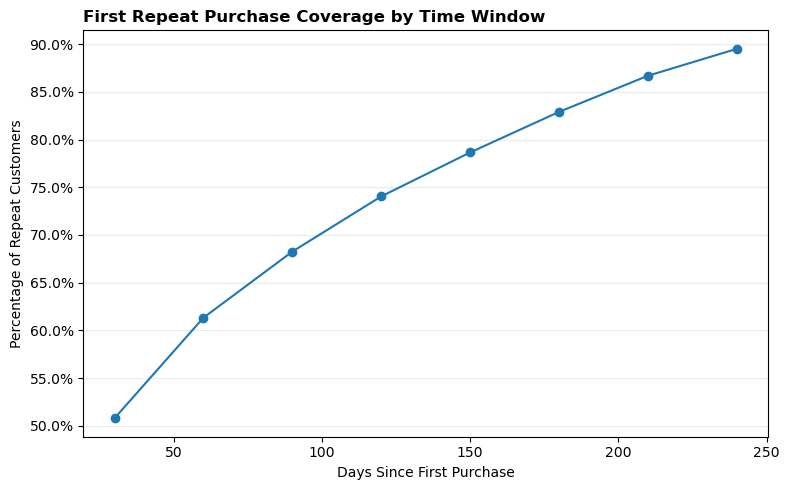

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    repeat_horizon_summary["horizon_days"],
    repeat_horizon_summary["percentage_of_repeaters"],
    marker="o"
)

ax.set_title(
    "First Repeat Purchase Coverage by Time Window",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Days Since First Purchase")
ax.set_ylabel("Percentage of Repeat Customers")

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [53]:
repeat_90 = repeat_interval.le(90)
repeat_180 = repeat_interval.le(180)

print("REPEAT PURCHASE WINDOW COMPARISON")
print("-" * 45)

print(f"Repeat customers total : {len(repeat_interval):,}")

print(
    f"Repeat <= 90 days      : "
    f"{repeat_90.sum():,} "
    f"({repeat_90.mean():.2%})"
)

print(
    f"Repeat <= 180 days     : "
    f"{repeat_180.sum():,} "
    f"({repeat_180.mean():.2%})"
)

print(
    f"Additional repeaters captured by 180d: "
    f"{repeat_180.sum() - repeat_90.sum():,}"
)

REPEAT PURCHASE WINDOW COMPARISON
---------------------------------------------
Repeat customers total : 2,801
Repeat <= 90 days      : 1,912 (68.26%)
Repeat <= 180 days     : 2,322 (82.90%)
Additional repeaters captured by 180d: 410


### Interpretation

Repeat Purchase Analysis dilakukan hanya pada completed purchases dengan status Delivered.

Dari 93,358 eligible customers, terdapat 2,801 customers yang memiliki lebih dari satu
Delivered order. Median waktu antara first purchase dan first repeat purchase adalah 28 hari,
sedangkan 80th percentile berada pada 161 hari.

Dalam 90 hari setelah first purchase, 1,912 repeat customers atau 68.26% telah melakukan
repeat purchase. Ketika horizon diperpanjang menjadi 180 hari, coverage meningkat menjadi
2,322 customers atau 82.90%.

Dengan demikian, penggunaan 90-day window berpotensi tidak menangkap sebagian repeat
behavior yang masih terjadi dalam customer purchase cycle. Sebaliknya, 180-day window
mencakup sebagian besar observed first repeat purchases dan berada di atas 80th percentile
repeat interval.

Berdasarkan pola tersebut, project menggunakan **180-day historical observation window**
untuk membentuk customer behavior features dan **180-day future prediction window**
untuk menentukan actual customer return behavior.

## Time-Based Modeling Setup

Berdasarkan Repeat Purchase Analysis pada completed purchases, digunakan **180 hari sebagai
historical observation window** dan **180 hari sebagai future prediction window**.

Repeat Purchase Analysis menunjukkan bahwa:

- median waktu menuju first repeat purchase adalah sekitar 28 hari,
- 68.26% repeat customers kembali dalam ≤90 hari,
- sekitar 80% repeat customers kembali dalam sekitar 161 hari,
- dan 82.90% repeat customers melakukan first repeat purchase dalam ≤180 hari.

Oleh karena itu, 180-day prediction window dipilih karena mencakup 82.90% dari observed first repeat purchases dan berada di atas 80th percentile repeat interval, sehingga memberikan coverage yang lebih representatif terhadap observed repeat behavior dibandingkan 90-day window

Setiap snapshot menggunakan:

- **180-day historical observation window** untuk membentuk customer features.
- **180-day future prediction window** untuk menentukan actual customer outcome.

Prediction dates dipilih secara time-based dengan mempertimbangkan transaction coverage.
Final test future window dibatasi agar tetap berada pada periode sebelum penurunan tajam
transaction coverage setelah Agustus 2018.

Seluruh historical dan future customer activity pada tahap modelling hanya menggunakan
order dengan status **Delivered**.

In [54]:
#Set timestamp boundary for each dataset needs

LOOKBACK_DAYS = 180
PREDICTION_DAYS = 180

snapshot_dates = {
    "train": pd.Timestamp("2017-09-01"),
    "validation": pd.Timestamp("2017-12-01"),
    "test": pd.Timestamp("2018-03-01")
}

In [55]:
window_rows = []

for split, prediction_date in snapshot_dates.items():
    window_rows.append({
        "split": split,
        "history_start": (
            prediction_date
            - pd.Timedelta(days=LOOKBACK_DAYS)
        ),
        "prediction_date": prediction_date,
        "future_end_exclusive": (
            prediction_date
            + pd.Timedelta(days=PREDICTION_DAYS)
        )
    })

window_summary = pd.DataFrame(window_rows)

window_summary

,split,history_start,prediction_date,future_end_exclusive
0,train,2017-03-05,2017-09-01,2018-02-28
1,validation,2017-06-04,2017-12-01,2018-05-30
2,test,2017-09-02,2018-03-01,2018-08-28


### Interpretation

Setiap snapshot menggunakan struktur waktu yang sama, yaitu 180 hari historical observation
sebelum prediction date dan 180 hari future observation setelah prediction date.

Pembagian dilakukan secara temporal, bukan random split, agar feature construction hanya
menggunakan informasi yang tersedia sebelum masing-masing prediction date.

Prediction dates juga mempertimbangkan transaction coverage pada akhir dataset. Final test
prediction date ditetapkan pada 1 Maret 2018 agar 180-day future observation window tetap
berada pada periode dengan transaction coverage yang memadai dan tidak bergantung pada
sparse records setelah Agustus 2018.

Test snapshot disimpan sebagai final holdout dan tidak digunakan selama model development
dan model selection.

## Training Snapshot

Tahap berikutnya membentuk training snapshot menggunakan prediction date
**1 September 2017**.

Customer behavior selama 180 hari sebelum prediction date digunakan sebagai historical
features, sedangkan aktivitas selama 180 hari setelah prediction date digunakan untuk
menentukan actual return behavior pada future prediction window.

Seluruh transaksi yang digunakan pada historical maupun future window hanya mencakup
completed purchases dengan status Delivered.

In [56]:
prediction_date = snapshot_dates["train"]

history_start = (
    prediction_date
    - pd.Timedelta(days=LOOKBACK_DAYS)
)

future_end = (
    prediction_date
    + pd.Timedelta(days=PREDICTION_DAYS)
)

print("History starts:", history_start)
print("Prediction date:", prediction_date)
print("Future ends, exclusive:", future_end)

History starts: 2017-03-05 00:00:00
Prediction date: 2017-09-01 00:00:00
Future ends, exclusive: 2018-02-28 00:00:00


### Training Observation & Prediction Window

Training snapshot dibentuk menggunakan prediction date **1 September 2017**.

Data dipisahkan menjadi dua periode:

#### Historical Observation Window

Periode 180 hari sebelum prediction date digunakan untuk membentuk customer-level
features.

Data pada periode ini disimpan dalam `history_orders` dan hanya berisi completed purchases
dengan status Delivered yang tersedia sebelum prediction date.

#### Future Prediction Window

Periode 180 hari setelah prediction date digunakan hanya untuk mengobservasi apakah
customer kembali melakukan completed purchase.

Data pada periode ini disimpan dalam `future_orders` dan tidak digunakan sebagai model
features.

Pemisahan historical dan future data dilakukan untuk mencegah data leakage antara feature
construction dan churn labelling.

In [57]:
# Historical Delivered orders: model inputs
history_orders = modeling_orders.loc[
    (
        modeling_orders["order_purchase_timestamp"]
        >= history_start
    )
    & (
        modeling_orders["order_purchase_timestamp"]
        < prediction_date
    )
].copy()

# Future Delivered orders: target only
future_orders = modeling_orders.loc[
    (
        modeling_orders["order_purchase_timestamp"]
        >= prediction_date
    )
    & (
        modeling_orders["order_purchase_timestamp"]
        < future_end
    )
].copy()

print(f"Historical orders: {len(history_orders):,}")
print(f"Future orders: {len(future_orders):,}")

print(
    "Historical customers:",
    f"{history_orders['customer_unique_id'].nunique():,}"
)

print(
    "Future customers:",
    f"{future_orders['customer_unique_id'].nunique():,}"
)

assert history_orders["order_status"].eq("delivered").all()
assert future_orders["order_status"].eq("delivered").all()

Historical orders: 19,295
Future orders: 34,751
Historical customers: 18,805
Future customers: 33,919


### Historical Customer Feature Construction

Historical Delivered orders diagregasi dari order level menjadi customer level.

Untuk setiap customer, dibentuk informasi awal berupa:

- `first_order_date`: transaksi pertama dalam historical window,
- `last_order_date`: transaksi terakhir sebelum prediction date,
- `frequency`: jumlah Delivered orders selama historical window,
- `orders_with_known_value`: jumlah order dengan merchandise value yang tersedia.

Mulai tahap ini, unit analisis berubah dari one row per order menjadi one row per customer.

In [58]:
#Counting historical order per customer

customer_history = (
    history_orders
    .groupby("customer_unique_id")
    .agg(
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        orders_with_known_value=("merchandise_value", "count")
    )
)

customer_history.head()

,first_order_date,last_order_date,frequency,orders_with_known_value
customer_unique_id,,,,
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1
0006fdc98a402fceb4eb0ee528f6a8d4,2017-07-18 09:23:10,2017-07-18 09:23:10,1,1
000a5ad9c4601d2bbdd9ed765d5213b3,2017-08-11 13:45:15,2017-08-11 13:45:15,1,1
000de6019bb59f34c099a907c151d855,2017-08-17 19:10:33,2017-08-17 19:10:33,1,1
0010a452c6d13139e50b57f19f52e04e,2017-07-11 11:22:43,2017-07-11 11:22:43,1,1


### Recency

`recency_days` dihitung sebagai jarak antara prediction date dan transaksi terakhir customer pada historical observation window.

Semakin kecil Recency, semakin dekat aktivitas terakhir customer terhadap prediction date.

In [59]:
#Recency count

customer_history["recency_days"] = (
    prediction_date - customer_history["last_order_date"]
).dt.total_seconds() / 86_400

### Monetary Value

Untuk mengukur nilai transaksi customer selama historical observation window,
`merchandise_value` dari seluruh historical Delivered orders dijumlahkan pada level customer.

Nilai awal disimpan sebagai `known_merchandise_value`, yaitu total merchandise spending
berdasarkan completed purchases yang memiliki nilai transaksi tersedia.

Freight tidak dimasukkan dalam perhitungan karena Monetary difokuskan pada nilai produk
yang dibeli customer.

In [60]:
#Count order amount

customer_history["known_merchandise_value"] = (
    history_orders
    .groupby("customer_unique_id")["merchandise_value"]
    .sum(min_count=1)
)

### Handling Missing Monetary Value

`orders_missing_value` digunakan untuk menghitung apakah terdapat historical Delivered order
yang tidak memiliki informasi merchandise value.

Jika customer memiliki minimal satu eligible historical order dengan missing merchandise value,
nilai `monetary` dipertahankan sebagai missing (`NaN`) agar total spending tidak dianggap
lengkap secara keliru.

Karena modeling population hanya menggunakan Delivered orders, jumlah missing monetary
diharapkan lebih rendah dibandingkan prepared dataset yang masih mencakup seluruh order status.

In [61]:
customer_history["orders_missing_value"] = (
    customer_history["frequency"]
    - customer_history["orders_with_known_value"]
)

customer_history["monetary"] = (
    customer_history["known_merchandise_value"]
    .where(
        customer_history["orders_missing_value"].eq(0)
    )
)

## Churn Label Creation

Setelah customer features dibentuk dari historical observation window, aktivitas customer pada
**180-day future prediction window** digunakan untuk menentukan actual return behavior.

Target `churn_180d` didefinisikan sebagai:

- **0 = Not Churn / Returned**  
  Customer memiliki minimal satu Delivered order dalam 180 hari setelah prediction date.

- **1 = Churn / No New Order**  
  Customer tidak memiliki Delivered order dalam 180 hari setelah prediction date.

`future_orders` hanya digunakan untuk menentukan label dan tidak digunakan sebagai model
features, sehingga informasi setelah prediction date tidak masuk ke feature construction.

In [62]:
returning_customer_ids = (
    future_orders["customer_unique_id"]
    .unique()
)

customer_history["churn_180d"] = (
    ~customer_history.index.isin(returning_customer_ids)
).astype(int)

In [63]:
target_check = (
    customer_history["churn_180d"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

target_check_percentage = (
    target_check / target_check.sum() * 100
)

display(
    pd.DataFrame({
        "customer_count": target_check,
        "percentage": target_check_percentage
    })
)

,customer_count,percentage
churn_180d,,
0,323,1.717628
1,18482,98.282372


## Training Snapshot Dataset

Setelah historical features dan target `churn_180d` terbentuk, data disusun menjadi
`train_snapshot` dengan satu row untuk setiap eligible customer pada prediction date
1 September 2017.

Dataset ini berisi customer identifier, prediction date, historical features
(`recency_days`, `frequency`, dan `monetary`), additional behavioral features
(`total_items` dan `unique_products`), indikator missing monetary value, serta target
`churn_180d`.

Preview berikut digunakan untuk memastikan struktur training snapshot telah terbentuk sesuai
dengan definisi feature dan target sebelumnya.

In [64]:
def attach_item_product_features(
    customer_summary,
    historical_orders,
    item_data
):

    historical_items = item_data[
        ["order_id", "order_item_id", "product_id"]
    ].merge(
        historical_orders[
            ["order_id", "customer_unique_id"]
        ],
        on="order_id",
        how="inner",
        validate="many_to_one"
    )

    product_metrics = (
        historical_items
        .groupby("customer_unique_id")
        .agg(
            total_items=("order_item_id", "size"),
            unique_products=("product_id", "nunique"),
            orders_with_items=("order_id", "nunique"),
            missing_product_ids=(
                "product_id",
                lambda values: values.isna().sum()
            )
        )
    )

    result = customer_summary.drop(
        columns=["total_items", "unique_products"],
        errors="ignore"
    ).join(
        product_metrics,
        how="left",
        validate="one_to_one"
    )

    complete_item_coverage = (
        result["orders_with_items"]
        .fillna(0)
        .eq(result["frequency"])
    )

    result["total_items"] = (
        result["total_items"]
        .where(complete_item_coverage)
    )

    result["unique_products"] = (
        result["unique_products"]
        .where(
            complete_item_coverage
            & result["missing_product_ids"].eq(0)
        )
    )

    result = result.drop(
        columns=[
            "orders_with_items",
            "missing_product_ids"
        ]
    )

    assert result.index.equals(customer_summary.index)

    return result

In [65]:
customer_history = attach_item_product_features(
    customer_summary=customer_history,
    historical_orders=history_orders,
    item_data=order_items_clean
)

In [66]:
train_snapshot = customer_history.reset_index()

train_snapshot["prediction_date"] = prediction_date

preview_columns = [
    "customer_unique_id",
    "prediction_date",
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products",
    "orders_missing_value",
    "churn_180d"
]

train_snapshot[
    preview_columns
].head(10).round(2)

,customer_unique_id,prediction_date,recency_days,frequency,monetary,total_items,unique_products,orders_missing_value,churn_180d
0,0000f46a3911fa3c0805444483337064,2017-09-01,174.12,1,69.00,1,1,0,1
1,0006fdc98a402fceb4eb0ee528f6a8d4,2017-09-01,44.61,1,13.90,1,1,0,1
2,000a5ad9c4601d2bbdd9ed765d5213b3,2017-09-01,20.43,1,76.99,1,1,0,1
3,000de6019bb59f34c099a907c151d855,2017-09-01,14.20,1,229.80,2,2,0,1
4,0010a452c6d13139e50b57f19f52e04e,2017-09-01,51.53,1,299.00,1,1,0,1
5,001147e649a7b1afd577e873841632dd,2017-09-01,0.28,1,170.00,2,1,0,1
6,0011805441c0d1b68b48002f1d005526,2017-09-01,129.43,1,269.00,1,1,0,1
7,0011857aff0e5871ce5eb429f21cdaf5,2017-09-01,64.54,1,174.33,1,1,0,1
8,0011c98589159d6149979563c504cb21,2017-09-01,26.41,1,99.99,1,1,0,1
9,00191a9719ef48ebb5860b130347bf33,2017-09-01,134.52,1,47.90,1,1,0,1


In [67]:
display(
    train_snapshot.describe().T
)

,count,mean,min,25%,50%,75%,max,std
first_order_date,18805,2017-06-12 00:39:55.451528960,2017-03-05 04:18:49,2017-05-02 22:26:38,2017-06-14 09:26:34,2017-07-26 16:45:44,2017-08-31 23:37:47,NaN
last_order_date,18805,2017-06-12 12:27:18.566232320,2017-03-05 04:18:49,2017-05-03 14:31:43,2017-06-14 18:52:29,2017-07-27 08:49:32,2017-08-31 23:37:47,NaN
frequency,18805.0,1.026057,1.0,1.0,1.0,1.0,4.0,0.172144
orders_with_known_value,18805.0,1.026057,1.0,1.0,1.0,1.0,4.0,0.172144
recency_days,18805.0,80.481035,0.015428,35.632269,78.213553,120.394641,179.820266,51.084444
known_merchandise_value,18805.0,138.426338,3.9,45.9,85.99,149.99,7388.0,216.630598
orders_missing_value,18805.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
monetary,18805.0,138.426338,3.9,45.9,85.99,149.99,7388.0,216.630598
churn_180d,18805.0,0.982824,0.0,1.0,1.0,1.0,1.0,0.129931
total_items,18805.0,1.160915,1.0,1.0,1.0,1.0,21.0,0.554279


In [68]:
assert train_snapshot["customer_unique_id"].is_unique

assert len(train_snapshot) == (
    history_orders["customer_unique_id"].nunique()
)

assert train_snapshot["frequency"].ge(1).all()

assert train_snapshot["recency_days"].between(
    0,
    LOOKBACK_DAYS,
    inclusive="right"
).all()

assert train_snapshot["churn_180d"].isin([0, 1]).all()

assert train_snapshot["monetary"].isna().equals(
    train_snapshot["orders_missing_value"].gt(0)
)

assert history_orders["order_status"].eq("delivered").all()

print("Training snapshot checks passed.")

print(
    f"Eligible customers: {len(train_snapshot):,}"
)

print(
    "Customers with incomplete spending:",
    train_snapshot["monetary"].isna().sum()
)

Training snapshot checks passed.
Eligible customers: 18,805
Customers with incomplete spending: 0


### Training Snapshot Validation

Training snapshot menghasilkan 18,805 eligible customers berdasarkan Delivered orders
pada 180-day historical observation window sebelum prediction date 1 September 2017.

Validation checks menunjukkan bahwa:

- setiap row merepresentasikan satu unique customer,
- seluruh customer memiliki minimal satu Delivered order pada historical window,
- `recency_days` berada dalam batas 180-day historical window,
- seluruh target `churn_180d` memiliki nilai valid 0 atau 1,
- dan tidak terdapat customer dengan incomplete monetary value.

Tidak adanya missing monetary value menunjukkan bahwa seluruh eligible Delivered orders
pada training historical window memiliki matching item information yang diperlukan untuk
membentuk transaction value.

Dengan demikian, training snapshot telah memenuhi struktur dan eligibility rules yang
ditetapkan untuk tahap modelling.

In [69]:
target_distribution = (
    train_snapshot["churn_180d"]
    .value_counts()
    .sort_index()
    .rename_axis("churn_180d")
    .reset_index(name="customer_count")
)

target_distribution["percentage"] = (
    target_distribution["customer_count"]
    / len(train_snapshot)
    * 100
)

target_distribution

,churn_180d,customer_count,percentage
0,0,323,1.717628
1,1,18482,98.282372


### Target Distribution

Training snapshot memiliki target yang sangat imbalanced.

Dari 18,805 eligible customers:

- 323 customers (1.72%) melakukan minimal satu recorded Delivered order dalam 180-day future prediction window dan dikategorikan sebagai Returned / Not Churn (0).
- 18,482 customers (98.28%) tidak memiliki recorded Delivered order baru dalam 180-day future prediction window dan dikategorikan sebagai No New Order / Churn Proxy (1).

Class imbalance ini merupakan karakteristik penting dari modelling problem dan perlu
dipertimbangkan dalam model development serta evaluation.

Karena business objective berfokus pada kemampuan model untuk mengidentifikasi customer
yang berpotensi kembali, class **Returned / Not Churn (0)** akan menjadi class of interest
dalam evaluasi model.

In [70]:
# Show customers example from each group

example_columns = [
    "customer_unique_id",
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products",
    "orders_missing_value",
    "churn_180d"
]

examples_by_class = pd.concat([
    train_snapshot.loc[
        train_snapshot["churn_180d"].eq(0),
        example_columns
    ].head(5),

    train_snapshot.loc[
        train_snapshot["churn_180d"].eq(1),
        example_columns
    ].head(5)
])

examples_by_class.round(2)

,customer_unique_id,recency_days,frequency,monetary,total_items,unique_products,orders_missing_value,churn_180d
23,004288347e5e88a27ded2bb23747066c,35.41,1,229.99,1,1,0,0
84,011b4adcd54683b480c4d841250a987f,9.46,1,69.49,1,1,0,0
134,01c289bb06354cdc7e6549570f20ada4,89.20,1,39.99,1,1,0,0
151,02168ea18740a0fdaaa15f11bebba5db,11.13,1,99.80,2,1,0,0
190,029b457bd01199c39136f89e0eddcd3a,109.98,1,98.00,1,1,0,0
0,0000f46a3911fa3c0805444483337064,174.12,1,69.00,1,1,0,1
1,0006fdc98a402fceb4eb0ee528f6a8d4,44.61,1,13.90,1,1,0,1
2,000a5ad9c4601d2bbdd9ed765d5213b3,20.43,1,76.99,1,1,0,1
3,000de6019bb59f34c099a907c151d855,14.20,1,229.80,2,2,0,1
4,0010a452c6d13139e50b57f19f52e04e,51.53,1,299.00,1,1,0,1


### Target Sample Check

Sebagai sanity check, berikut ditampilkan beberapa contoh customer dari masing-masing target
class untuk memastikan bahwa customer Returned (`churn_180d = 0`) dan Churn
(`churn_180d = 1`) telah terbentuk dengan historical features yang sesuai.

### Crosscheck Returned Customer

Sebagai validation terhadap churn labelling, satu customer dengan `churn_180d = 0`
diperiksa secara detail.

Pemeriksaan membandingkan:

- historical Delivered orders yang digunakan untuk membentuk customer features, dan
- future Delivered orders yang hanya digunakan untuk menentukan return behavior.

Crosscheck ini memastikan bahwa informasi setelah prediction date tidak masuk ke feature
construction dan bahwa label Returned terbentuk berdasarkan completed purchase pada
180-day future prediction window.

In [71]:
# Crosscheck one Returned customer

example_returner = train_snapshot.loc[
    train_snapshot["churn_180d"].eq(0),
    "customer_unique_id"
].iloc[0]

example_history = history_orders.loc[
    history_orders["customer_unique_id"].eq(example_returner),
    [
        "order_id",
        "order_purchase_timestamp",
        "merchandise_value"
    ]
].sort_values("order_purchase_timestamp")

example_future = future_orders.loc[
    future_orders["customer_unique_id"].eq(example_returner),
    [
        "order_id",
        "order_purchase_timestamp"
    ]
].sort_values("order_purchase_timestamp")

print("Historical Delivered orders used for features:")
display(example_history)

print("Future Delivered orders used only for the target:")
display(example_future)

Historical Delivered orders used for features:


,order_id,order_purchase_timestamp,merchandise_value
33657,a61d617fbe5bd006e40d3a0988fc844b,2017-07-27 14:13:03,229.99


Future Delivered orders used only for the target:


,order_id,order_purchase_timestamp
40042,08204559bebd39e09ee52dcb56d8faa2,2018-01-14 07:36:54


## Reusable Customer Snapshot Function

Setelah proses pembentukan training snapshot tervalidasi, seluruh proses tersebut dirangkum
ke dalam function `build_customer_snapshot()`.

Function ini menerapkan aturan yang sama untuk setiap prediction date, yaitu:

- menggunakan 180 hari historical observation window untuk membentuk customer features,
- menggunakan 180 hari future prediction window untuk menentukan `churn_180d`,
- hanya menggunakan eligible Delivered orders,
- dan menghasilkan satu row untuk setiap eligible customer.

Penggunaan function yang sama memastikan proses feature construction dan churn labelling
diterapkan secara konsisten pada training, validation, dan test snapshot.

In [72]:
def build_customer_snapshot(
    order_data,
    prediction_date,
    item_data,
    lookback_days=180,
    prediction_days=180
):
    prediction_date = pd.Timestamp(prediction_date)

    history_start = (
        prediction_date - pd.Timedelta(days=lookback_days)
    )

    future_end = (
        prediction_date + pd.Timedelta(days=prediction_days)
    )

    history = order_data.loc[
        (
            order_data["order_purchase_timestamp"] >= history_start
        )
        & (
            order_data["order_purchase_timestamp"] < prediction_date
        )
    ].copy()

    future = order_data.loc[
        (
            order_data["order_purchase_timestamp"] >= prediction_date
        )
        & (
            order_data["order_purchase_timestamp"] < future_end
        )
    ].copy()

    assert history["order_status"].eq("delivered").all()
    assert future["order_status"].eq("delivered").all()

    snapshot = (
        history
        .groupby("customer_unique_id")
        .agg(
            first_order_date=("order_purchase_timestamp", "min"),
            last_order_date=("order_purchase_timestamp", "max"),
            frequency=("order_id", "nunique"),
            orders_with_known_value=("merchandise_value", "count")
        )
    )

    snapshot["recency_days"] = (
        prediction_date - snapshot["last_order_date"]
    ).dt.total_seconds() / 86_400

    snapshot["known_merchandise_value"] = (
        history
        .groupby("customer_unique_id")["merchandise_value"]
        .sum(min_count=1)
    )

    snapshot["orders_missing_value"] = (
        snapshot["frequency"]
        - snapshot["orders_with_known_value"]
    )

    snapshot["monetary"] = (
        snapshot["known_merchandise_value"]
        .where(snapshot["orders_missing_value"].eq(0))
    )

    snapshot = attach_item_product_features(
        customer_summary=snapshot,
        historical_orders=history,
        item_data=item_data
    )

    returning_ids = (
        future["customer_unique_id"].unique()
    )

    snapshot["churn_180d"] = (
        ~snapshot.index.isin(returning_ids)
    ).astype(int)

    snapshot = snapshot.reset_index()
    snapshot["prediction_date"] = prediction_date

    return snapshot

### Function Validation

Function diuji kembali menggunakan training prediction date untuk memastikan hasilnya identik
dengan training snapshot yang sebelumnya dibentuk secara manual.

Dengan demikian, penggunaan function pada validation dan test snapshot tidak mengubah
aturan eligibility, feature construction, maupun churn labelling.

In [73]:
train_snapshot_check = build_customer_snapshot(
    order_data=modeling_orders,
    prediction_date=snapshot_dates["train"],
    item_data=order_items_clean,
    lookback_days=LOOKBACK_DAYS,
    prediction_days=PREDICTION_DAYS
)

pd.testing.assert_frame_equal(
    train_snapshot.sort_index(axis=1),
    train_snapshot_check.sort_index(axis=1)
)

print("Function reproduces the training snapshot exactly.")

Function reproduces the training snapshot exactly.


In [74]:
validation_snapshot = build_customer_snapshot(
    order_data=modeling_orders,
    prediction_date=snapshot_dates["validation"],
    item_data=order_items_clean,
    lookback_days=LOOKBACK_DAYS,
    prediction_days=PREDICTION_DAYS
)

test_snapshot = build_customer_snapshot(
    order_data=modeling_orders,
    prediction_date=snapshot_dates["test"],
    item_data=order_items_clean,
    lookback_days=LOOKBACK_DAYS,
    prediction_days=PREDICTION_DAYS
)

print("Validation and test snapshots created.")

Validation and test snapshots created.


In [75]:
# Check snapshot structure and item/product features

feature_check_rows = []

for split_name, snapshot in [
    ("train", train_snapshot),
    ("validation", validation_snapshot),
    ("test", test_snapshot)
]:
    assert snapshot["customer_unique_id"].is_unique

    assert snapshot["frequency"].ge(1).all()

    assert snapshot["recency_days"].between(
        0,
        LOOKBACK_DAYS,
        inclusive="right"
    ).all()

    assert snapshot["churn_180d"].isin([0, 1]).all()

    assert snapshot["total_items"].dropna().ge(1).all()
    assert snapshot["unique_products"].dropna().ge(1).all()

    complete_metrics = snapshot[
        ["total_items", "unique_products"]
    ].dropna()

    assert complete_metrics["unique_products"].le(
        complete_metrics["total_items"]
    ).all()

    feature_check_rows.append({
        "split": split_name,
        "customers": len(snapshot),
        "returned_customers": (
            snapshot["churn_180d"].eq(0).sum()
        ),
        "returned_percentage": (
            snapshot["churn_180d"].eq(0).mean() * 100
        ),
        "missing_monetary": (
            snapshot["monetary"].isna().sum()
        ),
        "missing_total_items": (
            snapshot["total_items"].isna().sum()
        ),
        "missing_unique_products": (
            snapshot["unique_products"].isna().sum()
        )
    })

snapshot_check_summary = pd.DataFrame(
    feature_check_rows
)

display(
    snapshot_check_summary.style.format({
        "returned_percentage": "{:.2f}%"
    })
)

print("Snapshot feature checks passed.")

,split,customers,returned_customers,returned_percentage,missing_monetary,missing_total_items,missing_unique_products
0,train,18805,323,1.72%,0,0,0
1,validation,26093,389,1.49%,0,0,0
2,test,34069,452,1.33%,0,0,0


Snapshot feature checks passed.


### Validation and Test Snapshot Creation

Function yang telah tervalidasi digunakan untuk membentuk `validation_snapshot` dan
`test_snapshot` berdasarkan prediction date masing-masing.

Setiap snapshot dibentuk secara independen menggunakan:

- 180-day historical observation window,
- 180-day future prediction window,
- hanya eligible Delivered orders,
- serta definisi feature dan target `churn_180d` yang sama dengan training snapshot.

Validation snapshot digunakan selama model development dan model selection.

Test snapshot disimpan sebagai final holdout dan tidak digunakan dalam proses tuning maupun
pemilihan model.

# EDA After Labelling

Setelah target `churn_180d` terbentuk dan training snapshot tervalidasi, dilakukan
Exploratory Data Analysis untuk memahami karakteristik historical customer behavior terhadap
future churn outcome.

EDA difokuskan pada training snapshot agar validation dan test data tidak digunakan untuk
membentuk insight yang dapat memengaruhi model development.

Analisis dimulai dengan feature utama Recency, Frequency, dan Monetary (RFM), kemudian
dilanjutkan dengan behavioral features tambahan yang tersedia.

## RFM Feature Overview

Feature utama yang dianalisis meliputi:

- `recency_days`: jarak waktu sejak Delivered order terakhir customer sebelum prediction date.
- `frequency`: jumlah Delivered orders customer selama 180-day historical observation window.
- `monetary`: total merchandise spending customer dari Delivered orders selama historical
  observation window.
- `churn_180d`: target yang menunjukkan apakah customer kembali melakukan minimal satu
  Delivered order dalam 180 hari setelah prediction date.

In [76]:
feature_columns = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products"
]

### Descriptive Statistics

Descriptive statistics digunakan untuk memahami distribusi awal dari masing-masing RFM feature sebelum dilakukan perbandingan berdasarkan churn outcome.

Nilai percentile digunakan untuk melihat penyebaran feature, terutama karena beberapa variabel seperti `monetary` dapat memiliki distribusi yang tidak simetris.

In [77]:
feature_summary = (
    train_snapshot[feature_columns]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

feature_summary.round(2)

,count,mean,std,min,25%,50%,75%,95%,99%,max
recency_days,18805.0,80.48,51.08,0.02,35.63,78.21,120.39,168.38,177.36,179.82
frequency,18805.0,1.03,0.17,1.00,1.00,1.00,1.00,1.00,2.00,4.00
monetary,18805.0,138.43,216.63,3.90,45.90,85.99,149.99,399.99,997.68,7388.00
total_items,18805.0,1.16,0.55,1.00,1.00,1.00,1.00,2.00,4.00,21.00
unique_products,18805.0,1.06,0.29,1.00,1.00,1.00,1.00,2.00,2.00,7.00


### RFM Initial Findings

Berdasarkan descriptive statistics pada 18,805 customers dalam training snapshot:

- **Recency** memiliki median sekitar 78.21 hari, dengan range sekitar 0–180 hari sesuai
  dengan historical observation window. Nilai 25th percentile sebesar 35.63 hari dan
  75th percentile sebesar 120.39 hari menunjukkan variasi Recency yang cukup luas.

- **Frequency** memiliki variasi yang sangat rendah. Median, 75th percentile, dan bahkan
  95th percentile masih berada pada 1 order. Hal ini menunjukkan bahwa sebagian besar
  customer hanya memiliki satu Delivered order selama historical observation window.

- **Monetary** memiliki median sekitar BRL 85.99, sedangkan mean sekitar BRL 138.43.
  Mean yang lebih tinggi dibanding median menunjukkan distribusi Monetary yang cenderung
  right-skewed. Nilai 99th percentile mencapai sekitar BRL 997.68 dan maximum BRL 7,388,
  menunjukkan adanya sejumlah kecil customer dengan transaction value yang jauh lebih tinggi.

Temuan awal menunjukkan bahwa Recency memiliki variasi yang lebih luas, Frequency sangat
terkonsentrasi pada satu order, sedangkan Monetary memiliki distribusi yang tidak simetris
dan perlu diperiksa lebih lanjut pada EDA.

### Feature Quality Check

Sebelum digunakan dalam EDA dan modelling, dilakukan pemeriksaan terhadap missing values, infinite values, serta valid range dari setiap RFM feature.

Pemeriksaan ini bertujuan memastikan feature memiliki nilai yang sesuai dengan definisi dan historical observation window yang digunakan.

In [78]:
#Missing value and invalid range

feature_checks = pd.DataFrame({
    "missing_count": (
        train_snapshot[feature_columns].isna().sum()
    ),
    "missing_percent": (
        train_snapshot[feature_columns].isna().mean() * 100
    ).round(2),
    "infinite_count": (
        np.isinf(train_snapshot[feature_columns]).sum()
    )
})

feature_checks

,missing_count,missing_percent,infinite_count
recency_days,0,0.0,0
frequency,0,0.0,0
monetary,0,0.0,0
total_items,0,0.0,0
unique_products,0,0.0,0


In [79]:
assert train_snapshot["recency_days"].between(
    0, LOOKBACK_DAYS, inclusive="right"
).all()

assert train_snapshot["frequency"].ge(1).all()

assert (
    train_snapshot["frequency"]
    == train_snapshot["frequency"].round()
).all()

assert train_snapshot["monetary"].dropna().gt(0).all()

assert not np.isinf(
    train_snapshot[feature_columns]
).any().any()

print("RFM range checks passed.")

RFM range checks passed.


### Feature Quality Findings

Tidak ditemukan missing maupun infinite values pada `recency_days`, `frequency`, dan
`monetary` dalam training snapshot.

Seluruh feature juga berada dalam range yang sesuai dengan definisinya:

- Recency berada dalam historical observation window 0–180 hari.
- Frequency memiliki nilai minimal 1 Delivered order.
- Monetary memiliki nilai positif untuk seluruh eligible customers.

Tidak adanya missing Monetary pada modelling dataset konsisten dengan penggunaan
Delivered-only transactions. Seluruh eligible Delivered orders memiliki matching item
information yang diperlukan untuk menghitung merchandise value.

Dengan demikian, ketiga RFM features memiliki data coverage yang lengkap pada training
snapshot.

## Target Distribution

Distribusi target dianalisis untuk melihat proporsi customer Returned dan Churn pada training snapshot serta mengidentifikasi tingkat class imbalance sebelum masuk ke analisis feature dan modelling.

In [80]:
target_column = "churn_180d"

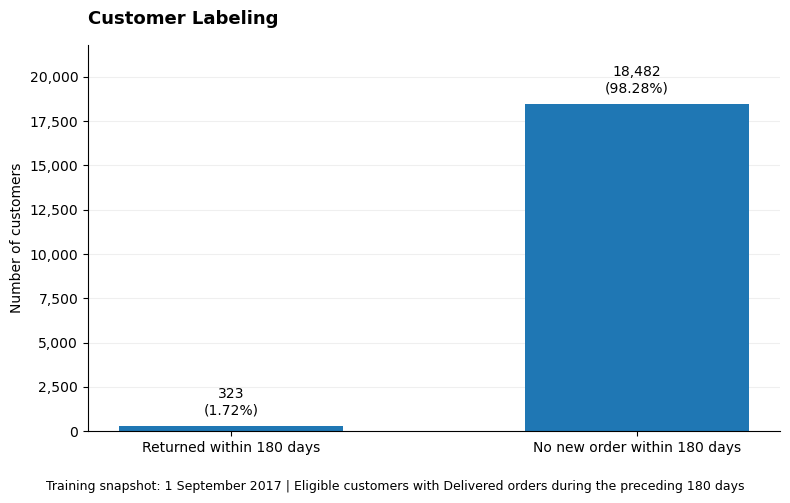

In [81]:
target_counts = (
    train_snapshot[target_column]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

target_percentages = (
    target_counts / target_counts.sum() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [
        "Returned within 180 days",
        "No new order within 180 days"
    ],
    target_counts.values,
    width=0.55
)

for bar, count, percentage in zip(
    bars,
    target_counts.values,
    target_percentages.values
):
    ax.annotate(
        f"{count:,}\n({percentage:.2f}%)",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

ax.set_title(
    "Customer Labeling",
    loc="left",
    fontsize=13,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Number of customers")

ax.set_ylim(
    0,
    target_counts.max() * 1.18
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.01,
    "Training snapshot: 1 September 2017 | "
    "Eligible customers with Delivered orders during the preceding 180 days",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

### Target Distribution Findings

Training snapshot memiliki class imbalance yang sangat tinggi:

- 323 customers (1.72%) melakukan minimal satu recorded Delivered order dalam 180-day future prediction window dan dikategorikan sebagai Returned / Not Churn (0).
- 18,482 customers (98.28%) tidak memiliki recorded Delivered order baru dalam 180-day future prediction window dan dikategorikan sebagai No New Order / Churn Proxy (1).

Pola class imbalance juga terlihat pada validation dan test snapshot, dengan proporsi Returned
masing-masing sekitar 1.49% dan 1.33%. Hal ini menunjukkan bahwa rare return behavior
terjadi secara konsisten pada beberapa periode waktu, meskipun terdapat sedikit penurunan
proporsi Returned pada snapshot yang lebih baru.

Dengan distribusi tersebut, Accuracy tidak cukup sebagai primary evaluation metric karena
model yang hanya memprediksi majority class dapat menghasilkan accuracy yang sangat tinggi
tanpa berhasil mengidentifikasi customer Returned.

Karena customer Returned merupakan minority class sekaligus class of interest, evaluasi model
akan berfokus pada kemampuan model dalam mengidentifikasi customer tersebut menggunakan
**Average Precision (AP)**, disertai Precision, Recall, F1-Score, dan Confusion Matrix.

## EDA After Labelling: RFM Customer Behavior

Setelah target `churn_180d` terbentuk, tahap berikutnya mengeksplorasi karakteristik
historical customer behavior pada training snapshot.

Analisis dimulai dengan tiga feature utama **Recency, Frequency, dan Monetary (RFM)**
untuk memahami distribusi customer behavior sebelum membandingkannya berdasarkan
future churn outcome.

- **Recency** menunjukkan seberapa lama sejak Delivered order terakhir customer sebelum prediction date.
- **Frequency** menunjukkan jumlah Delivered order customer selama 180-day historical observation window.
- **Monetary** menunjukkan total merchandise spending customer selama historical observation window.

Tahap ini membantu memahami karakteristik feature yang nantinya digunakan dalam modelling
serta mengidentifikasi distribusi yang tidak seimbang, skewness, dan potential outliers.

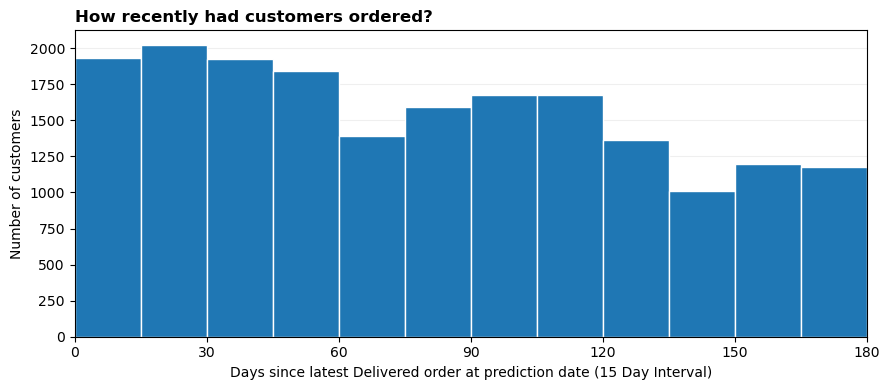

In [82]:
# Recency visualization

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    train_snapshot["recency_days"],
    bins=np.arange(0, 181, 15),
    edgecolor="white"
)

ax.set_title(
    "How recently had customers ordered?",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel(
    "Days since latest Delivered order at prediction date (15 Day Interval)"
)

ax.set_ylabel("Number of customers")
ax.set_xlim(0, 180)
ax.set_xticks(np.arange(0, 181, 30))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

,customer_count,percentage
frequency,,
1,18352,97.59
2,419,2.23
3,31,0.16
4,3,0.02


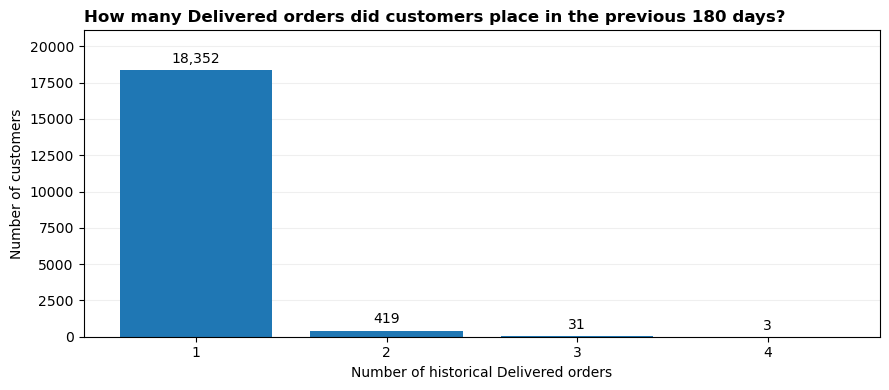

In [83]:
# Frequency visualization

frequency_counts = (
    train_snapshot["frequency"]
    .value_counts()
    .sort_index()
)

frequency_summary = (
    frequency_counts
    .to_frame("customer_count")
)

frequency_summary["percentage"] = (
    frequency_counts
    / len(train_snapshot)
    * 100
).round(2)

display(frequency_summary)

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    frequency_counts.index.astype(str),
    frequency_counts.values
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in frequency_counts.values
    ],
    padding=3
)

ax.set_title(
    "How many Delivered orders did customers place in the previous 180 days?",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Number of historical Delivered orders")
ax.set_ylabel("Number of customers")

ax.set_ylim(
    0,
    frequency_counts.max() * 1.15
)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

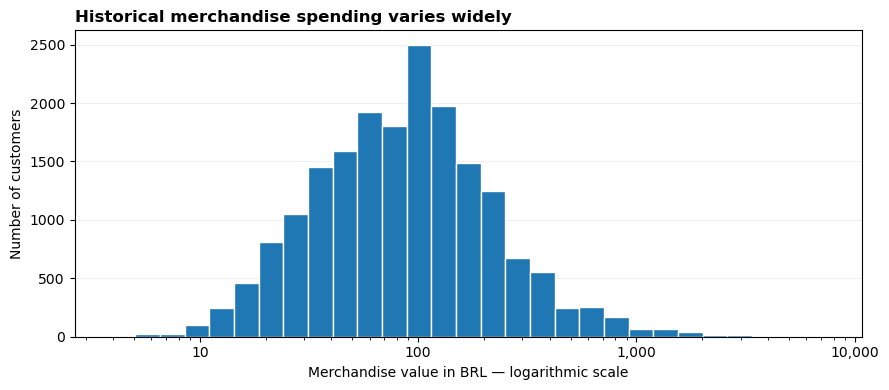

Chart includes 18,805 customers; excludes 0 with incomplete spending.


In [84]:
# Monetary visualization

known_spending = (
    train_snapshot["monetary"]
    .dropna()
)

spending_bins = np.geomspace(
    known_spending.min(),
    known_spending.max(),
    30
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    known_spending,
    bins=spending_bins,
    edgecolor="white"
)

ax.set_xscale("log")

ax.set_xticks(
    [10, 100, 1000, 10000]
)

ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.set_title(
    "Historical merchandise spending varies widely",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel(
    "Merchandise value in BRL — logarithmic scale"
)

ax.set_ylabel("Number of customers")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(
    f"Chart includes {len(known_spending):,} customers; "
    f"excludes {train_snapshot['monetary'].isna().sum():,} "
    "with incomplete spending."
)

### RFM Distribution Findings

**Recency**

Aktivitas customer tersebar di sepanjang 180-day historical observation window.
Distribusi menunjukkan bahwa customer memiliki tingkat recency yang cukup bervariasi,
sehingga `recency_days` dapat membantu membedakan customer berdasarkan seberapa dekat
aktivitas terakhirnya terhadap prediction date.

**Frequency**

Historical purchase frequency sangat terkonsentrasi pada satu Delivered order.
Sebagian besar customer hanya memiliki satu completed purchase selama historical observation
window, sementara customer dengan lebih dari satu Delivered order relatif sedikit.

Hal ini menunjukkan bahwa repeat purchasing merupakan behavior yang jarang pada training
population dan menyebabkan `frequency` memiliki variasi yang terbatas.

**Monetary**

Historical merchandise spending memiliki distribusi **right-skewed**, dengan sebagian kecil
customer memiliki spending yang jauh lebih tinggi dibanding mayoritas customer.

Visualisasi menggunakan logarithmic scale agar variasi Monetary lebih mudah diamati.
Tidak terdapat missing monetary value pada training snapshot setelah modelling population
dibatasi hanya pada Delivered orders.

### Initial RFM Takeaway

Secara keseluruhan, training population didominasi oleh customer dengan single historical
Delivered order, sementara Recency dan Monetary memiliki variasi yang lebih besar.

Namun, distribusi ini masih menggambarkan seluruh eligible customer secara keseluruhan.
Untuk menjawab business problem churn prediction, analisis berikutnya perlu membandingkan
RFM behavior antara customer **Returned (`churn_180d = 0`)** dan
**Churn / No New Order (`churn_180d = 1`)**.

## RFM Comparison by Churn Outcome

Setelah memahami distribusi RFM secara keseluruhan, tahap berikutnya membandingkan
historical behavior antara customer:

- **Returned / Not Churn (`churn_180d = 0`)**
- **No New Order / Churn (`churn_180d = 1`)**

Perbandingan dilakukan untuk melihat feature mana yang menunjukkan perbedaan paling jelas
terhadap future customer return behavior dalam 180-day prediction window.

In [85]:
group_summary = (
    train_snapshot
    .groupby("churn_180d")
    .agg(
        customers=("customer_unique_id", "size"),
        median_recency_days=("recency_days", "median"),
        mean_frequency=("frequency", "mean"),
        median_monetary=("monetary", "median"),
        customers_with_known_monetary=("monetary", "count")
    )
    .rename(index={
        0: "Returned within 180 days",
        1: "No new order within 180 days"
    })
)

group_summary.round(2).T

churn_180d,Returned within 180 days,No new order within 180 days
customers,323.00,18482.00
median_recency_days,64.24,78.37
mean_frequency,1.10,1.02
median_monetary,90.00,85.90
customers_with_known_monetary,323.00,18482.00


### RFM Comparison Findings

Customer yang kembali melakukan order dalam 180 hari memiliki median Recency yang lebih
rendah, yaitu sekitar **64.24 hari**, dibandingkan **78.37 hari** pada customer yang tidak
kembali melakukan order.

Hal ini menunjukkan bahwa customer Returned cenderung memiliki aktivitas pembelian yang
lebih recent sebelum prediction date.

Perbedaan pada Frequency juga terlihat meskipun secara absolut relatif kecil:

- Mean Frequency: **1.10 orders** pada Returned vs **1.02 orders** pada No New Order.
- **7.74%** customer Returned memiliki lebih dari satu historical Delivered order,
  dibandingkan hanya **2.32%** pada customer No New Order.

Median Monetary relatif mirip, yaitu **BRL 90.00** pada Returned dan **BRL 85.90** pada
No New Order.

Secara awal, **Recency dan repeat purchase behavior pada Frequency menunjukkan perbedaan
yang lebih terlihat terhadap future return behavior**, sedangkan Monetary secara individual
menunjukkan separation yang lebih terbatas.

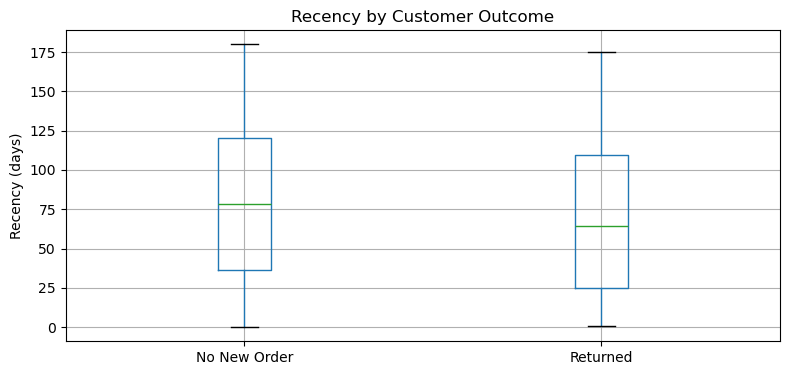

In [86]:
label_map = {
    0: "Returned",
    1: "No New Order"
}

plot_data = train_snapshot.copy()
plot_data["customer_outcome"] = (
    plot_data["churn_180d"]
    .map(label_map)
)

fig, ax = plt.subplots(figsize=(8, 4))

plot_data.boxplot(
    column="recency_days",
    by="customer_outcome",
    ax=ax
)

ax.set_title("Recency by Customer Outcome")
ax.set_xlabel("")
ax.set_ylabel("Recency (days)")

plt.suptitle("")
plt.tight_layout()
plt.show()

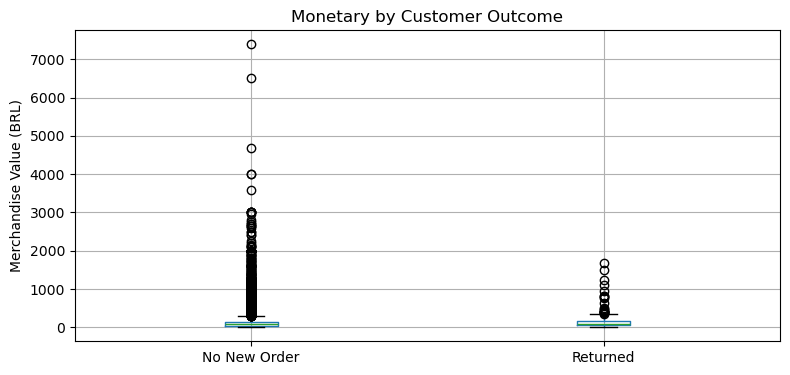

In [87]:
fig, ax = plt.subplots(figsize=(8, 4))

plot_data.boxplot(
    column="monetary",
    by="customer_outcome",
    ax=ax
)

ax.set_title("Monetary by Customer Outcome")
ax.set_xlabel("")
ax.set_ylabel("Merchandise Value (BRL)")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [88]:
frequency_by_outcome = (
    train_snapshot
    .groupby("churn_180d")["frequency"]
    .agg(["count", "mean", "median", "max"])
    .rename(index={
        0: "Returned within 180 days",
        1: "No new order within 180 days"
    })
)

frequency_by_outcome.round(2)

,count,mean,median,max
churn_180d,,,,
Returned within 180 days,323,1.10,1.0,4
No new order within 180 days,18482,1.02,1.0,4


In [89]:
frequency_share = (
    pd.crosstab(
        train_snapshot["frequency"],
        train_snapshot["churn_180d"],
        normalize="columns"
    )
    * 100
)

frequency_share.columns = [
    "Returned",
    "No New Order"
]

frequency_share.round(2)

,Returned,No New Order
frequency,,
1,92.26,97.68
2,5.88,2.16
3,1.55,0.14
4,0.31,0.01


### Distribution Comparison

Distribusi Recency customer Returned cenderung bergeser ke nilai yang lebih rendah dibandingkan
customer No New Order. Median Recency Returned berada pada 64.24 hari, sedangkan
No New Order berada pada 78.37 hari.

Namun, kedua distribusi masih memiliki overlap yang cukup besar. Artinya, Recency menunjukkan
signal terhadap future return behavior, tetapi tidak cukup digunakan sebagai indikator tunggal.

Pada Monetary, distribusi kedua kelompok sangat overlap dan median relatif mirip
(BRL 90.00 vs BRL 85.90). Selain itu, terdapat sejumlah high-value outliers, terutama pada
kelompok No New Order.

Hal ini menunjukkan bahwa Monetary secara individual memberikan separation yang terbatas
antara customer Returned dan No New Order.

Frequency juga memiliki distribusi yang sangat terkonsentrasi pada satu order. Namun,
customer Returned memiliki proporsi repeat historical purchase yang lebih tinggi dibandingkan
customer No New Order, sehingga Frequency tetap memiliki potential signal meskipun variasinya
terbatas.

### RFM Business Interpretation

Hasil RFM comparison menunjukkan bahwa historical customer behavior memiliki beberapa
signal terhadap future return:

- **Recency:** customer Returned cenderung memiliki transaksi terakhir yang lebih dekat
  dengan prediction date.
- **Frequency:** sebagian besar customer hanya memiliki satu historical order, tetapi repeat
  historical purchase lebih sering ditemukan pada customer Returned.
- **Monetary:** historical spending antara kedua kelompok relatif mirip sehingga Monetary
  secara individual memiliki separation yang lebih terbatas.

Temuan ini menunjukkan bahwa tidak ada satu RFM feature yang dapat memisahkan customer
Returned dan Churn secara sempurna.

Oleh karena itu, modelling diperlukan untuk mengevaluasi kombinasi beberapa behavioral
features secara bersamaan.

In [90]:
# Flagging label based on order frequency

frequency_analysis = train_snapshot[
    ["frequency", "churn_180d"]
].copy()

frequency_analysis["historical_order_group"] = np.where(
    frequency_analysis["frequency"].eq(1),
    "1 order",
    "2+ orders"
)

frequency_analysis["returned_180d"] = (
    frequency_analysis["churn_180d"].eq(0).astype(int)
)

frequency_return_summary = (
    frequency_analysis
    .groupby("historical_order_group")
    .agg(
        customers=("returned_180d", "size"),
        returning_customers=("returned_180d", "sum")
    )
    .reindex(["1 order", "2+ orders"])
)

frequency_return_summary["return_rate_percent"] = (
    frequency_return_summary["returning_customers"]
    / frequency_return_summary["customers"]
    * 100
)

frequency_return_summary.round(2)

,customers,returning_customers,return_rate_percent
historical_order_group,,,
1 order,18352,298,1.62
2+ orders,453,25,5.52


### Historical Frequency and Return Rate

Customer dengan **2 atau lebih historical Delivered orders** memiliki return rate sebesar
**5.52%**, dibandingkan **1.62%** pada customer yang hanya memiliki satu historical
Delivered order.

Dengan kata lain, return rate pada customer dengan repeat purchase history sekitar
**3.4 kali** lebih tinggi dibandingkan customer dengan satu historical order.

Meskipun customer dengan 2+ historical orders hanya mencakup sebagian kecil dari training
population (453 dari 18,805 customers), hasil ini menunjukkan bahwa historical repeat purchase
behavior memiliki hubungan yang cukup terlihat dengan future customer return.

Temuan ini mendukung penggunaan `frequency` sebagai salah satu behavioral feature dalam
churn modelling, meskipun distribusinya sangat terkonsentrasi pada satu order.

## RFM Exploration — Key Findings

Berdasarkan EDA RFM pada 18,805 eligible customers:

1. **Customer return tetap sangat jarang**  
   Sebanyak 323 customers (1.72%) kembali melakukan minimal satu Delivered order dalam
   180 hari setelah prediction date.

2. **Recency menunjukkan perbedaan yang paling terlihat**  
   Median Recency customer Returned adalah 64.24 hari, lebih rendah dibandingkan
   78.37 hari pada customer No New Order.

3. **Historical Frequency memiliki variasi terbatas**  
   Sebagian besar customer hanya memiliki satu Delivered order selama 180-day historical
   observation window. Namun, customer Returned memiliki proporsi multi-order history yang
   lebih tinggi dibandingkan customer No New Order.

4. **Monetary menunjukkan separation yang terbatas**  
   Median Monetary customer Returned adalah BRL 90.00, dibandingkan BRL 85.90 pada
   customer No New Order. Distribusi kedua kelompok tetap sangat overlap dan m|emiliki
   right-skewed distribution.

5. **Tidak terdapat missing RFM values pada modelling dataset**  
   Setelah modelling population dibatasi hanya pada Delivered orders, seluruh eligible
   customers memiliki nilai Recency, Frequency, dan Monetary yang lengkap.

Secara keseluruhan, Recency dan historical repeat purchase behavior menunjukkan signal yang
lebih terlihat terhadap future return behavior, sedangkan Monetary secara individual memiliki
separation yang lebih terbatas.

Namun, tidak ada satu RFM feature yang mampu memisahkan Returned dan No New Order secara
sempurna. Oleh karena itu, tahap modelling diperlukan untuk mengevaluasi kombinasi beberapa
historical customer behaviors secara bersamaan.

## Additional EDA — Recency Bucket vs Return Rate

Analisis ini bertujuan untuk melihat apakah customer yang lebih recently active memiliki
return rate yang berbeda dibandingkan customer yang sudah lebih lama tidak bertransaksi.

`recency_days` dibagi menjadi beberapa interval 30 hari, kemudian dihitung:

- jumlah customer pada setiap recency bucket,
- jumlah customer yang kembali melakukan minimal satu Delivered order dalam 180 hari,
- dan return rate pada masing-masing bucket.

Analisis ini menggunakan `train_snapshot` dan hanya digunakan untuk exploratory analysis.
Tidak ada perubahan pada feature, label, maupun dataset yang digunakan untuk modelling.

In [91]:
eda_recency = train_snapshot[
    [
        "customer_unique_id",
        "recency_days",
        "churn_180d"
    ]
].copy()

eda_recency["recency_bucket"] = pd.cut(
    eda_recency["recency_days"],
    bins=[0, 30, 60, 90, 120, 150, 180],
    labels=[
        "0-30 days",
        "31-60 days",
        "61-90 days",
        "91-120 days",
        "121-150 days",
        "151-180 days"
    ],
    include_lowest=True
)

eda_recency["returned_180d"] = (
    eda_recency["churn_180d"]
    .eq(0)
    .astype(int)
)

recency_return_summary = (
    eda_recency
    .groupby(
        "recency_bucket",
        observed=False
    )
    .agg(
        customers=("customer_unique_id", "size"),
        returning_customers=("returned_180d", "sum")
    )
)

recency_return_summary["return_rate_percent"] = (
    recency_return_summary["returning_customers"]
    / recency_return_summary["customers"]
    * 100
)

recency_return_summary.round(2)

,customers,returning_customers,return_rate_percent
recency_bucket,,,
0-30 days,3955,99,2.50
31-60 days,3762,57,1.52
61-90 days,2988,50,1.67
91-120 days,3348,50,1.49
121-150 days,2379,36,1.51
151-180 days,2373,31,1.31


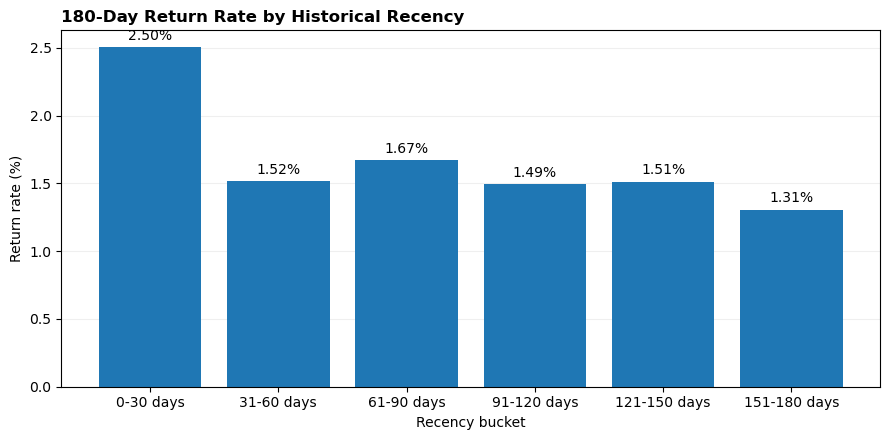

In [92]:
fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(
    recency_return_summary.index.astype(str),
    recency_return_summary["return_rate_percent"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in recency_return_summary["return_rate_percent"]
    ],
    padding=3
)

ax.set_title(
    "180-Day Return Rate by Historical Recency",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Recency bucket")
ax.set_ylabel("Return rate (%)")

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Recency Bucket Findings

Customer dengan aktivitas paling recent menunjukkan return rate yang lebih tinggi dibandingkan
kelompok lainnya.

Customer pada bucket **0–30 days** memiliki return rate tertinggi sebesar **2.50%**.
Sementara itu, return rate pada bucket lainnya berada pada kisaran sekitar **1.31%–1.67%**.

Pola antar bucket tidak menurun secara sempurna seiring meningkatnya Recency. Namun,
kelompok customer yang baru melakukan transaksi dalam 30 hari terakhir menunjukkan return
rate yang cukup lebih tinggi dibandingkan customer yang aktivitas terakhirnya lebih lama.

Temuan ini konsisten dengan hasil RFM sebelumnya, di mana customer Returned memiliki median
Recency yang lebih rendah dibandingkan customer No New Order.

Dengan demikian, Recency menunjukkan potential predictive signal terhadap future return
behavior, tetapi tidak sebaiknya digunakan sebagai indikator tunggal karena terdapat overlap
yang cukup besar antar kelompok.

### Business Implication

Dari basic RFM, Recency dan historical repeat-order behavior menunjukkan signal yang lebih
terlihat terhadap customer return dibandingkan Monetary.

Customer yang melakukan transaksi dalam 30 hari terakhir memiliki return rate tertinggi,
sementara customer dengan 2+ historical orders juga memiliki return rate yang lebih tinggi
dibandingkan customer dengan satu historical order.

Temuan ini menunjukkan bahwa recent activity dan repeat purchase history dapat menjadi
indikator historical customer engagement yang lebih kuat.

Namun, seluruh return rate tetap relatif rendah dan tidak ada satu behavioral feature yang
secara individual memberikan separation yang kuat. Oleh karena itu, model prediction tetap
dibutuhkan untuk menggabungkan beberapa customer signals secara bersamaan.

## Additional EDA — Purchase Depth & Product Diversity

Analisis berikut mengeksplorasi apakah customer dengan historical purchase yang lebih dalam
dan lebih beragam memiliki return behavior yang berbeda.

Dua aspek yang dianalisis:

- **Purchase Depth:** jumlah item yang dibeli customer selama historical observation window.
- **Product Diversity:** jumlah unique product yang pernah dibeli customer selama historical
  observation window.

Analisis hanya menggunakan historical Delivered orders sebelum prediction date dan target
`churn_180d` yang sudah terbentuk.

Karena modelling population hanya menggunakan Delivered orders dan seluruh eligible
transactions memiliki matching item information, coverage `total_items` dan `unique_products`
pada training snapshot telah terkonfirmasi lengkap.

In [93]:
# Additional EDA: Purchase Depth & Product Diversity

eda_product_depth = train_snapshot[
    [
        "customer_unique_id",
        "churn_180d",
        "total_items",
        "unique_products"
    ]
].copy()

eda_product_depth["returned_180d"] = (
    eda_product_depth["churn_180d"]
    .eq(0)
    .astype(int)
)

print(
    "Customers analysed:",
    f"{len(eda_product_depth):,}"
)

print(
    "Missing total_items:",
    eda_product_depth["total_items"].isna().sum()
)

print(
    "Missing unique_products:",
    eda_product_depth["unique_products"].isna().sum()
)

Customers analysed: 18,805
Missing total_items: 0
Missing unique_products: 0


In [94]:
eda_product_diversity = eda_product_depth.copy()

eda_product_diversity["product_diversity_group"] = np.where(
    eda_product_diversity["unique_products"].eq(1),
    "1 product",
    "2+ products"
)

product_diversity_summary = (
    eda_product_diversity
    .groupby("product_diversity_group")
    .agg(
        customers=("customer_unique_id", "size"),
        returning_customers=("returned_180d", "sum"),
        median_unique_products=("unique_products", "median")
    )
    .reindex(["1 product", "2+ products"])
)

product_diversity_summary["return_rate_percent"] = (
    product_diversity_summary["returning_customers"]
    / product_diversity_summary["customers"]
    * 100
)

product_diversity_summary.round(2)

,customers,returning_customers,median_unique_products,return_rate_percent
product_diversity_group,,,,
1 product,17827,295,1.0,1.65
2+ products,978,28,2.0,2.86


### Product Diversity vs Return Rate

Customer dengan **2+ unique historical products** memiliki return rate sebesar **2.86%**,
dibandingkan **1.65%** pada customer dengan satu unique product.

Dengan demikian, return rate customer dengan multiple historical products sekitar
**1.73 kali lebih tinggi** dibandingkan customer dengan satu historical product.

Meskipun mayoritas customer hanya memiliki satu unique historical product, hasil ini
menunjukkan bahwa Product Diversity memiliki potential signal terhadap future customer return.
Namun, feature ini tetap tidak digunakan sebagai indikator tunggal dalam menentukan churn.

### Additional EDA — Purchase Depth vs Return Rate

Analisis ini mengeksplorasi hubungan antara jumlah item yang dibeli customer selama historical
observation window dan future customer return.

`total_items` dihitung dari Order Items yang terhubung dengan historical Delivered orders.

Untuk menjaga interpretasi tetap sederhana, customer dikelompokkan menjadi:

- **1 item**
- **2+ items**

Analisis ini hanya digunakan untuk exploratory analysis dan tidak mengubah feature maupun
dataset yang digunakan pada modelling.

In [95]:
eda_purchase_depth = eda_product_depth.copy()

eda_purchase_depth["item_depth_group"] = np.where(
    eda_purchase_depth["total_items"].eq(1),
    "1 item",
    "2+ items"
)

item_depth_summary = (
    eda_purchase_depth
    .groupby("item_depth_group")
    .agg(
        customers=("customer_unique_id", "size"),
        returning_customers=("returned_180d", "sum"),
        median_items=("total_items", "median")
    )
    .reindex(["1 item", "2+ items"])
)

item_depth_summary["return_rate_percent"] = (
    item_depth_summary["returning_customers"]
    / item_depth_summary["customers"]
    * 100
)

item_depth_summary.round(2)

,customers,returning_customers,median_items,return_rate_percent
item_depth_group,,,,
1 item,16595,269,1.0,1.62
2+ items,2210,54,2.0,2.44


### Purchase Depth & Product Diversity Findings

Historical Product Diversity dan Purchase Depth menunjukkan perbedaan pada future customer
return behavior.

**Product Diversity**

Customer dengan **2+ unique historical products** memiliki return rate sebesar **2.86%**,
dibandingkan **1.65%** pada customer dengan satu unique product. Dengan demikian, return
rate kelompok dengan multiple historical products sekitar **1.73 kali** lebih tinggi.

**Purchase Depth**

Customer dengan **2+ historical items** memiliki return rate sebesar **2.44%**, dibandingkan
**1.62%** pada customer dengan satu historical item. Return rate kelompok dengan higher
purchase depth sekitar **1.51 kali** lebih tinggi.

Hasil ini menunjukkan bahwa customer dengan historical purchase yang lebih beragam dan
lebih dalam memiliki return rate yang lebih tinggi. Namun, perbedaannya tetap relatif terbatas
dan kedua behavioral signals tidak sebaiknya digunakan secara individual untuk menentukan
future churn outcome.

### Business Implication

Selain Recency dan Frequency, Product Diversity dan Purchase Depth juga menunjukkan
additional behavioral signal terhadap future customer return.

Customer dengan multiple historical products dan customer dengan 2+ historical items
menunjukkan return rate yang lebih tinggi dibandingkan kelompok pembandingnya.

Hal ini menunjukkan bahwa historical customer engagement tidak hanya dapat dilihat dari
seberapa recent dan seberapa sering customer melakukan order, tetapi juga dari seberapa luas
dan dalam historical purchase behavior mereka.

Namun, karena return rate secara keseluruhan tetap rendah dan tidak ada satu feature yang
memberikan separation kuat secara individual, predictive modelling tetap diperlukan untuk
mengevaluasi kombinasi beberapa behavioral signals secara bersamaan.

## Additional EDA — Behavioral Signal Summary

Analisis tambahan menunjukkan bahwa beberapa historical customer behaviors memiliki
hubungan dengan kemungkinan customer kembali melakukan order dalam 180 hari.

Summary berikut membandingkan return rate dari beberapa behavioral segments yang telah
dianalisis.

Analisis ini bersifat descriptive dan digunakan untuk memahami potential retention signals,
bukan untuk menyimpulkan hubungan sebab-akibat.

In [96]:
behavioral_signal_summary = pd.DataFrame({
    "behavior": [
        "Recent purchase",
        "Repeat order",
        "Product diversity",
        "Purchase depth"
    ],
    "higher_engagement_group": [
        "Recency 0-30 days",
        "2+ historical orders",
        "2+ products",
        "2+ items"
    ],
    "comparison_group": [
        "Recency 151-180 days",
        "1 historical order",
        "1 product",
        "1 item"
    ],
    "higher_group_return_rate": [
        2.50,
        5.52,
        2.86,
        2.44
    ],
    "comparison_return_rate": [
        1.31,
        1.62,
        1.65,
        1.62
    ]
})

behavioral_signal_summary["relative_return_rate"] = (
    behavioral_signal_summary["higher_group_return_rate"]
    / behavioral_signal_summary["comparison_return_rate"]
)

behavioral_signal_summary.round(2)

,behavior,higher_engagement_group,comparison_group,higher_group_return_rate,comparison_return_rate,relative_return_rate
0,Recent purchase,Recency 0-30 days,Recency 151-180 days,2.50,1.31,1.91
1,Repeat order,2+ historical orders,1 historical order,5.52,1.62,3.41
2,Product diversity,2+ products,1 product,2.86,1.65,1.73
3,Purchase depth,2+ items,1 item,2.44,1.62,1.51


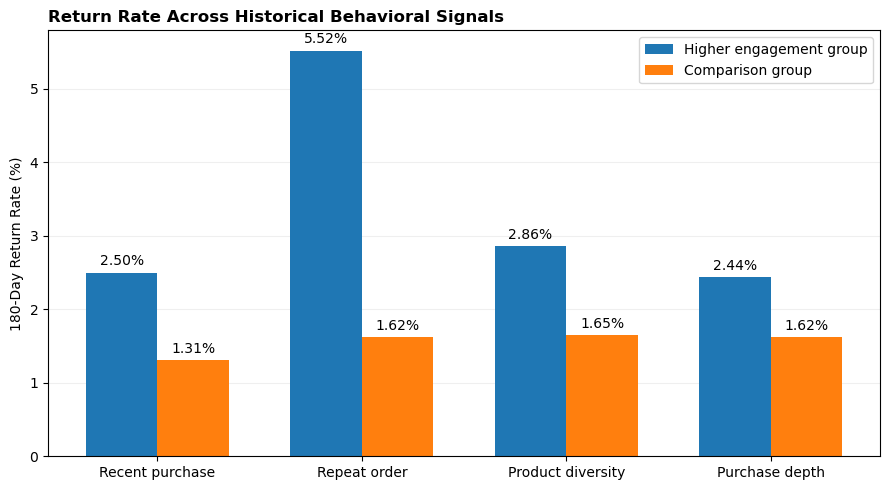

In [97]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(
    len(behavioral_signal_summary)
)

width = 0.35

higher_bars = ax.bar(
    x - width / 2,
    behavioral_signal_summary["higher_group_return_rate"],
    width,
    label="Higher engagement group"
)

comparison_bars = ax.bar(
    x + width / 2,
    behavioral_signal_summary["comparison_return_rate"],
    width,
    label="Comparison group"
)

ax.bar_label(
    higher_bars,
    fmt="%.2f%%",
    padding=3
)

ax.bar_label(
    comparison_bars,
    fmt="%.2f%%",
    padding=3
)

ax.set_xticks(x)

ax.set_xticklabels(
    behavioral_signal_summary["behavior"]
)

ax.set_ylabel("180-Day Return Rate (%)")

ax.set_title(
    "Return Rate Across Historical Behavioral Signals",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.2
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Behavioral Signal Findings

Seluruh higher-engagement groups menunjukkan return rate yang lebih tinggi dibandingkan
comparison group masing-masing.

- **Repeat Order** menunjukkan perbedaan relatif paling besar. Customer dengan 2+ historical
  Delivered orders memiliki return rate **5.52%**, dibandingkan **1.62%** pada customer
  dengan satu historical order, atau sekitar **3.41 kali lebih tinggi**.

- **Recent Purchase** juga menunjukkan perbedaan. Customer dengan Recency 0–30 hari
  memiliki return rate **2.50%**, dibandingkan **1.31%** pada customer dengan Recency
  151–180 hari.

- **Product Diversity** menunjukkan return rate **2.86% vs 1.65%** untuk customer dengan
  2+ products dibandingkan satu product.

- **Purchase Depth** menunjukkan return rate **2.44% vs 1.62%** untuk customer dengan
  2+ items dibandingkan satu item.

Secara keseluruhan, customer dengan historical engagement yang lebih kuat cenderung
menunjukkan return rate yang lebih tinggi.

Namun, seluruh return rate tetap rendah dan masing-masing behavioral signal tidak sebaiknya
digunakan secara individual untuk menentukan churn.

### Business Implication

Temuan ini menunjukkan bahwa retention prioritization dapat mempertimbangkan kombinasi
Recency, repeat-order behavior, Product Diversity, dan Purchase Depth untuk membedakan
tingkat historical customer engagement.

Secara descriptive, repeat-order behavior menunjukkan perbedaan return rate yang paling
besar di antara behavioral segments yang dianalisis, sementara Recency, Product Diversity,
dan Purchase Depth memberikan additional signals.

Insight ini dapat digunakan sebagai dasar exploratory customer segmentation, sementara
predictive modelling tetap diperlukan untuk menggabungkan berbagai customer signals secara
lebih sistematis.

## Additional EDA — Correlation Analysis

Correlation analysis dilakukan untuk melihat hubungan linear antar numerical customer features
serta hubungannya dengan target `churn_180d`.

Analisis ini bertujuan untuk:

- melihat feature yang memiliki hubungan dengan future churn outcome,
- mengidentifikasi feature yang membawa informasi serupa,
- dan memberikan konteks untuk feature selection dan modelling.

Correlation tidak digunakan untuk menyimpulkan hubungan sebab-akibat.

In [98]:
correlation_features = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products",
    "churn_180d"
]

eda_correlation = train_snapshot[
    ["customer_unique_id"] + correlation_features
].copy()

correlation_matrix = (
    eda_correlation[correlation_features]
    .corr()
)

display(
    correlation_matrix.round(2)
)

,recency_days,frequency,monetary,total_items,unique_products,churn_180d
recency_days,1.00,-0.04,0.02,-0.03,-0.03,0.03
frequency,-0.04,1.00,0.08,0.38,0.58,-0.06
monetary,0.02,0.08,1.00,0.14,0.08,-0.00
total_items,-0.03,0.38,0.14,1.00,0.57,-0.03
unique_products,-0.03,0.58,0.08,0.57,1.00,-0.03
churn_180d,0.03,-0.06,-0.00,-0.03,-0.03,1.00


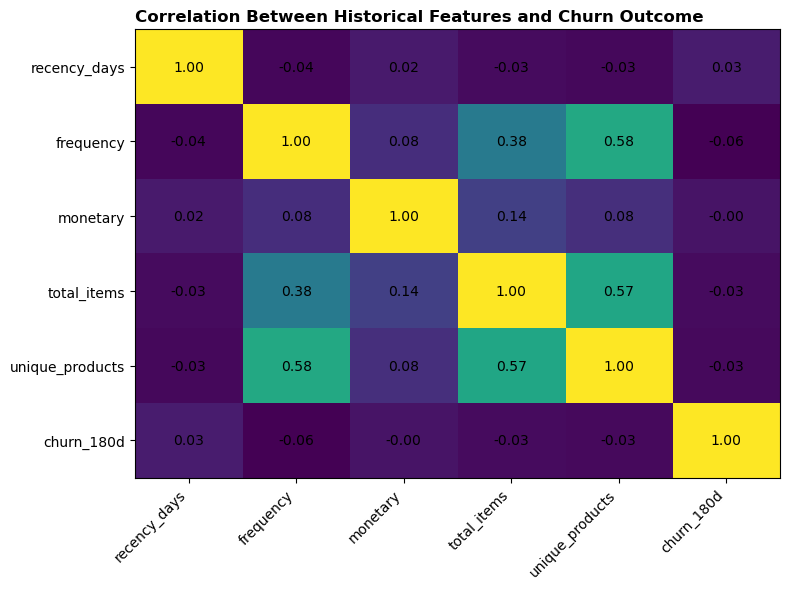

In [99]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Correlation Between Historical Features and Churn Outcome",
    loc="left",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Correlation Analysis — Findings

Correlation matrix menunjukkan bahwa tidak terdapat satu historical feature yang memiliki
hubungan linear kuat dengan target `churn_180d`.

- `frequency` memiliki correlation negatif kecil terhadap `churn_180d` sebesar **-0.06**.
  Karena `churn_180d = 0` merepresentasikan Returned, arah ini konsisten dengan temuan
  sebelumnya bahwa customer dengan lebih banyak historical orders cenderung memiliki return
  behavior yang lebih kuat.
- `recency_days` memiliki correlation positif kecil sebesar **0.03**, yang menunjukkan bahwa
  customer dengan Recency lebih tinggi sedikit lebih terkait dengan class Churn / No New Order.
- `total_items` dan `unique_products` masing-masing memiliki correlation sebesar **-0.03**
  terhadap `churn_180d`, sehingga hubungannya terhadap target tetap lemah secara linear.
- `monetary` hampir tidak memiliki hubungan linear dengan target, dengan correlation sekitar
  **0.00**.

Di antara historical features, hubungan yang paling terlihat terdapat antara
`frequency` dan `unique_products` (**0.58**), serta `total_items` dan `unique_products`
(**0.57**). Hal ini menunjukkan adanya sebagian overlap informasi antara repeat purchase,
purchase depth, dan product diversity.

Secara keseluruhan, tidak ada satu numerical feature yang secara individual memberikan
separation kuat terhadap churn outcome. Oleh karena itu, modelling diperlukan untuk
mengevaluasi apakah kombinasi beberapa historical customer behaviors dapat menghasilkan
predictive signal yang lebih baik.

## Additional EDA — Distribution & Skewness

Distribution analysis dilakukan untuk memahami bentuk numerical features yang digunakan
dalam churn analysis.

Tujuannya adalah untuk:

- melihat apakah distribusi feature relatif simetris atau skewed,
- mengidentifikasi potential outliers,
- dan memberikan dasar untuk menentukan kebutuhan preprocessing pada tahap modelling.

Analisis ini tidak digunakan untuk menghapus data secara langsung.

In [100]:
distribution_features = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products"
]

distribution_summary = pd.DataFrame({
    "mean": eda_correlation[distribution_features].mean(),
    "median": eda_correlation[distribution_features].median(),
    "std": eda_correlation[distribution_features].std(),
    "skewness": eda_correlation[distribution_features].skew(),
    "min": eda_correlation[distribution_features].min(),
    "max": eda_correlation[distribution_features].max()
})

distribution_summary.round(2)

,mean,median,std,skewness,min,max
recency_days,80.48,78.21,51.08,0.22,0.02,179.82
frequency,1.03,1.00,0.17,7.34,1.00,4.00
monetary,138.43,85.99,216.63,9.02,3.90,7388.00
total_items,1.16,1.00,0.55,8.41,1.00,21.00
unique_products,1.06,1.00,0.29,6.10,1.00,7.00


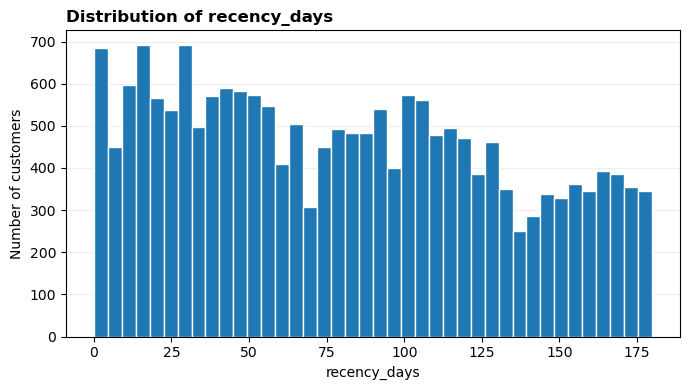

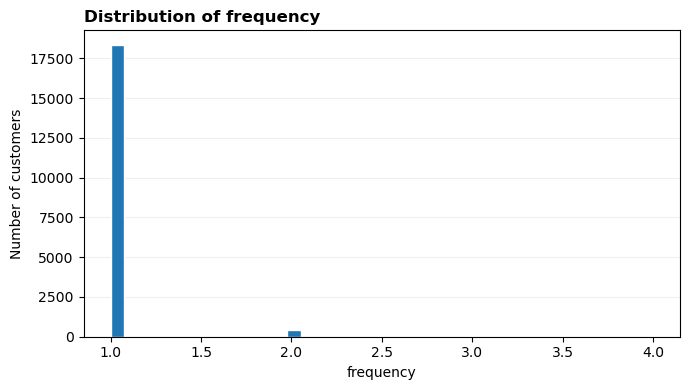

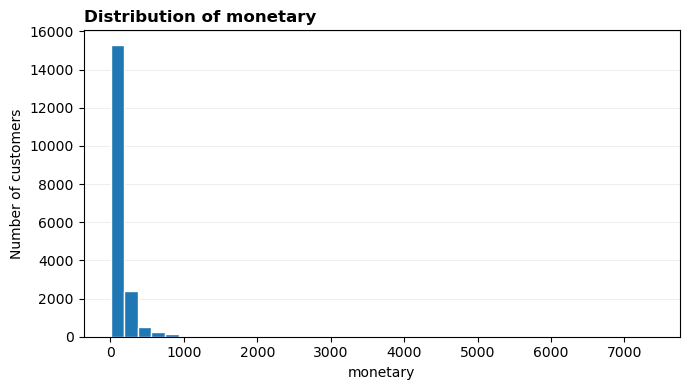

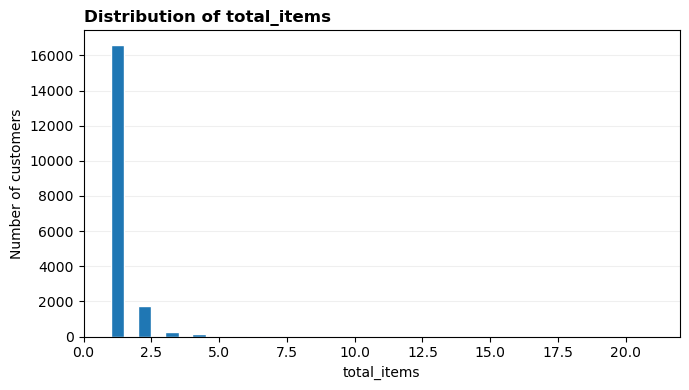

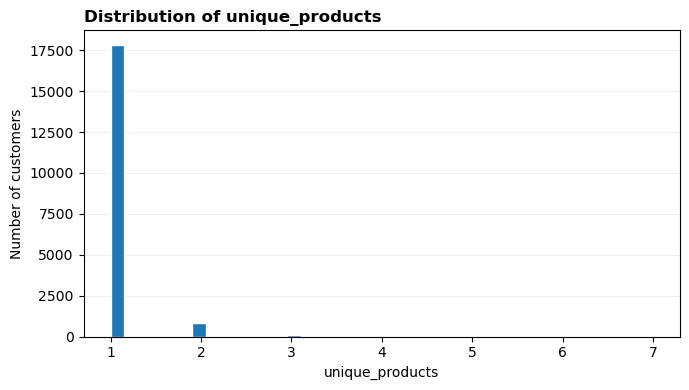

In [101]:
for col in distribution_features:

    data = eda_correlation[col].dropna()

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        data,
        bins=40,
        edgecolor="white"
    )

    ax.set_title(
        f"Distribution of {col}",
        loc="left",
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Number of customers")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

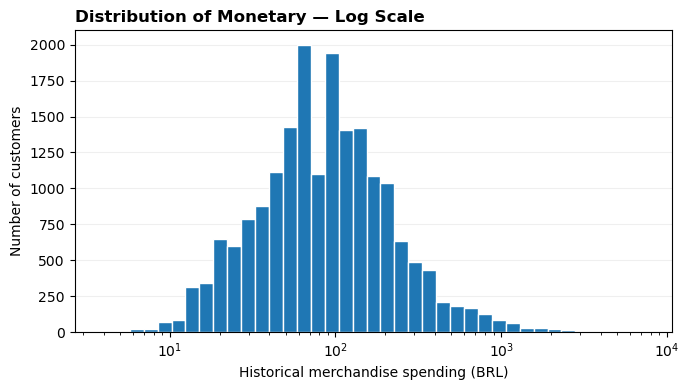

In [102]:
monetary_data = eda_correlation["monetary"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    monetary_data,
    bins=np.geomspace(
        monetary_data.min(),
        monetary_data.max(),
        40
    ),
    edgecolor="white"
)

ax.set_xscale("log")

ax.set_title(
    "Distribution of Monetary — Log Scale",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Historical merchandise spending (BRL)")
ax.set_ylabel("Number of customers")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Distribution & Skewness — Findings

Distribusi numerical features menunjukkan karakteristik yang berbeda:

- **Recency** relatif lebih seimbang dengan skewness **0.22**, sehingga distribusinya tidak
  menunjukkan skewness yang kuat.
- **Frequency** sangat right-skewed dengan skewness **7.34**. Mayoritas customer hanya
  memiliki satu historical Delivered order, sementara customer dengan frequency tinggi sangat
  sedikit.
- **Monetary** memiliki skewness sebesar **9.02**, menunjukkan adanya long tail dari sebagian
  kecil customer dengan historical spending yang jauh lebih tinggi.
- **Total Items** memiliki skewness **8.41**, karena sebagian besar customer membeli sedikit
  item sementara sejumlah kecil customer membeli jauh lebih banyak.
- **Unique Products** memiliki skewness **6.10**, menunjukkan bahwa mayoritas customer hanya
  membeli satu unique product.

Secara keseluruhan, sebagian besar historical behavioral features selain Recency memiliki
distribusi yang sangat right-skewed.

Kondisi ini perlu dipertimbangkan pada tahap preprocessing dan pemilihan model. Namun,
extreme values tidak langsung dihapus karena masih dapat merepresentasikan customer
purchasing behavior yang valid.

## Additional EDA — Outlier Check

Boxplot digunakan untuk melihat keberadaan extreme values pada historical behavioral features
yang memiliki distribusi right-skewed.

Potential outliers pada tahap ini hanya diidentifikasi untuk memahami karakteristik data dan
tidak langsung dihapus, karena nilai ekstrem dapat merepresentasikan customer behavior yang
valid.

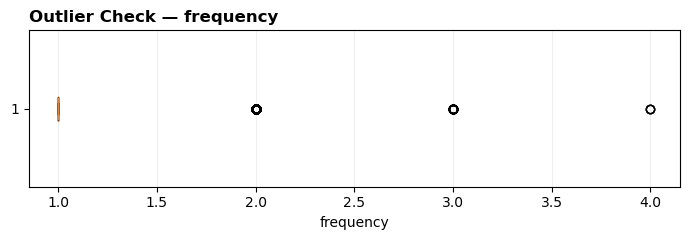

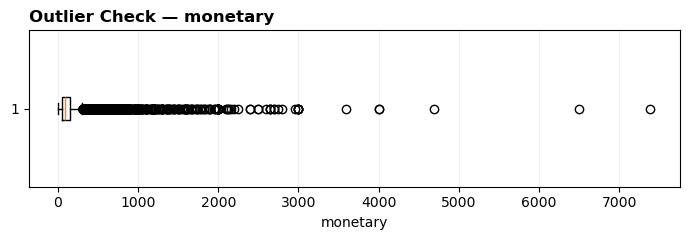

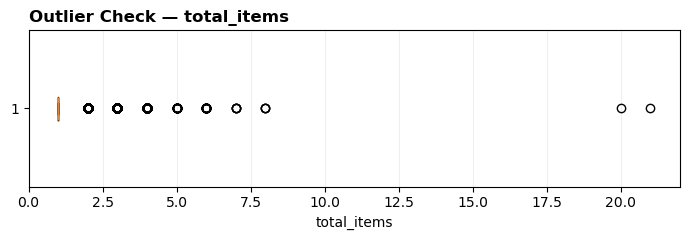

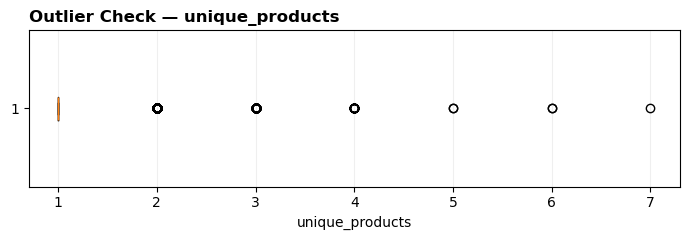

In [103]:
outlier_features = [
    "frequency",
    "monetary",
    "total_items",
    "unique_products"
]

for col in outlier_features:
    data = eda_correlation[col].dropna()

    fig, ax = plt.subplots(figsize=(7, 2.5))

    ax.boxplot(
        data,
        vert=False,
        showfliers=True
    )

    ax.set_title(
        f"Outlier Check — {col}",
        loc="left",
        fontweight="bold"
    )

    ax.set_xlabel(col)

    ax.grid(
        axis="x",
        alpha=0.2
    )

    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

### Outlier Check — Findings

Boxplot menunjukkan adanya sejumlah extreme values pada Frequency, Monetary, Total Items,
dan Unique Products.

- **Frequency:** mayoritas customer hanya memiliki 1 historical Delivered order, sehingga
  customer dengan beberapa historical orders berada pada bagian ekstrem distribusi.
- **Monetary:** memiliki extreme values yang cukup besar, konsisten dengan distribusi
  right-skewed. Beberapa customer memiliki historical spending yang jauh lebih tinggi
  dibandingkan mayoritas customer.
- **Total Items:** mayoritas customer membeli sedikit item, sementara sebagian kecil customer
  memiliki jumlah historical items yang jauh lebih tinggi.
- **Unique Products:** mayoritas customer hanya memiliki satu unique historical product,
  sehingga customer dengan product diversity lebih tinggi berada pada bagian ekstrem distribusi.

Extreme values tidak dihapus karena tidak terdapat indikasi bahwa nilai tersebut merupakan
data error. Nilai tersebut masih dapat merepresentasikan valid historical purchasing behavior.

Temuan ini akan dipertimbangkan pada tahap preprocessing dan modelling, khususnya untuk
feature dengan distribusi yang sangat right-skewed.

Extreme values tetap dipertahankan karena tidak terdapat bukti bahwa nilai tersebut merupakan data-entry error, dan nilai tersebut dapat merepresentasikan customer dengan purchasing behavior yang valid. Dampaknya terhadap model akan ditangani melalui preprocessing dan pemilihan model yang sesuai.

## EDA After Labelling — Key Findings

Berdasarkan historical behavior pada training snapshot, beberapa pola utama ditemukan:

1. **Customer return sangat jarang**  
   Dari 18,805 eligible customers, hanya **323 customers (1.72%)** yang kembali melakukan
   minimal satu Delivered order dalam 180-day future prediction window. Target tetap sangat
   imbalanced.

2. **Recency menunjukkan behavioral signal terhadap future return**  
   Customer dengan Recency 0–30 hari memiliki return rate **2.50%**, dibandingkan
   **1.31%** pada customer dengan Recency 151–180 hari.

3. **Historical repeat-order behavior menunjukkan perbedaan paling besar secara descriptive**  
   Customer dengan 2+ historical Delivered orders memiliki return rate **5.52%**,
   dibandingkan **1.62%** pada customer dengan satu historical order.

4. **Product Diversity memberikan additional signal**  
   Customer dengan 2+ historical products memiliki return rate **2.86%**, dibandingkan
   **1.65%** pada customer dengan satu historical product.

5. **Purchase Depth juga menunjukkan additional signal**  
   Customer dengan 2+ historical items memiliki return rate **2.44%**, dibandingkan
   **1.62%** pada customer dengan satu historical item.

6. **Monetary menunjukkan separation yang terbatas**  
   Median Monetary customer Returned adalah sekitar **BRL 90.00**, dibandingkan
   **BRL 85.90** pada customer No New Order.

7. **Tidak ada satu numerical feature yang memiliki hubungan linear kuat dengan target**  
   Correlation terhadap `churn_180d` relatif kecil untuk seluruh individual features,
   sehingga customer return kemungkinan dipengaruhi oleh kombinasi beberapa historical
   behaviors.

8. **Sebagian besar behavioral features sangat right-skewed**  
   Frequency, Monetary, Total Items, dan Unique Products memiliki distribusi yang sangat
   skewed dan sejumlah extreme values, tetapi nilai tersebut tetap dipertahankan karena
   dapat merepresentasikan purchasing behavior yang valid.

### Business Implication

Hasil EDA menunjukkan bahwa recent activity, repeat-order behavior, Product Diversity,
dan Purchase Depth memberikan signal yang lebih terlihat terhadap future customer return
dibandingkan historical spending saja.

Namun, karena return rate secara keseluruhan tetap rendah dan tidak ada satu feature yang
memberikan separation kuat secara individual, customer return kemungkinan dipengaruhi oleh
kombinasi beberapa historical behaviors.

Oleh karena itu, tahap modelling diperlukan untuk mengevaluasi apakah kombinasi feature
tersebut dapat meningkatkan kemampuan dalam mengidentifikasi customer yang berpotensi
kembali.

## Timeframe Validation Before Modelling

Sebelum masuk ke tahap modelling, dilakukan crosscheck terhadap training, validation, dan
test timeframe untuk memastikan urutan waktu tetap terjaga.

Pemeriksaan ini memastikan bahwa prediction dates tersusun secara kronologis dan setiap snapshot menggunakan struktur historical dan future window yang konsisten.
Future observation windows antar-snapshot dapat saling overlap karena snapshot dibuat pada titik waktu yang berbeda dengan horizon prediksi yang sama. Seluruh snapshot menggunakan 180-day historical serta 180-day future window secara konsisten.

Tujuannya adalah mengurangi risiko information leakage antar modelling snapshots dan memastikan bahwa model hanya menggunakan historical information yang tersedia sebelum masing-masing prediction date.

In [104]:
# Crosscheck timeframe for training, validation and testing

timeframe_check = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "history_start": [
        snapshot_dates["train"] - pd.Timedelta(days=LOOKBACK_DAYS),
        snapshot_dates["validation"] - pd.Timedelta(days=LOOKBACK_DAYS),
        snapshot_dates["test"] - pd.Timedelta(days=LOOKBACK_DAYS)
    ],
    "prediction_date": [
        snapshot_dates["train"],
        snapshot_dates["validation"],
        snapshot_dates["test"]
    ],
    "future_end_exclusive": [
        snapshot_dates["train"] + pd.Timedelta(days=PREDICTION_DAYS),
        snapshot_dates["validation"] + pd.Timedelta(days=PREDICTION_DAYS),
        snapshot_dates["test"] + pd.Timedelta(days=PREDICTION_DAYS)
    ]
})

display(timeframe_check)

assert (
    snapshot_dates["train"]
    < snapshot_dates["validation"]
    < snapshot_dates["test"]
)

assert (
    timeframe_check["history_start"]
    < timeframe_check["prediction_date"]
).all()

assert (
    timeframe_check["prediction_date"]
    < timeframe_check["future_end_exclusive"]
).all()

print("Chronological snapshot checks passed.")

,split,history_start,prediction_date,future_end_exclusive
0,train,2017-03-05,2017-09-01,2018-02-28
1,validation,2017-06-04,2017-12-01,2018-05-30
2,test,2017-09-02,2018-03-01,2018-08-28


Chronological snapshot checks passed.


### Timeframe Validation Findings

Training, validation, dan test snapshot mengikuti urutan prediction date yang kronologis:

- Train: 1 September 2017
- Validation: 1 Desember 2017
- Test: 1 Maret 2018

Setiap snapshot menggunakan 180 hari historical observation sebelum prediction date dan
180 hari future observation setelah prediction date.

Karena snapshot digunakan sebagai rolling temporal evaluation, sebagian historical dan future
period antar snapshot dapat overlap. Overlap tersebut tidak dianggap sebagai feature leakage,
karena setiap snapshot tetap membentuk features hanya dari transaksi sebelum prediction date
masing-masing.

Test snapshot tetap diperlakukan sebagai final holdout dan tidak digunakan untuk tuning atau
model selection.

Due to the limited observation period in the Olist dataset, the 180-day future windows across snapshots overlap. Therefore, the snapshots are used as rolling temporal evaluation points rather than fully non-overlapping forward-validation periods. The final test snapshot is still kept separate from model tuning and model selection.

In [105]:
coverage_rows = []

for split, prediction_date in snapshot_dates.items():

    history_start = (
        prediction_date
        - pd.Timedelta(days=LOOKBACK_DAYS)
    )

    future_end = (
        prediction_date
        + pd.Timedelta(days=PREDICTION_DAYS)
    )

    historical_dates = (
        modeling_orders.loc[
            (
                modeling_orders["order_purchase_timestamp"] >= history_start
            )
            & (
                modeling_orders["order_purchase_timestamp"] < prediction_date
            ),
            "order_purchase_timestamp"
        ]
        .dt.normalize()
        .nunique()
    )

    future_dates = (
        modeling_orders.loc[
            (
                modeling_orders["order_purchase_timestamp"] >= prediction_date
            )
            & (
                modeling_orders["order_purchase_timestamp"] < future_end
            ),
            "order_purchase_timestamp"
        ]
        .dt.normalize()
        .nunique()
    )

    coverage_rows.append({
        "split": split,
        "historical_days_with_orders": historical_dates,
        "expected_historical_days": LOOKBACK_DAYS,
        "future_days_with_orders": future_dates,
        "expected_future_days": PREDICTION_DAYS
    })

coverage_summary = pd.DataFrame(
    coverage_rows
)

coverage_summary

,split,historical_days_with_orders,expected_historical_days,future_days_with_orders,expected_future_days
0,train,180,180,180,180
1,validation,180,180,180,180
2,test,180,180,180,180


### Timeframe Coverage — Findings

Coverage check digunakan untuk memastikan bahwa historical dan future observation window
memiliki transaction activity yang memadai untuk pembentukan features dan target.

Pemeriksaan dilakukan pada setiap training, validation, dan test snapshot dengan menghitung
jumlah hari yang memiliki minimal satu eligible Delivered order pada:

- 180-day historical observation window, dan
- 180-day future prediction window.

Hasil coverage digunakan sebagai data-quality validation sebelum masuk ke modelling.

In [106]:
snapshots = {
    "train": train_snapshot,
    "validation": validation_snapshot,
    "test": test_snapshot
}

split_rows = []

for split, snapshot in snapshots.items():

    assert not snapshot.empty
    assert snapshot["customer_unique_id"].is_unique

    assert snapshot["prediction_date"].eq(
        snapshot_dates[split]
    ).all()

    assert snapshot["last_order_date"].lt(
        snapshot_dates[split]
    ).all()

    assert snapshot["first_order_date"].ge(
        snapshot_dates[split]
        - pd.Timedelta(days=LOOKBACK_DAYS)
    ).all()

    assert snapshot["churn_180d"].isin([0, 1]).all()

    split_rows.append({
        "split": split,
        "prediction_date": snapshot_dates[split],
        "customer_rows": len(snapshot),
        "returned_customers": (
            snapshot["churn_180d"].eq(0).sum()
        ),
        "returned_rate": (
            snapshot["churn_180d"].eq(0).mean() * 100
        )
    })

split_summary = pd.DataFrame(split_rows)

display(
    split_summary.style.format({
        "returned_rate": "{:.2f}%"
    })
)

print("Snapshot structure checks passed.")

,split,prediction_date,customer_rows,returned_customers,returned_rate
0,train,2017-09-01 00:00:00,18805,323,1.72%
1,validation,2017-12-01 00:00:00,26093,389,1.49%
2,test,2018-03-01 00:00:00,34069,452,1.33%


Snapshot structure checks passed.


### Snapshot Structure Validation

Training, validation, dan test snapshot berhasil melewati structure checks.

Setiap snapshot:

- memiliki satu row per eligible customer,
- menggunakan prediction date yang sesuai,
- hanya menggunakan historical activity sebelum prediction date,
- membatasi historical information pada 180-day observation window,
- dan memiliki target `churn_180d` yang valid.

Jumlah eligible customer pada masing-masing snapshot:

- **Training: 18,805 customers**
- **Validation: 26,093 customers**
- **Test: 34,069 customers**

Proporsi customer Returned tetap rendah pada seluruh snapshot, yaitu sekitar 1–2%,
menunjukkan bahwa class imbalance merupakan karakteristik yang konsisten secara temporal.

Dengan demikian, ketiga snapshot siap digunakan untuk tahap modelling.

Feature Selection Rationale
Modeling menggunakan recency_days, frequency, dan monetary sebagai basic purchasing behavior features.
Berdasarkan hasil EDA, total_items dan unique_products ditambahkan sebagai behavioral features karena menunjukkan additional signal terhadap future customer return.
Feature set ini digunakan untuk mengevaluasi apakah informasi behavioral tambahan memberikan predictive value dibandingkan basic purchasing behavior saja.

# Model Development

## 1. Tujuan Modeling dan Metrik Evaluasi

Tahap modelling bertujuan membangun model klasifikasi untuk mengidentifikasi customer yang
memiliki kemungkinan melakukan **Delivered order kembali dalam 180 hari setelah prediction
date**.

Target yang digunakan adalah:

- **0 = Not Churn / Returned**
- **1 = Churn / No New Order**

Karena business objective berfokus pada kemampuan mengidentifikasi customer yang berpotensi
kembali, class **Returned (0)** diperlakukan sebagai class of interest pada evaluasi model.

### Evaluation Metric

Target memiliki class imbalance yang sangat tinggi, dengan proporsi Returned hanya sekitar
1–2% pada setiap snapshot.

Karena itu, **Accuracy tidak digunakan sebagai primary metric**. Model yang selalu
memprediksi majority class dapat menghasilkan Accuracy yang sangat tinggi tetapi gagal
mengidentifikasi customer Returned.

Primary metric yang digunakan adalah Average Precision (AP) untuk class Returned.

Average Precision dipilih karena lebih informatif untuk mengevaluasi ranking performance pada
rare positive class.

Metric pendukung yang juga digunakan:

- Precision Returned
- Recall Returned
- F1-Score Returned
- Confusion Matrix
- Accuracy sebagai diagnostic tambahan, bukan metric utama

In [107]:
# Model objective and target setup

TARGET_COLUMN = "churn_180d"
RETURNED_CLASS = 0
CHURN_CLASS = 1

FEATURE_COLUMNS = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products"
]

print("Target column       :", TARGET_COLUMN)
print("Returned class      :", RETURNED_CLASS)
print("Churn class         :", CHURN_CLASS)
print("Features            :", FEATURE_COLUMNS)

Target column       : churn_180d
Returned class      : 0
Churn class         : 1
Features            : ['recency_days', 'frequency', 'monetary', 'total_items', 'unique_products']


### Model Objective

Model difokuskan pada kemampuan mengidentifikasi customer **Returned / Not Churn (class 0)**
berdasarkan historical customer behavior.

Target modelling adalah `churn_180d`, dengan definisi:

- **0 = Returned / Not Churn**
- **1 = Churn / No New Order**

Karena Returned merupakan minority class sekaligus class of interest, probability dan
evaluation metric pada tahap modelling akan dihitung dari sisi **Returned class (0)**.

## 2. Data Modelling Preparation

Sebelum model dilatih, training, validation, dan test snapshot dipisahkan menjadi feature
matrix dan target.

Feature yang digunakan pada baseline modelling meliputi recency_days, frequency, monetary, total_items, dan unique_products. Kelima feature tersebut merepresentasikan historical customer purchasing behavior yang tersedia pada customer snapshot. Feature engineering tambahan kemudian diuji pada tahap model improvement untuk mengevaluasi apakah informasi behavioral yang lebih detail dapat meningkatkan predictive performance.

Target yang digunakan adalah `churn_180d`.

Training dan validation data digunakan pada tahap model development dan model selection,
sedangkan test data dipertahankan sebagai final holdout.

In [108]:
# Splitting train, validation and test

feature_columns = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products"
]

target_column = "churn_180d"

X_train = train_snapshot[feature_columns].copy()
y_train = train_snapshot[target_column].copy()

X_validation = validation_snapshot[feature_columns].copy()
y_validation = validation_snapshot[target_column].copy()

X_test = test_snapshot[feature_columns].copy()

# Keep test outcomes inside test_snapshot until final evaluation

print("Training and validation inputs and targets prepared.")
print("Test inputs prepared; test outcomes remain unexamined.")

print("\nShapes")
print("Train      :", X_train.shape)
print("Validation :", X_validation.shape)
print("Test       :", X_test.shape)

Training and validation inputs and targets prepared.
Test inputs prepared; test outcomes remain unexamined.

Shapes
Train      : (18805, 5)
Validation : (26093, 5)
Test       : (34069, 5)


In [109]:
# Data modelling consistency checks

assert list(X_train.columns) == feature_columns
assert list(X_validation.columns) == feature_columns
assert list(X_test.columns) == feature_columns

assert X_train.shape[0] == len(y_train)
assert X_validation.shape[0] == len(y_validation)

assert not X_train.isna().any().any()
assert not X_validation.isna().any().any()
assert not X_test.isna().any().any()

assert y_train.isin([0, 1]).all()
assert y_validation.isin([0, 1]).all()

print("Data modelling consistency checks passed.")

Data modelling consistency checks passed.


### 3. Preprocessing Strategy

Seluruh modelling features bersifat numerical, sehingga One-Hot Encoding tidak diperlukan.

Berdasarkan hasil EDA, sebagian features memiliki distribusi right-skewed. Namun, pada baseline preprocessing, recency_days, frequency, total_items, dan unique_products distandardisasi menggunakan StandardScaler, sedangkan monetary menggunakan log1p transformation sebelum scaling karena memiliki right-skewness yang sangat tinggi.

Preprocessing dimasukkan ke dalam Pipeline agar transformation hanya di-fit pada training data
dan dapat diterapkan secara konsisten pada validation dan test data.

In [110]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

standard_numeric_features = [
    "recency_days",
    "frequency",
    "total_items",
    "unique_products"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

monetary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

logistic_preprocessor = ColumnTransformer([
    (
        "standard_numeric",
        numeric_pipeline,
        standard_numeric_features
    ),
    (
        "monetary",
        monetary_pipeline,
        ["monetary"]
    )
])

print("Preprocessing pipeline berhasil dibuat.")

Preprocessing pipeline berhasil dibuat.


In [111]:
X_train_check = logistic_preprocessor.fit_transform(X_train)

print("Shape sebelum preprocessing :", X_train.shape)
print("Shape setelah preprocessing :", X_train_check.shape)

assert X_train_check.shape == (
    len(X_train),
    len(feature_columns)
)

assert np.isfinite(X_train_check).all()

print("Preprocessing checks passed.")

Shape sebelum preprocessing : (18805, 5)
Shape setelah preprocessing : (18805, 5)
Preprocessing checks passed.


## 4. Dummy Baseline

`DummyClassifier` digunakan sebagai baseline sederhana untuk mengetahui performa yang dapat
diperoleh tanpa mempelajari pola historical customer behavior.

Karena Returned customer merupakan minority class, Average Precision dari dummy baseline
diharapkan mendekati prevalence Returned pada evaluation data.

Baseline ini digunakan sebagai reference point untuk menilai apakah model yang sebenarnya
memberikan predictive value di atas prior class distribution.

In [112]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score
from sklearn.base import clone

dummy_model = Pipeline([
    (
        "preprocessor",
        clone(logistic_preprocessor)
    ),
    (
        "model",
        DummyClassifier(
            strategy="prior",
            random_state=42
        )
    )
])

dummy_model.fit(
    X_train,
    y_train
)

classes = list(
    dummy_model
    .named_steps["model"]
    .classes_
)

return_index = classes.index(
    RETURNED_CLASS
)

dummy_scores = (
    dummy_model
    .predict_proba(X_validation)[:, return_index]
)

dummy_ap = average_precision_score(
    y_validation.eq(RETURNED_CLASS),
    dummy_scores
)

print(
    f"Dummy Average Precision: {dummy_ap:.4%}"
)

print(
    "Validation Returned prevalence:",
    f"{y_validation.eq(RETURNED_CLASS).mean():.4%}"
)

Dummy Average Precision: 1.4908%
Validation Returned prevalence: 1.4908%


## 5. Baseline Model Comparison

Lima algoritma digunakan sebagai baseline model untuk membandingkan kemampuan masing-masing
algoritma dalam memberikan ranking probability kepada Returned customer.

Pada tahap baseline belum dilakukan:

- hyperparameter tuning,
- class imbalance treatment,
- maupun advanced feature engineering.

Model dibandingkan menggunakan Stratified Cross-Validation pada training data.

Primary metric adalah **Average Precision untuk Returned customer (class 0)**.
Supporting metrics digunakan untuk membantu interpretasi model.

In [113]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def returned_ap_scorer(estimator, X, y):
    classes = list(
        estimator.named_steps["model"].classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        estimator.predict_proba(X)[:, return_index]
    )

    return average_precision_score(
        np.asarray(y) == RETURNED_CLASS,
        return_scores
    )

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

baseline_models = {
    "Logistic Regression": Pipeline([
        (
            "preprocessor",
            clone(logistic_preprocessor)
        ),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ]),

    "Decision Tree": Pipeline([
        (
            "preprocessor",
            clone(logistic_preprocessor)
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "preprocessor",
            clone(logistic_preprocessor)
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Extra Trees": Pipeline([
        (
            "preprocessor",
            clone(logistic_preprocessor)
        ),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Histogram Gradient Boosting": Pipeline([
        (
            "preprocessor",
            clone(logistic_preprocessor)
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=42
            )
        )
    ])
}

print("Baseline models created.")

Baseline models created.


In [115]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score
)

from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

baseline_rows = []

for model_name, model in baseline_models.items():

    print(f"Evaluating: {model_name}")

    # Out-of-fold hard predictions
    oof_pred = cross_val_predict(
        clone(model),
        X_train,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=1
    )

    # Out-of-fold probabilities
    oof_proba = cross_val_predict(
        clone(model),
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )

    # Fit once to identify which probability column = Returned class
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    classes = list(
        fitted.named_steps["model"].classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        oof_proba[:, return_index]
    )

    baseline_rows.append({
        "model": model_name,

        "accuracy": accuracy_score(
            y_train,
            oof_pred
        ),

        "precision_returned": precision_score(
            y_train,
            oof_pred,
            pos_label=RETURNED_CLASS,
            zero_division=0
        ),

        "recall_returned": recall_score(
            y_train,
            oof_pred,
            pos_label=RETURNED_CLASS,
            zero_division=0
        ),

        "f1_returned": f1_score(
            y_train,
            oof_pred,
            pos_label=RETURNED_CLASS,
            zero_division=0
        ),

        "f2_returned": fbeta_score(
            y_train,
            oof_pred,
            beta=2,
            pos_label=RETURNED_CLASS,
            zero_division=0
        ),

        "average_precision_returned": average_precision_score(
            y_train.eq(RETURNED_CLASS),
            return_scores
        )
    })


baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values(
        "average_precision_returned",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    baseline_results.style.format({
        "accuracy": "{:.2%}",
        "precision_returned": "{:.2%}",
        "recall_returned": "{:.2%}",
        "f1_returned": "{:.2%}",
        "f2_returned": "{:.2%}",
        "average_precision_returned": "{:.2%}"
    })
)

Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: Extra Trees
Evaluating: Histogram Gradient Boosting


,model,accuracy,precision_returned,recall_returned,f1_returned,f2_returned,average_precision_returned
0,Logistic Regression,98.28%,0.00%,0.00%,0.00%,0.00%,2.84%
1,Histogram Gradient Boosting,98.28%,0.00%,0.00%,0.00%,0.00%,2.30%
2,Random Forest,98.21%,0.00%,0.00%,0.00%,0.00%,1.97%
3,Extra Trees,97.86%,0.00%,0.00%,0.00%,0.00%,1.88%
4,Decision Tree,96.55%,2.06%,2.17%,2.11%,2.14%,1.73%


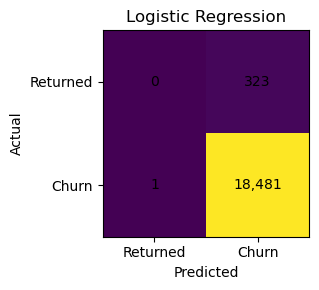

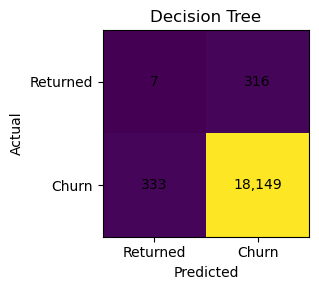

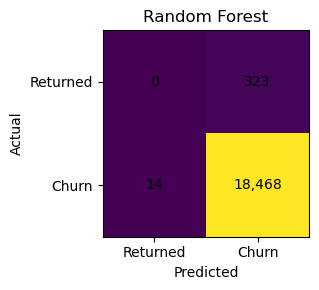

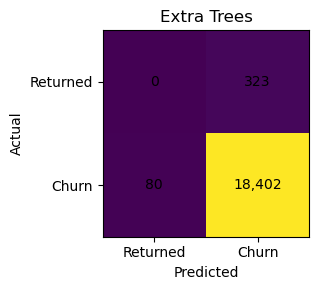

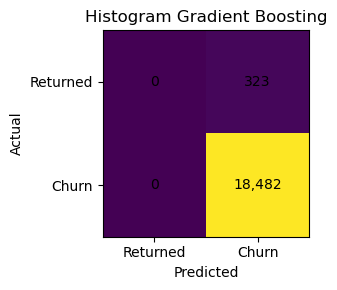

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for model_name, model in baseline_models.items():

    oof_pred = cross_val_predict(
        clone(model),
        X_train,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=1
    )

    cm = confusion_matrix(
        y_train,
        oof_pred,
        labels=[
            RETURNED_CLASS,
            CHURN_CLASS
        ]
    )

    fig, ax = plt.subplots(figsize=(4, 3))

    ax.imshow(cm)

    ax.set_title(model_name)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_xticklabels([
        "Returned",
        "Churn"
    ])

    ax.set_yticks([0, 1])
    ax.set_yticklabels([
        "Returned",
        "Churn"
    ])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

## 6. Baseline Model Evaluation

Baseline model comparison menunjukkan bahwa Accuracy berada pada kisaran 96.55%–98.28%.
Namun, tingginya Accuracy terutama dipengaruhi oleh class imbalance, karena 98.28% customer
pada training snapshot termasuk dalam kelas Churn / No New Order.

Pada default classification threshold, Logistic Regression, Histogram Gradient Boosting,
Random Forest, dan Extra Trees belum mengidentifikasi Returned customer, sehingga Precision,
Recall, F1-Score, dan F2-Score untuk Returned class bernilai 0%.

Decision Tree menghasilkan non-zero classification metrics untuk Returned customer, tetapi
performanya masih rendah dengan Precision 2.06%, Recall 2.17%, F1-Score 2.11%, dan
F2-Score 2.14%.

Karena hard classification metrics sangat dipengaruhi oleh classification threshold,
Average Precision digunakan sebagai primary metric untuk membandingkan kemampuan model
dalam memberikan ranking probability kepada Returned customer.

Hasil Average Precision:

- Logistic Regression: **2.84%**
- Histogram Gradient Boosting: **2.30%**
- Random Forest: **1.97%**
- Extra Trees: **1.88%**
- Decision Tree: **1.73%**

Dengan Returned prevalence sebesar sekitar **1.72%**, Logistic Regression menghasilkan
Average Precision tertinggi sebesar **2.84%**, atau sekitar **1.65x** prevalence baseline.

Hasil ini menunjukkan bahwa historical customer behavior memiliki predictive signal, meskipun
kemampuan pemisahan antara Returned dan Churn customer masih terbatas.

Logistic Regression dipilih sebagai baseline utama untuk tahap model improvement karena
memberikan ranking performance terbaik berdasarkan Average Precision.

Tahap berikutnya akan mengevaluasi apakah class imbalance treatment, hyperparameter tuning,
dan feature improvement dapat meningkatkan performa dibandingkan baseline Logistic
Regression sebesar 2.84%.

## 7. Model Improvement

### 7.1 Logistic Regression Hyperparameter Tuning

Logistic Regression dipilih sebagai baseline candidate karena menghasilkan Average Precision
tertinggi dibandingkan baseline model lainnya.

Baseline Logistic Regression menghasilkan:

- **Out-of-Fold Average Precision: 2.84%**

Target tetap sangat tidak seimbang, dengan Returned customer hanya sekitar 1.72% dari
training population.

Oleh karena itu, improvement pertama dilakukan melalui:

1. **Hyperparameter tuning pada parameter `C`** untuk mencari tingkat regularization yang
   menghasilkan ranking performance terbaik.
2. **Class weighting** untuk memberikan perhatian lebih besar terhadap minority class
   (Returned) selama proses training.

Seluruh kombinasi dievaluasi hanya menggunakan training data dengan Stratified 3-Fold
Cross-Validation.

Model improvement dianggap memberikan tambahan predictive value apabila Mean CV Average
Precision meningkat dibandingkan baseline Logistic Regression.

In [118]:
from sklearn.model_selection import GridSearchCV

def returned_ap_scorer(estimator, X, y):

    classes = list(
        estimator.named_steps["model"].classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        estimator.predict_proba(X)[:, return_index]
    )

    return average_precision_score(
        np.asarray(y) == RETURNED_CLASS,
        return_scores
    )


BASELINE_CV_AP = (
    baseline_results.loc[
        baseline_results["model"].eq("Logistic Regression"),
        "average_precision_returned"
    ]
    .iloc[0]
)

print(
    "Baseline Logistic AP:",
    f"{BASELINE_CV_AP:.4%}"
)

Baseline Logistic AP: 2.8384%


In [119]:
tuned_logistic = Pipeline([
    (
        "preprocessor",
        clone(logistic_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [120]:
param_grid = {
    "model__C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        1.0
    ],

    "model__class_weight": [
        None,
        {0: 1.5, 1: 1},
        {0: 2, 1: 1},
        {0: 3, 1: 1},
        {0: 5, 1: 1}
    ]
}

In [121]:
grid_search = GridSearchCV(
    estimator=tuned_logistic,
    param_grid=param_grid,
    scoring=returned_ap_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 35 candidates, totalling 105 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.001, 0.003, ...], 'model__class_weight': [None, {0: 1.5, 1: 1}, ...]}"
,scoring,<function ret...002197EE79080>
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('standard_numeric', ...), ('monetary', ...)]"


In [122]:
best_index = grid_search.best_index_

best_mean_cv_ap = grid_search.cv_results_[
    "mean_test_score"
][best_index]

best_std_cv_ap = grid_search.cv_results_[
    "std_test_score"
][best_index]

best_train_ap = grid_search.cv_results_[
    "mean_train_score"
][best_index]

print("BEST PARAMETERS")
print(grid_search.best_params_)

BEST PARAMETERS
{'model__C': 0.001, 'model__class_weight': {0: 5, 1: 1}}


In [123]:
best_params = grid_search.best_params_
best_mean_cv_ap = grid_search.best_score_

print("BEST PARAMETERS")
print(best_params)

print("\nMODEL IMPROVEMENT COMPARISON")
print(
    "Baseline Logistic:",
    f"{BASELINE_CV_AP:.4%}"
)
print(
    "Tuned Logistic   :",
    f"{best_mean_cv_ap:.4%}"
)

print(
    "\nImprovement vs Baseline:",
    f"{best_mean_cv_ap - BASELINE_CV_AP:+.4%}"
)

BEST PARAMETERS
{'model__C': 0.001, 'model__class_weight': {0: 5, 1: 1}}

MODEL IMPROVEMENT COMPARISON
Baseline Logistic: 2.8384%
Tuned Logistic   : 3.6349%

Improvement vs Baseline: +0.7966%


In [124]:
tuning_results = pd.DataFrame(
    grid_search.cv_results_
)

top_tuning_results = (
    tuning_results[
        [
            "param_model__C",
            "param_model__class_weight",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(
    top_tuning_results.style.format({
        "mean_train_score": "{:.4%}",
        "mean_test_score": "{:.4%}",
        "std_test_score": "{:.4%}"
    })
)

,param_model__C,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
0,0.001000,"{0: 5, 1: 1}",3.6564%,3.6349%,0.8112%
1,0.001000,None,3.6442%,3.6268%,0.8232%
2,0.001000,"{0: 3, 1: 1}",3.6678%,3.6175%,0.8071%
3,0.001000,"{0: 2, 1: 1}",3.6427%,3.6169%,0.8075%
4,0.003000,"{0: 5, 1: 1}",3.8146%,3.6136%,0.9651%
5,0.001000,"{0: 1.5, 1: 1}",3.6400%,3.6116%,0.8104%
6,0.030000,"{0: 3, 1: 1}",3.7654%,3.6063%,0.8479%
7,0.010000,"{0: 2, 1: 1}",3.8177%,3.6000%,0.9584%
8,0.100000,"{0: 2, 1: 1}",3.7749%,3.5999%,0.8402%
9,1.000000,"{0: 1.5, 1: 1}",3.7704%,3.5925%,0.8484%


### Hyperparameter Tuning Results

Hyperparameter tuning menghasilkan kombinasi terbaik:

- `C = 0.001`
- `class_weight = {0: 5, 1: 1}`

Tuned Logistic Regression menghasilkan Mean Cross-Validation Average Precision sebesar
**3.63%**, meningkat dari baseline Logistic Regression sebesar **2.84%**.

Peningkatan tersebut setara dengan sekitar **+0.80 percentage point** atau **+28.1% secara
relatif** dibandingkan baseline.

Mean training Average Precision sebesar **3.66%** juga relatif dekat dengan Mean CV Average
Precision sebesar **3.63%**, sehingga pada tahap ini tidak terlihat gap train–cross-validation
yang besar.

Hasil tuning menunjukkan bahwa regularization yang lebih kuat dan pemberian weight yang lebih
besar pada minority class Returned dapat meningkatkan kemampuan model dalam memberikan
ranking kepada customer yang berpotensi kembali.

Namun, performa terhadap periode waktu yang berbeda belum dievaluasi pada tahap ini.
Temporal generalization akan diperiksa menggunakan validation snapshot sebelum final
evaluation pada holdout test set.

### 7.2 Behavioral Feature Engineering

Setelah hyperparameter tuning meningkatkan Average Precision, improvement berikutnya
difokuskan pada penambahan historical behavioral features.

Seluruh feature baru hanya diturunkan dari aktivitas customer sebelum prediction date untuk
menghindari data leakage.

Feature engineering yang dilakukan:

1. `is_repeat_customer`  
   Menunjukkan apakah customer memiliki lebih dari satu historical Delivered order.

2. `avg_order_value`  
   Mengukur rata-rata merchandise value per historical Delivered order.

3. `items_per_order`  
   Mengukur rata-rata jumlah item per historical Delivered order.

4. `product_diversity_ratio`  
   Mengukur proporsi unique products terhadap total historical items.

Feature tambahan ini digunakan untuk menguji apakah purchase intensity dan historical
engagement memberikan predictive signal tambahan di luar baseline feature set.

In [125]:
def add_behavioral_features(X):
    X = X.copy()

    # Pernah melakukan lebih dari satu historical order
    X["is_repeat_customer"] = (
        X["frequency"] >= 2
    ).astype(int)

    # Rata-rata nilai transaksi per order
    X["avg_order_value"] = (
        X["monetary"]
        / X["frequency"].clip(lower=1)
    )

    # Rata-rata item per order
    X["items_per_order"] = (
        X["total_items"]
        / X["frequency"].clip(lower=1)
    )

    # Keragaman produk dibandingkan jumlah item
    X["product_diversity_ratio"] = (
        X["unique_products"]
        / X["total_items"].clip(lower=1)
    )

    return X

In [126]:
X_train_engineered = add_behavioral_features(
    X_train
)

X_validation_engineered = add_behavioral_features(
    X_validation
)

print(
    "Feature awal:",
    X_train.shape[1]
)

print(
    "Setelah feature engineering:",
    X_train_engineered.shape[1]
)

display(
    X_train_engineered.head()
)

Feature awal: 5
Setelah feature engineering: 9


,recency_days,frequency,monetary,total_items,unique_products,is_repeat_customer,avg_order_value,items_per_order,product_diversity_ratio
0,174.121493,1,69.00,1,1,0,69.00,1.0,1.0
1,44.608912,1,13.90,1,1,0,13.90,1.0,1.0
2,20.426910,1,76.99,1,1,0,76.99,1.0,1.0
3,14.201007,1,229.80,2,2,0,229.80,2.0,1.0
4,51.525891,1,299.00,1,1,0,299.00,1.0,1.0


In [127]:
ENGINEERED_FEATURES = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products",
    "is_repeat_customer",
    "avg_order_value",
    "items_per_order",
    "product_diversity_ratio"
]

In [128]:
engineered_standard_features = [
    "recency_days",
    "frequency",
    "total_items",
    "unique_products",
    "is_repeat_customer",
    "items_per_order",
    "product_diversity_ratio"
]

engineered_log_features = [
    "monetary",
    "avg_order_value"
]

In [129]:
engineered_standard_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

engineered_log_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "log_transform",
        FunctionTransformer(np.log1p)
    ),
    (
        "scaler",
        StandardScaler()
    )
])

engineered_preprocessor = ColumnTransformer([
    (
        "standard_numeric",
        engineered_standard_pipeline,
        engineered_standard_features
    ),
    (
        "log_numeric",
        engineered_log_pipeline,
        engineered_log_features
    )
])

print(
    "Behavioral feature preprocessing pipeline created."
)

Behavioral feature preprocessing pipeline created.


In [130]:
behavioral_logistic = Pipeline([
    (
        "preprocessor",
        clone(engineered_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            C=grid_search.best_params_["model__C"],
            class_weight=grid_search.best_params_["model__class_weight"],
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [131]:
behavioral_cv_scores = []

for train_idx, valid_idx in cv.split(
    X_train_engineered,
    y_train
):
    X_fold_train = X_train_engineered.iloc[
        train_idx
    ]

    y_fold_train = y_train.iloc[
        train_idx
    ]

    X_fold_valid = X_train_engineered.iloc[
        valid_idx
    ]

    y_fold_valid = y_train.iloc[
        valid_idx
    ]

    fold_model = clone(
        behavioral_logistic
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    classes = list(
        fold_model
        .named_steps["model"]
        .classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        fold_model
        .predict_proba(
            X_fold_valid
        )[:, return_index]
    )

    fold_ap = average_precision_score(
        y_fold_valid.eq(RETURNED_CLASS),
        return_scores
    )

    behavioral_cv_scores.append(
        fold_ap
    )

In [132]:
behavioral_mean_cv_ap = np.mean(
    behavioral_cv_scores
)

behavioral_std_cv_ap = np.std(
    behavioral_cv_scores
)

print(
    "Baseline Logistic:",
    f"{BASELINE_CV_AP:.4%}"
)

print(
    "Tuned Logistic:",
    f"{best_mean_cv_ap:.4%}"
)

print(
    "Behavioral Features:",
    f"{behavioral_mean_cv_ap:.4%}"
)

print(
    "\nDifference vs Tuned Logistic:",
    f"{behavioral_mean_cv_ap - best_mean_cv_ap:+.4%}"
)

print(
    "CV Standard Deviation:",
    f"{behavioral_std_cv_ap:.4%}"
)

Baseline Logistic: 2.8384%
Tuned Logistic: 3.6349%
Behavioral Features: 3.7642%

Difference vs Tuned Logistic: +0.1292%
CV Standard Deviation: 0.8599%


### Hasil Behavioral Feature Engineering

Penambahan behavioral engineered features meningkatkan Mean CV Average Precision dibandingkan
Tuned Logistic Regression.

Hasil Mean CV Average Precision:

- Baseline Logistic Regression: **2.84%**
- Tuned Logistic Regression: **3.63%**
- Tuned Logistic + Behavioral Features: **3.76%**

Behavioral feature engineering menghasilkan peningkatan sebesar sekitar **+0.13 percentage
point** atau **+3.55% secara relatif** dibandingkan Tuned Logistic Regression.

Hasil ini menunjukkan bahwa informasi behavioral tambahan seperti historical multi-order behavior, average order value, items per order, dan product diversity memberikan predictive signal tambahan di luar baseline feature set.

Namun, improvement yang diperoleh masih relatif terbatas. Oleh karena itu, behavioral
engineered features dipertahankan sebagai model candidate dan akan dibandingkan dengan
eksperimen feature improvement berikutnya sebelum menentukan final feature set.

Model candidate terbaik sementara adalah Tuned Logistic Regression + Behavioral Features
dengan Mean CV Average Precision sebesar **3.76%**.

In [133]:
print("TRAIN SNAPSHOT COLUMNS:")
for col in train_snapshot.columns:
    print("-", col)

TRAIN SNAPSHOT COLUMNS:
- customer_unique_id
- first_order_date
- last_order_date
- frequency
- orders_with_known_value
- recency_days
- known_merchandise_value
- orders_missing_value
- monetary
- churn_180d
- total_items
- unique_products
- prediction_date


### 7.3 Expanded Historical Features

Eksperimen berikutnya dilakukan dengan menambahkan historical features yang sebenarnya
sudah tersedia pada customer snapshot tetapi belum digunakan pada baseline maupun behavioral
feature model.

Feature tambahan yang diuji:

- `orders_with_known_value`: jumlah historical Delivered orders yang memiliki merchandise
  value yang dapat dihitung.
- `known_merchandise_value`: total merchandise value yang diketahui selama historical
  observation window.
- `orders_missing_value`: jumlah historical Delivered orders yang tidak memiliki merchandise
  value lengkap.

Eksperimen ini bertujuan untuk mengevaluasi apakah informasi mengenai kelengkapan dan nilai
historical transactions memberikan predictive signal tambahan untuk mengidentifikasi Returned
customer.

Seluruh feature hanya berasal dari historical observation window sebelum prediction date,
sehingga tidak menggunakan informasi dari future prediction window.

In [134]:
EXPANDED_FEATURES = [
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "unique_products",
    "orders_with_known_value",
    "known_merchandise_value",
    "orders_missing_value"
]

X_train_expanded = (
    train_snapshot[EXPANDED_FEATURES]
    .copy()
)

X_validation_expanded = (
    validation_snapshot[EXPANDED_FEATURES]
    .copy()
)

print(
    "Baseline features:",
    len(feature_columns)
)

print(
    "Expanded features:",
    len(EXPANDED_FEATURES)
)

print("\nExpanded feature list:")

for feature in EXPANDED_FEATURES:
    print("-", feature)

Baseline features: 5
Expanded features: 8

Expanded feature list:
- recency_days
- frequency
- monetary
- total_items
- unique_products
- orders_with_known_value
- known_merchandise_value
- orders_missing_value


In [135]:
expanded_feature_check = (
    X_train_expanded[
        [
            "orders_with_known_value",
            "known_merchandise_value",
            "orders_missing_value"
        ]
    ]
    .describe()
    .T
)

display(
    expanded_feature_check.round(2)
)

print(
    "\nUnique values in orders_missing_value:",
    X_train_expanded["orders_missing_value"].nunique()
)

,count,mean,std,min,25%,50%,75%,max
orders_with_known_value,18805.0,1.03,0.17,1.0,1.0,1.00,1.00,4.0
known_merchandise_value,18805.0,138.43,216.63,3.9,45.9,85.99,149.99,7388.0
orders_missing_value,18805.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0



Unique values in orders_missing_value: 1


In [136]:
expanded_standard_features = [
    "recency_days",
    "frequency",
    "total_items",
    "unique_products",
    "orders_with_known_value",
    "orders_missing_value"
]

expanded_log_features = [
    "monetary",
    "known_merchandise_value"
]

expanded_preprocessor = ColumnTransformer([
    (
        "standard_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        expanded_standard_features
    ),
    (
        "log_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "log_transform",
                FunctionTransformer(np.log1p)
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        expanded_log_features
    )
])

print(
    "Expanded feature preprocessing pipeline created."
)

Expanded feature preprocessing pipeline created.


In [137]:
expanded_logistic = Pipeline([
    (
        "preprocessor",
        clone(expanded_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            C=grid_search.best_params_["model__C"],
            class_weight=grid_search.best_params_[
                "model__class_weight"
            ],
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [138]:
expanded_cv_scores = []

for train_idx, valid_idx in cv.split(
    X_train_expanded,
    y_train
):

    X_fold_train = (
        X_train_expanded.iloc[train_idx]
    )

    y_fold_train = (
        y_train.iloc[train_idx]
    )

    X_fold_valid = (
        X_train_expanded.iloc[valid_idx]
    )

    y_fold_valid = (
        y_train.iloc[valid_idx]
    )

    fold_model = clone(
        expanded_logistic
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    classes = list(
        fold_model
        .named_steps["model"]
        .classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        fold_model
        .predict_proba(
            X_fold_valid
        )[:, return_index]
    )

    fold_ap = average_precision_score(
        y_fold_valid.eq(RETURNED_CLASS),
        return_scores
    )

    expanded_cv_scores.append(
        fold_ap
    )

In [139]:
expanded_cv_ap = np.mean(
    expanded_cv_scores
)

expanded_cv_std = np.std(
    expanded_cv_scores
)

print(
    "Baseline Logistic:",
    f"{BASELINE_CV_AP:.4%}"
)

print(
    "Tuned Logistic:",
    f"{best_mean_cv_ap:.4%}"
)

print(
    "Behavioral Features:",
    f"{behavioral_mean_cv_ap:.4%}"
)

print(
    "Expanded Historical Features:",
    f"{expanded_cv_ap:.4%}"
)

print(
    "\nDifference vs Current Best:",
    f"{expanded_cv_ap - behavioral_mean_cv_ap:+.4%}"
)

print(
    "CV Standard Deviation:",
    f"{expanded_cv_std:.4%}"
)

Baseline Logistic: 2.8384%
Tuned Logistic: 3.6349%
Behavioral Features: 3.7642%
Expanded Historical Features: 3.8068%

Difference vs Current Best: +0.0426%
CV Standard Deviation: 0.9059%


### Hasil Expanded Historical Features

Penambahan expanded historical features menghasilkan peningkatan kecil pada Mean CV Average
Precision.

Hasil Mean CV Average Precision:

- Baseline Logistic Regression: **2.84%**
- Tuned Logistic Regression: **3.63%**
- Behavioral Feature Engineering: **3.76%**
- Expanded Historical Features: **3.81%**

Expanded Historical Features menghasilkan peningkatan sekitar **+0.04 percentage point**
dibandingkan Behavioral Feature model yang sebelumnya merupakan model candidate terbaik.

Namun, diagnostic check menunjukkan bahwa `orders_missing_value` memiliki nilai 0 untuk
seluruh training customers setelah eligibility dibatasi hanya pada Delivered orders. Dengan
demikian, feature tersebut tidak memiliki variation dan tidak memberikan predictive
information.

Peningkatan performa Expanded Historical Features relatif kecil, sehingga hasil ini belum
cukup untuk menentukan final model. Model akan tetap dibandingkan dengan eksperimen feature
berikutnya sebelum dilakukan temporal validation.

Model candidate terbaik sementara adalah Expanded Historical Features dengan Mean CV
Average Precision sebesar **3.81%**.

In [140]:
objects_to_check = [
    "orders_prepared",
    "orders_clean",
    "order_items_clean",
    "payments",
    "order_payments",
    "reviews",
    "order_reviews",
    "products",
    "products_clean",
    "customers"
]

for name in objects_to_check:
    if name in globals():
        obj = globals()[name]

        print(f"\n{name}")
        print("-" * len(name))

        if hasattr(obj, "shape"):
            print("Shape:", obj.shape)

        if hasattr(obj, "columns"):
            print("Columns:")
            print(obj.columns.tolist())


orders_prepared
---------------
Shape: (99441, 21)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_state', 'item_count', 'merchandise_value', 'freight_total', 'has_item_records', 'approval_before_purchase', 'carrier_before_purchase', 'delivery_before_purchase', 'delivery_before_carrier', 'delivered_without_delivery_date', 'canceled_with_delivery_date', 'has_date_sequence_issue']

orders_clean
------------
Shape: (99441, 8)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_items_clean
-----------------
Shape: (112650, 7)
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

customers
------

### 7.4 Geographic Feature — Customer State

Eksperimen berikutnya menambahkan informasi geografis customer berupa `customer_state`.

Feature ini digunakan untuk mengevaluasi apakah lokasi customer memberikan predictive signal
tambahan terhadap kemungkinan customer melakukan Delivered order kembali dalam 180 hari.

Karena `customer_state` merupakan categorical feature, feature diproses menggunakan
One-Hot Encoding sebelum masuk ke Logistic Regression.

Feature geografis hanya berasal dari informasi customer yang tersedia sebelum prediction date
dan digabungkan pada customer level untuk menjaga satu row per customer.

In [141]:
customer_state_map = (
    customers[
        [
            "customer_unique_id",
            "customer_state"
        ]
    ]
    .dropna(
        subset=[
            "customer_unique_id"
        ]
    )
    .drop_duplicates(
        subset=[
            "customer_unique_id"
        ]
    )
)

print(
    "Unique customers in state mapping:",
    customer_state_map[
        "customer_unique_id"
    ].nunique()
)

print(
    "Unique states:",
    customer_state_map[
        "customer_state"
    ].nunique()
)

Unique customers in state mapping: 96096
Unique states: 27


In [142]:
train_geo = (
    train_snapshot
    .merge(
        customer_state_map,
        on="customer_unique_id",
        how="left",
        validate="one_to_one"
    )
)

assert (
    len(train_geo)
    == len(train_snapshot)
)

assert (
    train_geo[
        "customer_unique_id"
    ].is_unique
)

print(
    "Training rows preserved:",
    len(train_geo)
)

print(
    "Missing customer_state:",
    train_geo[
        "customer_state"
    ].isna().sum()
)

Training rows preserved: 18805
Missing customer_state: 0


In [143]:
GEO_FEATURES = (
    EXPANDED_FEATURES
    + ["customer_state"]
)

X_train_geo = (
    train_geo[
        GEO_FEATURES
    ]
    .copy()
)

In [144]:
geo_preprocessor = ColumnTransformer([
    (
        "standard_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        expanded_standard_features
    ),

    (
        "log_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "log_transform",
                FunctionTransformer(np.log1p)
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        expanded_log_features
    ),

    (
        "customer_state",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        ["customer_state"]
    )
])

In [145]:
geo_logistic = Pipeline([
    (
        "preprocessor",
        clone(geo_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            C=grid_search.best_params_["model__C"],
            class_weight=grid_search.best_params_[
                "model__class_weight"
            ],
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [146]:
geo_cv_scores = []

for train_idx, valid_idx in cv.split(
    X_train_geo,
    y_train
):

    X_fold_train = (
        X_train_geo.iloc[train_idx]
    )

    y_fold_train = (
        y_train.iloc[train_idx]
    )

    X_fold_valid = (
        X_train_geo.iloc[valid_idx]
    )

    y_fold_valid = (
        y_train.iloc[valid_idx]
    )

    fold_model = clone(
        geo_logistic
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    classes = list(
        fold_model
        .named_steps["model"]
        .classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    return_scores = (
        fold_model
        .predict_proba(
            X_fold_valid
        )[:, return_index]
    )

    fold_ap = average_precision_score(
        y_fold_valid.eq(RETURNED_CLASS),
        return_scores
    )

    geo_cv_scores.append(
        fold_ap
    )

In [147]:
geo_cv_ap = np.mean(
    geo_cv_scores
)

geo_cv_std = np.std(
    geo_cv_scores
)

print(
    "Baseline Logistic:",
    f"{BASELINE_CV_AP:.4%}"
)

print(
    "Tuned Logistic:",
    f"{best_mean_cv_ap:.4%}"
)

print(
    "Behavioral Features:",
    f"{behavioral_mean_cv_ap:.4%}"
)

print(
    "Expanded Historical:",
    f"{expanded_cv_ap:.4%}"
)

print(
    "+ Customer State:",
    f"{geo_cv_ap:.4%}"
)

print(
    "\nDifference vs Current Best:",
    f"{geo_cv_ap - expanded_cv_ap:+.4%}"
)

print(
    "CV Standard Deviation:",
    f"{geo_cv_std:.4%}"
)

Baseline Logistic: 2.8384%
Tuned Logistic: 3.6349%
Behavioral Features: 3.7642%
Expanded Historical: 3.8068%
+ Customer State: 3.0521%

Difference vs Current Best: -0.7547%
CV Standard Deviation: 0.6821%


### Hasil Geographic Feature

Penambahan `customer_state` tidak meningkatkan performa model.

Hasil Mean CV Average Precision:

- Baseline Logistic Regression: **2.8384%**
- Tuned Logistic Regression: **3.6349%**
- Behavioral Features: **3.7642%**
- Expanded Historical Features: **3.8068%**
- Expanded Historical + Customer State: **3.0521%**

Penambahan `customer_state` menurunkan Mean CV Average Precision sebesar **0.7547 percentage point** dibandingkan current best model.

Hasil ini menunjukkan bahwa informasi geografis customer belum memberikan predictive signal tambahan yang membantu model dalam mengidentifikasi customer yang berpotensi melakukan Delivered order kembali dalam 180 hari.

Oleh karena itu, `customer_state` tidak digunakan pada model selanjutnya.

Model terbaik sementara tetap **Expanded Historical Features** dengan Mean CV Average Precision sebesar **3.8068%**.

### 7.5 Imbalance Treatment Comparison

Target pada project ini sangat tidak seimbang, dengan Returned customer hanya sekitar
1.72% dari training population.

Untuk mengevaluasi apakah treatment terhadap class imbalance dapat meningkatkan kemampuan
model dalam memberikan ranking kepada Returned customer, beberapa pendekatan dibandingkan:

1. **No Imbalance Treatment**
2. **Class Weight**
3. **Random Under-Sampling**
4. **SMOTE**

Seluruh treatment dibandingkan menggunakan Expanded Historical feature set dan Stratified
3-Fold Cross-Validation yang sama agar hasil dapat dibandingkan secara konsisten.

Average Precision untuk Returned customer tetap digunakan sebagai primary evaluation metric.

In [148]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import cross_validate

In [149]:
BEST_C = grid_search.best_params_["model__C"]
BEST_CLASS_WEIGHT = grid_search.best_params_["model__class_weight"]

imbalance_models = {

    "No Treatment": Pipeline([
        (
            "preprocessor",
            clone(expanded_preprocessor)
        ),
        (
            "model",
            LogisticRegression(
                C=BEST_C,
                class_weight=None,
                max_iter=5000,
                solver="liblinear",
                random_state=42
            )
        )
    ]),

    "Class Weight": Pipeline([
        (
            "preprocessor",
            clone(expanded_preprocessor)
        ),
        (
            "model",
            LogisticRegression(
                C=BEST_C,
                class_weight=BEST_CLASS_WEIGHT,
                max_iter=5000,
                solver="liblinear",
                random_state=42
            )
        )
    ]),

    "Random Under-Sampling": ImbPipeline([
        (
            "preprocessor",
            clone(expanded_preprocessor)
        ),
        (
            "sampler",
            RandomUnderSampler(
                sampling_strategy=0.20,
                random_state=42
            )
        ),
        (
            "model",
            LogisticRegression(
                C=BEST_C,
                class_weight=None,
                max_iter=5000,
                solver="liblinear",
                random_state=42
            )
        )
    ]),

    "SMOTE": ImbPipeline([
        (
            "preprocessor",
            clone(expanded_preprocessor)
        ),
        (
            "sampler",
            SMOTE(
                sampling_strategy=0.20,
                k_neighbors=5,
                random_state=42
            )
        ),
        (
            "model",
            LogisticRegression(
                C=BEST_C,
                class_weight=None,
                max_iter=5000,
                solver="liblinear",
                random_state=42
            )
        )
    ])
}

In [150]:
imbalance_rows = []

for treatment_name, model in imbalance_models.items():

    print(f"Evaluating: {treatment_name}")

    scores = cross_validate(
        estimator=clone(model),
        X=X_train_expanded,
        y=y_train,
        cv=cv,
        scoring=returned_ap_scorer,
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    imbalance_rows.append({
        "treatment": treatment_name,
        "mean_train_AP": scores["train_score"].mean(),
        "mean_CV_AP": scores["test_score"].mean(),
        "std_CV_AP": scores["test_score"].std()
    })


imbalance_results = (
    pd.DataFrame(imbalance_rows)
    .sort_values(
        "mean_CV_AP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    imbalance_results.style.format({
        "mean_train_AP": "{:.4%}",
        "mean_CV_AP": "{:.4%}",
        "std_CV_AP": "{:.4%}"
    })
)

Evaluating: No Treatment
Evaluating: Class Weight
Evaluating: Random Under-Sampling
Evaluating: SMOTE


,treatment,mean_train_AP,mean_CV_AP,std_CV_AP
0,SMOTE,3.5249%,3.8106%,0.7526%
1,Class Weight,3.7458%,3.8068%,0.9059%
2,No Treatment,3.6634%,3.6443%,0.8375%
3,Random Under-Sampling,3.4144%,3.2505%,0.9350%


In [151]:
CURRENT_BEST_AP = expanded_cv_ap

imbalance_results["difference_vs_current_best"] = (
    imbalance_results["mean_CV_AP"]
    - CURRENT_BEST_AP
)

display(
    imbalance_results[
        [
            "treatment",
            "mean_CV_AP",
            "std_CV_AP",
            "difference_vs_current_best"
        ]
    ].style.format({
        "mean_CV_AP": "{:.4%}",
        "std_CV_AP": "{:.4%}",
        "difference_vs_current_best": "{:+.4%}"
    })
)

,treatment,mean_CV_AP,std_CV_AP,difference_vs_current_best
0,SMOTE,3.8106%,0.7526%,+0.0038%
1,Class Weight,3.8068%,0.9059%,+0.0000%
2,No Treatment,3.6443%,0.8375%,-0.1625%
3,Random Under-Sampling,3.2505%,0.9350%,-0.5562%


### Hasil Imbalance Treatment

Empat pendekatan class imbalance dibandingkan menggunakan Expanded Historical feature set
dan Stratified 3-Fold Cross-Validation yang sama.

Hasil Mean CV Average Precision:

- SMOTE: **3.8106%**
- Class Weight: **3.8068%**
- No Treatment: **3.6443%**
- Random Under-Sampling: **3.2505%**

SMOTE menghasilkan Mean CV Average Precision tertinggi sebesar 3.8106%. Namun,
peningkatannya dibandingkan Class Weight hanya sebesar **0.0038 percentage point**.

Selisih tersebut sangat kecil dibandingkan variasi performa antar-fold, sehingga tidak
menunjukkan improvement yang meaningful dibandingkan Class Weight.

Class Weight dipertahankan sebagai imbalance treatment karena memberikan performa yang
praktis setara dengan SMOTE dengan pendekatan yang lebih sederhana dan tanpa menghasilkan
synthetic training observations.

No Treatment menghasilkan performa yang lebih rendah, sedangkan Random Under-Sampling
menunjukkan penurunan performa yang lebih besar.

Oleh karena itu, model candidate tetap menggunakan:

- `class_weight = {0: 5, 1: 1}`
- `C = 0.001`
- Expanded Historical feature set

dengan Mean CV Average Precision sebesar **3.8068%**.

In [152]:
print("Order Items:")
print("Rows:", len(order_items_clean))
print(
    "Unique products:",
    order_items_clean["product_id"].nunique()
)
print(
    "Unique sellers:",
    order_items_clean["seller_id"].nunique()
)

print("\nMissing values:")
print(
    order_items_clean[
        [
            "product_id",
            "seller_id",
            "price",
            "freight_value"
        ]
    ].isna().sum()
)

Order Items:
Rows: 112650
Unique products: 32951
Unique sellers: 3095

Missing values:
product_id       0
seller_id        0
price            0
freight_value    0
dtype: int64


### 7.6 Item and Seller Behavior Features

Eksperimen terakhir menambahkan informasi dari historical order-item behavior yang belum
sepenuhnya direpresentasikan pada feature set sebelumnya.

Feature yang diuji:

1. `unique_sellers`  
   Jumlah seller unik yang pernah digunakan customer selama historical observation window.

2. `avg_item_price`  
   Rata-rata harga item dari historical purchases.

3. `avg_freight_value`  
   Rata-rata freight value dari historical purchases.

4. `freight_to_price_ratio`  
   Rasio total freight value terhadap total item price.

Seluruh feature hanya dihitung dari item yang terhubung dengan historical Delivered orders
sebelum prediction date untuk mencegah data leakage.

Eksperimen ini digunakan untuk mengevaluasi apakah seller diversity dan karakteristik
item-level spending memberikan predictive signal tambahan terhadap kemungkinan customer
melakukan Delivered order kembali dalam 180 hari.

In [153]:
historical_items = (
    history_orders[
        [
            "order_id",
            "customer_unique_id"
        ]
    ]
    .merge(
        order_items_clean[
            [
                "order_id",
                "seller_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="inner",
        validate="one_to_many"
    )
)

print(
    "Historical Delivered orders:",
    history_orders["order_id"].nunique()
)

print(
    "Historical item rows:",
    len(historical_items)
)

print(
    "Historical customers with item data:",
    historical_items[
        "customer_unique_id"
    ].nunique()
)

Historical Delivered orders: 19295
Historical item rows: 21831
Historical customers with item data: 18805


In [154]:
item_seller_features = (
    historical_items
    .groupby("customer_unique_id")
    .agg(
        unique_sellers=(
            "seller_id",
            "nunique"
        ),
        avg_item_price=(
            "price",
            "mean"
        ),
        avg_freight_value=(
            "freight_value",
            "mean"
        ),
        total_item_price=(
            "price",
            "sum"
        ),
        total_freight_value=(
            "freight_value",
            "sum"
        )
    )
    .reset_index()
)

item_seller_features[
    "freight_to_price_ratio"
] = (
    item_seller_features[
        "total_freight_value"
    ]
    / item_seller_features[
        "total_item_price"
    ].replace(0, np.nan)
)

display(
    item_seller_features.head()
)

,customer_unique_id,unique_sellers,avg_item_price,avg_freight_value,total_item_price,total_freight_value,freight_to_price_ratio
0,0000f46a3911fa3c0805444483337064,1,69.00,17.22,69.00,17.22,0.249565
1,0006fdc98a402fceb4eb0ee528f6a8d4,1,13.90,15.10,13.90,15.10,1.086331
2,000a5ad9c4601d2bbdd9ed765d5213b3,1,76.99,14.29,76.99,14.29,0.185609
3,000de6019bb59f34c099a907c151d855,1,114.90,13.82,229.80,27.64,0.120279
4,0010a452c6d13139e50b57f19f52e04e,1,299.00,26.93,299.00,26.93,0.090067


In [155]:
train_item_seller = (
    train_snapshot
    .merge(
        item_seller_features,
        on="customer_unique_id",
        how="left",
        validate="one_to_one"
    )
)

ITEM_SELLER_FEATURES = (
    EXPANDED_FEATURES
    + [
        "unique_sellers",
        "avg_item_price",
        "avg_freight_value",
        "freight_to_price_ratio"
    ]
)

X_train_item_seller = (
    train_item_seller[
        ITEM_SELLER_FEATURES
    ]
    .copy()
)

print(
    "Training rows preserved:",
    len(train_item_seller)
)

print("\nMissing added features:")

display(
    X_train_item_seller[
        [
            "unique_sellers",
            "avg_item_price",
            "avg_freight_value",
            "freight_to_price_ratio"
        ]
    ]
    .isna()
    .sum()
)

Training rows preserved: 18805

Missing added features:


unique_sellers            0
avg_item_price            0
avg_freight_value         0
freight_to_price_ratio    0
dtype: int64

In [156]:
item_seller_standard_features = [
    "recency_days",
    "frequency",
    "total_items",
    "unique_products",
    "orders_with_known_value",
    "orders_missing_value",
    "unique_sellers"
]

item_seller_log_features = [
    "monetary",
    "known_merchandise_value",
    "avg_item_price",
    "avg_freight_value",
    "freight_to_price_ratio"
]

item_seller_preprocessor = ColumnTransformer([
    (
        "standard_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        item_seller_standard_features
    ),

    (
        "log_numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "log_transform",
                FunctionTransformer(np.log1p)
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        item_seller_log_features
    )
])

print(
    "Item & Seller preprocessing pipeline created."
)

Item & Seller preprocessing pipeline created.


In [157]:
item_seller_logistic = Pipeline([
    (
        "preprocessor",
        clone(item_seller_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            C=grid_search.best_params_["model__C"],
            class_weight=grid_search.best_params_[
                "model__class_weight"
            ],
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [158]:
item_seller_cv_scores = []
item_seller_train_scores = []

for train_idx, valid_idx in cv.split(
    X_train_item_seller,
    y_train
):

    X_fold_train = (
        X_train_item_seller.iloc[train_idx]
    )

    y_fold_train = (
        y_train.iloc[train_idx]
    )

    X_fold_valid = (
        X_train_item_seller.iloc[valid_idx]
    )

    y_fold_valid = (
        y_train.iloc[valid_idx]
    )

    fold_model = clone(
        item_seller_logistic
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    classes = list(
        fold_model
        .named_steps["model"]
        .classes_
    )

    return_index = classes.index(
        RETURNED_CLASS
    )

    # Validation probabilities
    valid_scores = (
        fold_model
        .predict_proba(
            X_fold_valid
        )[:, return_index]
    )

    # Training probabilities
    train_scores = (
        fold_model
        .predict_proba(
            X_fold_train
        )[:, return_index]
    )

    item_seller_cv_scores.append(
        average_precision_score(
            y_fold_valid.eq(RETURNED_CLASS),
            valid_scores
        )
    )

    item_seller_train_scores.append(
        average_precision_score(
            y_fold_train.eq(RETURNED_CLASS),
            train_scores
        )
    )

In [159]:
item_seller_cv_ap = np.mean(
    item_seller_cv_scores
)

item_seller_train_ap = np.mean(
    item_seller_train_scores
)

item_seller_std_ap = np.std(
    item_seller_cv_scores
)

print("MODEL IMPROVEMENT COMPARISON")

print(
    f"Baseline Logistic        : "
    f"{BASELINE_CV_AP:.4%}"
)

print(
    f"Tuned Logistic           : "
    f"{best_mean_cv_ap:.4%}"
)

print(
    f"Behavioral Features      : "
    f"{behavioral_mean_cv_ap:.4%}"
)

print(
    f"Expanded Historical      : "
    f"{expanded_cv_ap:.4%}"
)

print(
    f"Item & Seller Features   : "
    f"{item_seller_cv_ap:.4%}"
)

print("\nDIAGNOSTIC")

print(
    f"Train AP                 : "
    f"{item_seller_train_ap:.4%}"
)

print(
    f"CV Standard Deviation    : "
    f"{item_seller_std_ap:.4%}"
)

print(
    "\nDifference vs Current Best:",
    f"{item_seller_cv_ap - expanded_cv_ap:+.4%}"
)

MODEL IMPROVEMENT COMPARISON
Baseline Logistic        : 2.8384%
Tuned Logistic           : 3.6349%
Behavioral Features      : 3.7642%
Expanded Historical      : 3.8068%
Item & Seller Features   : 3.7569%

DIAGNOSTIC
Train AP                 : 3.6763%
CV Standard Deviation    : 0.7838%

Difference vs Current Best: -0.0498%


### Hasil Item & Seller Behavior Features

Penambahan Item & Seller Behavior Features tidak meningkatkan performa dibandingkan
Expanded Historical feature set.

Hasil Mean CV Average Precision:

- Baseline Logistic Regression: **2.8384%**
- Tuned Logistic Regression: **3.6349%**
- Behavioral Features: **3.7642%**
- Expanded Historical Features: **3.8068%**
- Item & Seller Features: **3.7569%**

Item & Seller Features menghasilkan Mean CV Average Precision sebesar **3.7569%**, atau
sekitar **0.0498 percentage point lebih rendah** dibandingkan Expanded Historical Features.

Hasil ini menunjukkan bahwa informasi tambahan mengenai seller diversity, average item price,
average freight value, dan freight-to-price ratio belum memberikan predictive signal tambahan
yang meningkatkan ranking performance.

Karena penambahan feature juga meningkatkan kompleksitas data preparation tanpa memberikan
peningkatan performa, Item & Seller Features tidak digunakan pada model selanjutnya.

Model candidate terbaik tetap menggunakan **Expanded Historical feature set** dengan
Logistic Regression, `C = 0.001`, dan `class_weight = {0: 5, 1: 1}`, dengan Mean CV
Average Precision sebesar **3.8068%**.

In [160]:
print("VALIDATION SNAPSHOT")
print("Rows:", len(validation_snapshot))

print("\nRequired columns:")

required_validation_columns = (
    EXPANDED_FEATURES
    + [target_column]
)

for col in required_validation_columns:
    print(
        col,
        "->",
        "OK" if col in validation_snapshot.columns else "MISSING"
    )

print("\nTarget distribution:")

print(
    validation_snapshot[target_column]
    .value_counts()
    .sort_index()
)

print("\nTarget percentage:")

print(
    validation_snapshot[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

VALIDATION SNAPSHOT
Rows: 26093

Required columns:
recency_days -> OK
frequency -> OK
monetary -> OK
total_items -> OK
unique_products -> OK
orders_with_known_value -> OK
known_merchandise_value -> OK
orders_missing_value -> OK
churn_180d -> OK

Target distribution:
churn_180d
0      389
1    25704
Name: count, dtype: int64

Target percentage:
churn_180d
0     1.49
1    98.51
Name: proportion, dtype: float64


## 8. Validation Evaluation

Setelah model development dan model selection dilakukan menggunakan training snapshot dan
Stratified Cross-Validation, model candidate terpilih dievaluasi pada validation snapshot dari
periode waktu berikutnya.

Model yang dievaluasi menggunakan:

- Expanded Historical feature set
- Logistic Regression
- `C = 0.001`
- `class_weight = {0: 5, 1: 1}`

Validation snapshot tidak digunakan dalam hyperparameter tuning dan tidak digunakan untuk memilih feature berdasarkan hasil validation performance. Seluruh model improvement dan feature experiments dilakukan pada training snapshot menggunakan Stratified Cross-Validation.

Evaluasi utama menggunakan:

- Average Precision
- Precision at Top 10%
- Recall at Top 10%
- Lift at Top 10%

Average Precision mengevaluasi kualitas ranking secara keseluruhan, sedangkan Top-10%
metrics menggambarkan performa model ketika bisnis hanya dapat memprioritaskan sebagian
customer dengan return score tertinggi.

In [161]:
selected_model = Pipeline([
    (
        "preprocessor",
        clone(expanded_preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            C=0.001,
            class_weight={0: 5, 1: 1},
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

selected_model.fit(
    X_train_expanded,
    y_train
)

print("Selected model fitted on full training snapshot.")

Selected model fitted on full training snapshot.


In [162]:
X_validation_expanded = (
    validation_snapshot[
        EXPANDED_FEATURES
    ]
    .copy()
)

y_validation = (
    validation_snapshot[
        target_column
    ]
    .copy()
)

classes = list(
    selected_model
    .named_steps["model"]
    .classes_
)

return_index = classes.index(
    RETURNED_CLASS
)

validation_return_score = (
    selected_model
    .predict_proba(
        X_validation_expanded
    )[:, return_index]
)

validation_returned = (
    y_validation.eq(RETURNED_CLASS)
)

validation_prevalence = (
    validation_returned.mean()
)

validation_ap = (
    average_precision_score(
        validation_returned,
        validation_return_score
    )
)

validation_lift_ap = (
    validation_ap
    / validation_prevalence
)

print(
    f"Validation Returned Prevalence : "
    f"{validation_prevalence:.4%}"
)

print(
    f"Validation Average Precision   : "
    f"{validation_ap:.4%}"
)

print(
    f"AP / Prevalence                : "
    f"{validation_lift_ap:.2f}x"
)

Validation Returned Prevalence : 1.4908%
Validation Average Precision   : 3.4720%
AP / Prevalence                : 2.33x


In [163]:
validation_eval = pd.DataFrame({
    "actual_returned": (
        y_validation
        .eq(RETURNED_CLASS)
        .astype(int)
    ),
    "return_score": (
        validation_return_score
    )
})

validation_eval = (
    validation_eval
    .sort_values(
        "return_score",
        ascending=False
    )
    .reset_index(drop=True)
)

top_10_n = int(
    np.ceil(
        len(validation_eval) * 0.10
    )
)

top_10 = (
    validation_eval
    .head(top_10_n)
)

precision_at_10 = (
    top_10[
        "actual_returned"
    ].mean()
)

total_returned = (
    validation_eval[
        "actual_returned"
    ].sum()
)

returned_in_top_10 = (
    top_10[
        "actual_returned"
    ].sum()
)

recall_at_10 = (
    returned_in_top_10
    / total_returned
)

lift_at_10 = (
    precision_at_10
    / validation_prevalence
)

print(
    "VALIDATION — TOP 10% EVALUATION"
)

print("-" * 40)

print(
    f"Total validation customers : "
    f"{len(validation_eval):,}"
)

print(
    f"Top 10% customers targeted : "
    f"{top_10_n:,}"
)

print(
    f"Total Returned customers    : "
    f"{total_returned:,}"
)

print(
    f"Returned captured Top 10%   : "
    f"{returned_in_top_10:,}"
)

print()

print(
    f"Precision @ Top 10% : "
    f"{precision_at_10:.2%}"
)

print(
    f"Recall @ Top 10%    : "
    f"{recall_at_10:.2%}"
)

print(
    f"Lift @ Top 10%      : "
    f"{lift_at_10:.2f}x"
)

VALIDATION — TOP 10% EVALUATION
----------------------------------------
Total validation customers : 26,093
Top 10% customers targeted : 2,610
Total Returned customers    : 389
Returned captured Top 10%   : 65

Precision @ Top 10% : 2.49%
Recall @ Top 10%    : 16.71%
Lift @ Top 10%      : 1.67x


### Validation Result Interpretation

Model menunjukkan kemampuan ranking yang tetap bertahan pada validation period yang belum
digunakan selama model development.

Hasil evaluasi validation:

- Total customers: **26,093**
- Returned customers: **389 (1.49%)**
- Average Precision: **3.47%**
- AP relative to prevalence: **2.33x**
- Precision @ Top 10%: **2.49%**
- Recall @ Top 10%: **16.71%**
- Lift @ Top 10%: **1.67x**

Mean Cross-Validation Average Precision pada training sebesar **3.81%**, sedangkan Average
Precision pada validation period sebesar **3.47%**.

Terdapat penurunan performa pada validation period, tetapi model tetap menghasilkan Average
Precision di atas prevalence baseline. Hal ini menunjukkan bahwa predictive signal yang
dipelajari pada training period masih dapat digunakan untuk memberikan ranking pada customer
di periode waktu berikutnya.

Ketika hanya 10% customer dengan return score tertinggi yang diprioritaskan, kelompok tersebut
memiliki return rate sebesar **2.49%**, dibandingkan **1.49%** pada keseluruhan validation
population, atau sekitar **1.67 kali lebih tinggi**.

Model therefore lebih sesuai digunakan sebagai **customer prioritization / ranking model**
daripada sebagai hard classification model menggunakan default probability threshold.

## 9. Prediction Window Sensitivity Analysis

Prediction window utama pada project ini telah ditetapkan sebesar **180 hari** berdasarkan
Repeat Purchase Analysis.

Sensitivity analysis digunakan untuk melihat perubahan Returned prevalence pada beberapa prediction window yang lebih pendek hingga 180 hari.

Analisis ini tidak digunakan untuk melakukan retuning terhadap model yang telah dipilih.

In [164]:
sensitivity_windows = [
    30,
    60,
    90,
    120,
    150,
    180
]

sensitivity_rows = []

validation_prediction_date = (
    snapshot_dates["validation"]
)

validation_history_start = (
    validation_prediction_date
    - pd.Timedelta(days=LOOKBACK_DAYS)
)

validation_history_orders = (
    modeling_orders.loc[
        (
            modeling_orders["order_purchase_timestamp"]
            >= validation_history_start
        )
        & (
            modeling_orders["order_purchase_timestamp"]
            < validation_prediction_date
        )
    ]
    .copy()
)

eligible_validation_customers = (
    validation_history_orders[
        "customer_unique_id"
    ]
    .dropna()
    .unique()
)

for days in sensitivity_windows:

    future_end = (
        validation_prediction_date
        + pd.Timedelta(days=days)
    )

    future_customer_ids = (
        modeling_orders.loc[
            (
                modeling_orders["order_purchase_timestamp"]
                >= validation_prediction_date
            )
            & (
                modeling_orders["order_purchase_timestamp"]
                < future_end
            )
            & (
                modeling_orders["customer_unique_id"]
                .isin(eligible_validation_customers)
            ),
            "customer_unique_id"
        ]
        .dropna()
        .unique()
    )

    returned_count = len(
        future_customer_ids
    )

    returned_rate = (
        returned_count
        / len(eligible_validation_customers)
    )

    sensitivity_rows.append({
        "prediction_days": days,
        "eligible_customers": len(
            eligible_validation_customers
        ),
        "returned_customers": returned_count,
        "returned_rate": returned_rate
    })


prediction_window_sensitivity = (
    pd.DataFrame(
        sensitivity_rows
    )
)

display(
    prediction_window_sensitivity.style.format({
        "returned_rate": "{:.2%}"
    })
)

,prediction_days,eligible_customers,returned_customers,returned_rate
0,30,26093,91,0.35%
1,60,26093,176,0.67%
2,90,26093,230,0.88%
3,120,26093,285,1.09%
4,150,26093,333,1.28%
5,180,26093,389,1.49%


### Prediction Window Sensitivity — Findings

Returned prevalence meningkat seiring bertambahnya future prediction window karena customer
memiliki waktu yang lebih panjang untuk melakukan repeat purchase.

Sensitivity analysis ini digunakan sebagai robustness check terhadap definisi target.

Prediction window utama tetap **180 hari**, karena:

- telah didukung oleh Repeat Purchase Analysis,
- menangkap sebagian besar observed first repeat purchases,
- dan menghasilkan jumlah Returned customer yang lebih memadai untuk modelling dibandingkan
  prediction window yang lebih pendek.

Tidak dilakukan model retuning berdasarkan sensitivity analysis ini agar validation period tetap
tidak digunakan sebagai sumber keputusan model development.

### 10. Final Test Evaluation

Final selected model dievaluasi pada test snapshot yang disimpan sebagai final holdout dan tidak digunakan selama model development maupun model selection.
Evaluasi dilakukan menggunakan metric yang sama dengan validation period, yaitu Average Precision, AP relative to prevalence, Precision @ Top 10%, Recall @ Top 10%, dan Lift @ Top 10%.
Test result digunakan hanya untuk mengukur temporal generalization model dan tidak digunakan untuk melakukan retuning atau perubahan model.

In [165]:
# Prepare final test data
X_test_expanded = (
    test_snapshot[
        EXPANDED_FEATURES
    ]
    .copy()
)

y_test = (
    test_snapshot[
        target_column
    ]
    .copy()
)

# Returned class probability / score
classes = list(
    selected_model
    .named_steps["model"]
    .classes_
)

return_index = classes.index(
    RETURNED_CLASS
)

test_return_score = (
    selected_model
    .predict_proba(
        X_test_expanded
    )[:, return_index]
)

# Actual Returned outcome
test_returned = (
    y_test.eq(RETURNED_CLASS)
)

# Overall prevalence
test_prevalence = (
    test_returned.mean()
)

# Average Precision
test_ap = (
    average_precision_score(
        test_returned,
        test_return_score
    )
)

# AP relative to prevalence
test_ap_lift = (
    test_ap
    / test_prevalence
)

print("FINAL TEST — OVERALL EVALUATION")
print("-" * 40)

print(
    f"Test Returned Prevalence : "
    f"{test_prevalence:.4%}"
)

print(
    f"Test Average Precision   : "
    f"{test_ap:.4%}"
)

print(
    f"AP / Prevalence          : "
    f"{test_ap_lift:.2f}x"
)

FINAL TEST — OVERALL EVALUATION
----------------------------------------
Test Returned Prevalence : 1.3267%
Test Average Precision   : 3.7494%
AP / Prevalence          : 2.83x


In [166]:
test_eval = pd.DataFrame({
    "actual_returned": (
        test_returned.astype(int)
    ),
    "return_score": (
        test_return_score
    )
})

test_eval = (
    test_eval
    .sort_values(
        "return_score",
        ascending=False
    )
    .reset_index(drop=True)
)

top_10_n = int(
    np.ceil(
        len(test_eval) * 0.10
    )
)

top_10 = (
    test_eval
    .head(top_10_n)
)

precision_at_10_test = (
    top_10[
        "actual_returned"
    ].mean()
)

total_returned_test = (
    test_eval[
        "actual_returned"
    ].sum()
)

returned_in_top_10_test = (
    top_10[
        "actual_returned"
    ].sum()
)

recall_at_10_test = (
    returned_in_top_10_test
    / total_returned_test
)

lift_at_10_test = (
    precision_at_10_test
    / test_prevalence
)

print()
print("FINAL TEST — TOP 10% EVALUATION")
print("-" * 40)

print(
    f"Total test customers        : "
    f"{len(test_eval):,}"
)

print(
    f"Top 10% customers targeted  : "
    f"{top_10_n:,}"
)

print(
    f"Total Returned customers     : "
    f"{total_returned_test:,}"
)

print(
    f"Returned captured Top 10%    : "
    f"{returned_in_top_10_test:,}"
)

print(
    f"Precision @ Top 10%          : "
    f"{precision_at_10_test:.2%}"
)

print(
    f"Recall @ Top 10%             : "
    f"{recall_at_10_test:.2%}"
)

print(
    f"Lift @ Top 10%               : "
    f"{lift_at_10_test:.2f}x"
)


FINAL TEST — TOP 10% EVALUATION
----------------------------------------
Total test customers        : 34,069
Top 10% customers targeted  : 3,407
Total Returned customers     : 452
Returned captured Top 10%    : 88
Precision @ Top 10%          : 2.58%
Recall @ Top 10%             : 19.47%
Lift @ Top 10%               : 1.95x


## Final Test Result Interpretation

Final selected model menunjukkan bahwa **temporal generalization tetap bertahan pada test snapshot** yang sebelumnya tidak digunakan selama model development maupun model selection.

Pada test population, **Returned prevalence sebesar 1.33%**, sedangkan **Average Precision model mencapai 3.75%**. Dengan demikian, Average Precision model berada di sekitar **2.83x dibandingkan prevalence baseline**.

Hasil ini menunjukkan bahwa walaupun nilai Average Precision terlihat rendah secara absolut, model tetap memiliki **ranking ability yang lebih baik dibandingkan random prioritization**, karena Returned customer memang merupakan minority class dengan prevalence yang sangat rendah.

Ketika hanya **Top 10% customer dengan return score tertinggi** yang diprioritaskan:

- **Precision @ Top 10% = 2.58%**
- **Recall @ Top 10% = 19.47%**
- **Lift @ Top 10% = 1.95x**
- **88 dari total 452 Returned customers** berhasil tercakup dalam Top 10% shortlist.

Artinya, customer pada **Top 10% ranking memiliki return rate sekitar 1.95 kali lebih tinggi** dibandingkan overall test population, yaitu **2.58% dibandingkan 1.33%**.

Hasil ini menunjukkan bahwa model lebih sesuai digunakan sebagai **customer prioritization / ranking tool** dibandingkan sebagai hard classification model menggunakan default probability threshold.

## 11. Customer Prioritization — Cumulative Lift Analysis

Untuk mengevaluasi usefulness model dalam konteks customer prioritization, customer pada test snapshot diurutkan berdasarkan **return score** dari tertinggi ke terendah.

Performance kemudian dievaluasi pada beberapa ukuran customer shortlist, yaitu **Top 5%, Top 10%, Top 20%, dan Top 30%**.

Untuk setiap cutoff dihitung:

- **Precision**: proporsi customer dalam shortlist yang benar-benar Returned.
- **Recall**: proporsi seluruh actual Returned customers yang berhasil tercakup dalam shortlist.
- **Lift**: perbandingan return rate pada shortlist terhadap overall Returned prevalence.

Analisis ini membantu menunjukkan seberapa efektif model dalam mengonsentrasikan customer Returned pada kelompok prioritas dibandingkan random prioritization.

In [167]:
cutoffs = [0.05, 0.10, 0.20, 0.30]

priority_rows = []

for cutoff in cutoffs:
    n_customers = int(
        np.ceil(
            len(test_eval) * cutoff
        )
    )

    shortlist = (
        test_eval
        .head(n_customers)
    )

    precision = (
        shortlist[
            "actual_returned"
        ].mean()
    )

    returned_captured = (
        shortlist[
            "actual_returned"
        ].sum()
    )

    recall = (
        returned_captured
        / total_returned_test
    )

    lift = (
        precision
        / test_prevalence
    )

    priority_rows.append({
        "Top Customer %": cutoff,
        "Customers Targeted": n_customers,
        "Returned Captured": returned_captured,
        "Precision": precision,
        "Recall": recall,
        "Lift": lift
    })

priority_table = pd.DataFrame(
    priority_rows
)

display(
    priority_table.style.format({
        "Top Customer %": "{:.0%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "Lift": "{:.2f}x"
    })
)

,Top Customer %,Customers Targeted,Returned Captured,Precision,Recall,Lift
0,5%,1704,68,3.99%,15.04%,3.01x
1,10%,3407,88,2.58%,19.47%,1.95x
2,20%,6814,145,2.13%,32.08%,1.60x
3,30%,10221,193,1.89%,42.70%,1.42x


### Cumulative Lift Analysis — Interpretation

Hasil customer prioritization menunjukkan bahwa model mampu mengonsentrasikan customer Returned pada kelompok dengan return score tertinggi.

Pada **Top 5% customer**, return rate mencapai **3.99%**, dibandingkan overall Returned prevalence sebesar **1.33%**. Dengan demikian, kelompok Top 5% memiliki konsentrasi Returned sekitar **3.01x lebih tinggi** dibandingkan keseluruhan test population.

Secara keseluruhan:

- **Top 5%** customer menangkap **68 Returned customers**, dengan **Precision 3.99%**, **Recall 15.04%**, dan **Lift 3.01x**.
- **Top 10%** customer menangkap **88 Returned customers**, dengan **Precision 2.58%**, **Recall 19.47%**, dan **Lift 1.95x**.
- **Top 20%** customer menangkap **145 Returned customers**, dengan **Recall 32.08%** dan **Lift 1.60x**.
- **Top 30%** customer menangkap **193 Returned customers**, dengan **Recall 42.70%** dan **Lift 1.42x**.

Hasil ini menunjukkan adanya trade-off antara **precision dan coverage**. Semakin kecil customer shortlist, semakin tinggi konsentrasi Returned customer, sedangkan shortlist yang lebih besar dapat menangkap lebih banyak Returned customers tetapi dengan lift yang lebih rendah.

Untuk use case dengan campaign capacity yang terbatas, **Top 5%–10% customer dapat menjadi starting point yang lebih efisien untuk customer prioritization** dibandingkan melakukan targeting secara luas.

## 12. Model Interpretation — Logistic Regression Coefficients

Untuk memahami historical customer behavior yang paling berkontribusi terhadap prediction model, coefficient dari final Logistic Regression dianalisis.

Karena target model dikodekan sebagai:

- **0 = Returned / Not Churn**
- **1 = Churn / No New Order**

maka:

- **Coefficient positif** mendorong prediction ke arah **Churn / No New Order**.
- **Coefficient negatif** mendorong prediction ke arah **Returned / Not Churn**.

Besarnya absolute coefficient digunakan untuk melihat seberapa kuat kontribusi relatif setiap feature terhadap model setelah preprocessing.

In [168]:
# Feature names mengikuti urutan di expanded_preprocessor
feature_names = (
    expanded_standard_features
    + expanded_log_features
)

# Logistic Regression coefficients
coefficients = (
    selected_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = (
    coef_df["coefficient"].abs()
)

coef_df = (
    coef_df
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(coef_df)

,feature,coefficient,abs_coefficient
0,recency_days,0.063764,0.063764
1,frequency,-0.055960,0.055960
2,orders_with_known_value,-0.055960,0.055960
3,total_items,-0.021351,0.021351
4,monetary,0.004372,0.004372
5,known_merchandise_value,0.004372,0.004372
6,unique_products,0.003341,0.003341
7,orders_missing_value,0.000000,0.000000


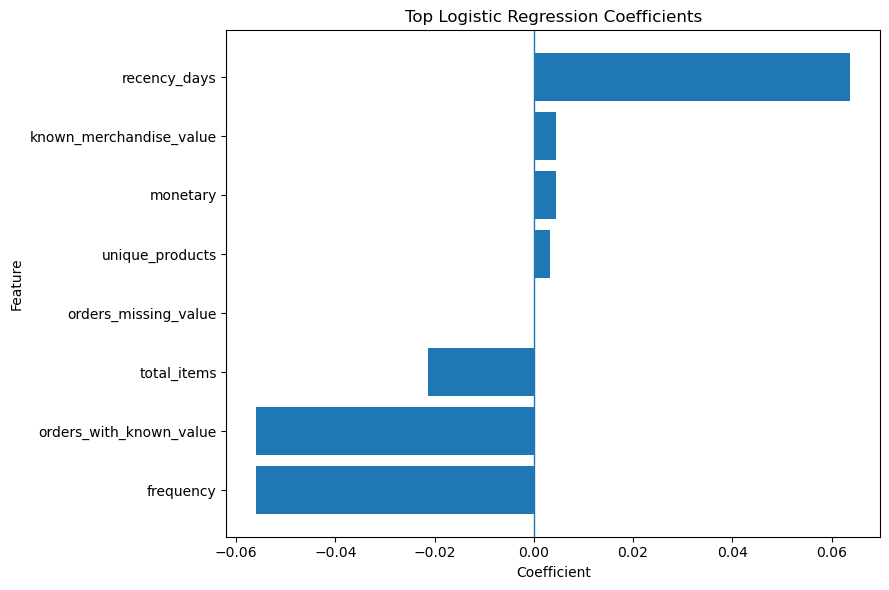

In [169]:
top_coef = (
    coef_df
    .head(10)
    .sort_values("coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_coef["feature"],
    top_coef["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Model Interpretation — Key Findings

Berdasarkan Logistic Regression coefficients, beberapa historical customer behaviors memiliki kontribusi yang lebih kuat terhadap prediction dibandingkan feature lainnya.

- **Recency Days** memiliki coefficient positif terbesar (**+0.0638**). Karena target `1 = Churn / No New Order`, nilai ini menunjukkan bahwa semakin lama waktu sejak historical order terakhir, prediction model semakin terdorong ke arah **Churn**.

- **Frequency** memiliki coefficient negatif sebesar **-0.0560**. Artinya, customer dengan historical order frequency yang lebih tinggi cenderung memiliki prediction yang lebih dekat ke **Returned / Not Churn**.

- **Orders with Known Value** juga memiliki coefficient negatif sebesar **-0.0560**, menunjukkan bahwa customer dengan lebih banyak historical orders yang memiliki transaction value lengkap cenderung lebih dekat ke Returned.

- **Total Items** memiliki coefficient negatif sebesar **-0.0214**, yang menunjukkan bahwa purchase depth yang lebih tinggi juga memberikan signal ke arah future return.

Sementara itu, **Monetary, Known Merchandise Value, dan Unique Products** memiliki coefficient yang relatif kecil, sehingga kontribusi relatifnya terhadap model lebih terbatas.

`orders_missing_value` memiliki coefficient sebesar **0**, sejalan dengan diagnostic sebelumnya bahwa feature tersebut tidak memiliki variation pada training data.

Secara keseluruhan, hasil ini menunjukkan bahwa **recency dan historical purchase frequency merupakan behavioral signals yang paling dominan dalam final model**, sedangkan historical spending value memberikan kontribusi yang lebih kecil.

Interpretasi coefficient ini menunjukkan association terhadap model prediction dan **tidak menyatakan hubungan kausal**.

## 13. Model Implementation — Customer Prioritization Flow

Final model dirancang untuk digunakan oleh **CRM / Retention Marketing Team** sebagai alat bantu dalam menentukan customer yang perlu diprioritaskan untuk retention activity.

Model tidak digunakan untuk memberikan hard classification bahwa seorang customer pasti akan kembali atau tidak kembali. Sebaliknya, model digunakan untuk menghasilkan **return score** yang merepresentasikan relative likelihood customer untuk melakukan repeat purchase berdasarkan historical customer behavior.

### Proposed Business Flow

1. **Historical Customer Data**
   - Menggunakan historical Delivered orders selama 180 hari sebelum prediction date.
   - Customer-level behavioral features dihitung, seperti recency, frequency, monetary value, total items, dan historical order information.

2. **Customer Scoring**
   - Final Logistic Regression model menghasilkan probability score untuk setiap customer.
   - Probability dari class Returned digunakan sebagai **return score**.

3. **Customer Ranking**
   - Customer diurutkan dari return score tertinggi ke terendah.
   - Ranking digunakan untuk membentuk prioritized customer shortlist.

4. **Campaign Prioritization**
   - CRM / Retention Marketing Team dapat memilih Top 5%, Top 10%, atau cutoff lain sesuai campaign capacity dan available budget.
   - Berdasarkan final test evaluation, Top 5% customer memiliki Returned rate **3.99%**, atau sekitar **3.01x** dibandingkan overall test prevalence sebesar **1.33%**.

5. **Retention Action**
   - Customer pada prioritized shortlist dapat digunakan sebagai target untuk retention activity seperti promotional communication, voucher, atau campaign lainnya.
   - Pemilihan actual treatment tetap bergantung pada business objective, campaign cost, dan available resources.

### Implementation Note

Model sebaiknya digunakan sebagai **ranking and prioritization tool**, bukan sebagai keputusan otomatis.

Karena actual retention campaign cost dan treatment response tidak tersedia dalam dataset, cutoff terbaik belum dapat ditentukan secara financial. Oleh karena itu, **Top 5%–10% dapat digunakan sebagai initial candidate segment**, kemudian effectiveness-nya perlu divalidasi melalui campaign experiment atau A/B testing.

## 14. Conclusion

Project ini bertujuan untuk memahami historical customer behavior dan membangun model yang dapat membantu **memprioritaskan customer berdasarkan kemungkinan melakukan pembelian kembali dalam 180 hari ke depan**.

Berdasarkan hasil analisis dan modelling, beberapa kesimpulan utama adalah:

1. **Historical customer behavior memiliki predictive signal terhadap future return behavior.**  
   Customer dengan recency yang lebih rendah dan historical purchase frequency yang lebih tinggi cenderung memiliki prediction yang lebih dekat ke **Returned / Not Churn**.

2. **Logistic Regression memberikan performance terbaik pada tahap model development.**  
   Setelah hyperparameter tuning dan feature improvement, model terbaik menggunakan **Expanded Historical Features**, dengan:
   - `C = 0.001`
   - `class_weight = {0: 5, 1: 1}`
   - Mean Cross-Validation Average Precision sebesar **3.81%**

3. **Model tetap menunjukkan ranking performance pada periode validation dan test.**
   - Validation Average Precision: **3.47%**
   - Final Test Average Precision: **3.75%**
   - Test Returned prevalence: **1.33%**
   - Test AP / prevalence: **2.83x**

   Walaupun Average Precision terlihat rendah secara absolut, Returned customer hanya sekitar **1–2% dari population**. Oleh karena itu, performance model lebih tepat dievaluasi relatif terhadap prevalence baseline.

4. **Model mampu meningkatkan konsentrasi Returned customer pada customer shortlist.**  
   Pada final test:
   - Top 5% customer memiliki return rate sebesar **3.99%**
   - dibandingkan overall prevalence sebesar **1.33%**
   - menghasilkan **Lift sebesar 3.01x**

   Hal ini menunjukkan bahwa model dapat membantu CRM / Retention Marketing Team memprioritaskan customer secara lebih informatif dibandingkan random targeting.

5. **Recency dan historical purchase frequency merupakan behavioral signals yang paling dominan dalam final model.**  
   Recency yang lebih tinggi mendorong prediction ke arah Churn / No New Order, sedangkan frequency yang lebih tinggi mendorong prediction ke arah Returned / Not Churn.

Secara keseluruhan, model lebih tepat digunakan sebagai **customer prioritization / ranking tool**, bukan sebagai hard classification model. Model dapat membantu menentukan customer shortlist untuk retention activity, sementara keputusan mengenai campaign treatment dan cutoff tetap perlu mempertimbangkan campaign capacity, cost, dan business objective.

## 15. Recommendation, Limitation, and Future Work

### Recommendation

Berdasarkan hasil modelling dan customer prioritization analysis, beberapa recommendation yang dapat diterapkan adalah:

1. **Gunakan model sebagai customer prioritization tool untuk retention activity.**  
   CRM / Retention Marketing Team dapat menggunakan return score untuk mengurutkan customer berdasarkan kemungkinan melakukan repeat purchase.

2. **Gunakan Top 5%–10% customer sebagai initial candidate segment.**  
   Berdasarkan final test evaluation:
   - Top 5% customer memiliki Returned rate sebesar **3.99%** dengan **Lift 3.01x**
   - Top 10% customer memiliki Returned rate sebesar **2.58%** dengan **Lift 1.95x**

   Hasil ini menunjukkan bahwa customer dengan return score tertinggi memiliki konsentrasi Returned yang lebih tinggi dibandingkan overall population.

3. **Sesuaikan cutoff dengan campaign capacity dan business objective.**  
   Jika campaign capacity terbatas, shortlist yang lebih kecil seperti Top 5% dapat memberikan customer concentration yang lebih tinggi.  
   Jika objective lebih menekankan coverage, cutoff dapat diperluas ke Top 10%–20% dengan konsekuensi lift yang lebih rendah.

4. **Validasi effectiveness model melalui campaign experiment.**  
   Customer shortlist sebaiknya diuji melalui controlled campaign atau A/B testing untuk mengukur apakah model-based targeting benar-benar meningkatkan response atau repeat purchase dibandingkan random targeting atau existing targeting method.

5. **Gunakan model bersama business rules, bukan sebagai automatic decision maker.**  
   Return score dapat menjadi salah satu input dalam retention decision, tetapi treatment akhir tetap perlu mempertimbangkan campaign eligibility, customer value, budget, dan business policy.

---

### Project Limitations

Beberapa keterbatasan project yang perlu diperhatikan:

1. **Churn merupakan proxy berdasarkan 180-day non-return.**  
   Dataset tidak menyediakan explicit churn label. Customer yang tidak melakukan recorded Delivered order dalam 180 hari belum tentu permanently churn.

2. **Dataset hanya mencatat aktivitas yang tersedia dalam Olist dataset.**  
   Customer mungkin melakukan transaksi di luar observation period atau melalui channel yang tidak tercatat dalam dataset.

3. **Returned customer merupakan minority class yang sangat kecil.**  
   Returned prevalence hanya sekitar 1–2%, sehingga predictive signal yang tersedia dalam historical transaction data relatif terbatas.

4. **Prediction windows antar-snapshot dapat overlap.**  
   Karena keterbatasan periode observasi dataset, train, validation, dan test digunakan sebagai rolling temporal evaluation points dan bukan fully non-overlapping forward-validation periods.

5. **Model belum menggunakan actual campaign response dan campaign cost.**  
   Oleh karena itu, cutoff customer yang paling optimal secara financial belum dapat ditentukan.

6. **Model probability belum dievaluasi sebagai calibrated probability.**  
   Karena model menggunakan class weighting, predicted probability pada project ini lebih tepat digunakan sebagai relative ranking score daripada sebagai estimasi probabilitas absolut customer akan kembali.

---

### Future Work

Beberapa pengembangan yang dapat dilakukan pada project selanjutnya:

1. **Menambahkan customer engagement dan campaign response data**  
   agar model dapat mempelajari customer response terhadap retention treatment secara langsung.

2. **Menambahkan customer value information**  
   seperti margin, lifetime value, atau expected revenue sehingga prioritization dapat mempertimbangkan potential business value, bukan hanya return likelihood.

3. **Melakukan probability calibration**  
   agar predicted score dapat diinterpretasikan lebih dekat sebagai actual return probability.

4. **Melakukan campaign A/B testing**  
   untuk membandingkan model-based targeting dengan random targeting atau current business targeting method.

5. **Mengevaluasi model pada periode data yang lebih panjang dan fully forward-looking**  
   untuk menguji temporal stability secara lebih kuat.

6. **Mengeksplorasi additional behavioral features dan alternative algorithms**  
   apabila tersedia data customer behavior yang lebih kaya.

## 16. Final Model Summary

Berdasarkan seluruh proses model development, feature improvement, temporal validation, dan final test evaluation, model akhir yang dipilih adalah:

- **Algorithm:** Logistic Regression
- **Feature Set:** Expanded Historical Features
- **Hyperparameter `C`:** 0.001
- **Class Weight:** `{0: 5, 1: 1}`
- **Primary Evaluation Metric:** Average Precision untuk Returned / Not Churn customer

### Model Performance Summary

- **Mean Cross-Validation Average Precision:** 3.81%
- **Validation Average Precision:** 3.47%
- **Final Test Average Precision:** 3.75%
- **Final Test Returned Prevalence:** 1.33%
- **Final Test AP / Prevalence:** 2.83x

### Customer Prioritization Performance

Pada final test:

- **Top 5%**
  - Precision: 3.99%
  - Recall: 15.04%
  - Lift: 3.01x

- **Top 10%**
  - Precision: 2.58%
  - Recall: 19.47%
  - Lift: 1.95x

Hasil ini menunjukkan bahwa final model memiliki kemampuan untuk memberikan **customer ranking yang lebih informatif dibandingkan prevalence baseline**.

Oleh karena itu, final model digunakan sebagai **customer prioritization / ranking tool** untuk membantu CRM / Retention Marketing Team menentukan customer shortlist berdasarkan return score.

In [170]:
holdout_demo = test_snapshot[
    [
        "customer_unique_id",
        "recency_days",
        "frequency",
        "monetary",
        "total_items",
        "unique_products",
        "orders_with_known_value",
        "known_merchandise_value",
        "orders_missing_value",
        "churn_180d"
    ]
].copy()

holdout_demo["actual_outcome"] = np.where(
    holdout_demo["churn_180d"] == 0,
    "Returned / Not Churn",
    "Churn / No New Order"
)

holdout_demo.to_csv(
    "olist_holdout_demo.csv",
    index=False
)

holdout_demo.to_excel(
    "olist_holdout_demo.xlsx",
    index=False
)

display(holdout_demo.head())

,customer_unique_id,recency_days,frequency,monetary,total_items,unique_products,orders_with_known_value,known_merchandise_value,orders_missing_value,churn_180d,actual_outcome
0,0000f6ccb0745a6a4b88665a16c9f078,139.146053,1,25.99,1,1,1,25.99,0,1,Churn / No New Order
1,0004aac84e0df4da2b147fca70cf8255,106.176597,1,180.00,1,1,1,180.00,0,1,Churn / No New Order
2,00053a61a98854899e70ed204dd4bafe,0.530775,1,382.00,2,2,1,382.00,0,1,Churn / No New Order
3,00082cbe03e478190aadbea78542e933,101.359699,1,79.00,1,1,1,79.00,0,1,Churn / No New Order
4,000bfa1d2f1a41876493be685390d6d3,152.384051,1,35.00,1,1,1,35.00,0,1,Churn / No New Order


In [172]:
# ============================================================
# TABLEAU DATASET — EDA ONLY (180-DAY RETURN ANALYSIS)
# ============================================================

tableau_eda = test_snapshot.copy()

# ------------------------------------------------------------
# Outcome label
# ------------------------------------------------------------
tableau_eda["return_status"] = np.where(
    tableau_eda["churn_180d"] == 0,
    "Returned / Not Churn",
    "No New Order / Churn Proxy"
)

# ------------------------------------------------------------
# Recency bucket
# ------------------------------------------------------------
tableau_eda["recency_bucket"] = pd.cut(
    tableau_eda["recency_days"],
    bins=[-1, 30, 60, 90, 120, 150, 180],
    labels=[
        "0–30",
        "31–60",
        "61–90",
        "91–120",
        "121–150",
        "151–180"
    ]
)

# ------------------------------------------------------------
# Historical order group
# ------------------------------------------------------------
tableau_eda["historical_order_group"] = np.where(
    tableau_eda["frequency"] >= 2,
    "2+ Orders",
    "1 Order"
)

# ------------------------------------------------------------
# Product diversity
# ------------------------------------------------------------
tableau_eda["product_diversity"] = np.where(
    tableau_eda["unique_products"] >= 2,
    "Multiple Products",
    "Single Product"
)

# ------------------------------------------------------------
# Purchase depth
# ------------------------------------------------------------
tableau_eda["purchase_depth"] = np.where(
    tableau_eda["total_items"] >= 2,
    "2+ Items",
    "1 Item"
)

# ------------------------------------------------------------
# Returned flag for easier Tableau calculations
# 1 = Returned, 0 = No New Order
# ------------------------------------------------------------
tableau_eda["returned_180d"] = np.where(
    tableau_eda["churn_180d"] == 0,
    1,
    0
)

# ------------------------------------------------------------
# Keep only EDA fields needed for Tableau
# ------------------------------------------------------------
tableau_eda = tableau_eda[
    [
        "customer_unique_id",
        "churn_180d",
        "returned_180d",
        "return_status",

        "recency_days",
        "recency_bucket",

        "frequency",
        "historical_order_group",

        "monetary",

        "total_items",
        "purchase_depth",

        "unique_products",
        "product_diversity"
    ]
].copy()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
tableau_eda.to_csv(
    "olist_customer_return_eda_tableau.csv",
    index=False
)

tableau_eda.to_excel(
    "olist_customer_return_eda_tableau.xlsx",
    index=False
)

print("Tableau EDA dataset saved successfully.")
print("Rows:", len(tableau_eda))
print("Customers:", tableau_eda["customer_unique_id"].nunique())

display(tableau_eda.head())

Tableau EDA dataset saved successfully.
Rows: 34069
Customers: 34069


,customer_unique_id,churn_180d,returned_180d,return_status,recency_days,recency_bucket,frequency,historical_order_group,monetary,total_items,purchase_depth,unique_products,product_diversity
0,0000f6ccb0745a6a4b88665a16c9f078,1,0,No New Order / Churn Proxy,139.146053,121–150,1,1 Order,25.99,1,1 Item,1,Single Product
1,0004aac84e0df4da2b147fca70cf8255,1,0,No New Order / Churn Proxy,106.176597,91–120,1,1 Order,180.00,1,1 Item,1,Single Product
2,00053a61a98854899e70ed204dd4bafe,1,0,No New Order / Churn Proxy,0.530775,0–30,1,1 Order,382.00,2,2+ Items,2,Multiple Products
3,00082cbe03e478190aadbea78542e933,1,0,No New Order / Churn Proxy,101.359699,91–120,1,1 Order,79.00,1,1 Item,1,Single Product
4,000bfa1d2f1a41876493be685390d6d3,1,0,No New Order / Churn Proxy,152.384051,151–180,1,1 Order,35.00,1,1 Item,1,Single Product
